# Fast and Robust Phase Equilibrium Computations for CO$_2$ + H$_2$O + NaCl Mixtures Using the Electrolyte Cubic-Plus-Association Equation of State

**Executable paper notebook** — the full text of the journal article and its
Supporting Information, with live code cells that regenerate every figure
from the code and data in this repository.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jmoortgat/CPA_and_eCPA_flash/blob/main/notebooks/ecpa_flash_paper.ipynb)

> **Source and license.** The text below is the authors' accepted manuscript
> of the article by J. Moortgat, F. M. Coelho, and A. Firoozabadi,
> *Industrial & Engineering Chemistry Research* (2026, in press), published
> open access; © the authors. The code is MIT-licensed — see the
> [repository](https://github.com/jmoortgat/CPA_and_eCPA_flash).
>
> **How to use this notebook.** Prose cells reproduce the paper; the
> collapsed code cells marked ▶ regenerate each figure. Fast figures use
> result caches shipped with the repository; cells marked *RUN_LONG*
> recompute large scans from scratch when you set `RUN_LONG = True` in the
> setup cell.


## Contents

- [Fast and Robust Phase Equilibrium Computations for CO$2$ + H$2$O + NaCl Mixtures Using the Electrolyte Cubic-Plus-Association Equation of State](#sec1)
  - [Abstract](#sec2)
  - [1. Introduction](#sec3)
  - [2. Thermodynamic Framework](#sec4)
    - [2.1 CPA equation of state](#sec5)
    - [2.2 eCPA equation of state](#sec6)
    - [2.3 Density and Péneloux volume correction](#sec7)
    - [2.4 Fugacity coefficients and phase equilibrium](#sec8)
  - [3. Phase Stability and Flash Computations](#sec9)
    - [3.1 Initial implementation: outer Brent loop over aqueous molality](#sec10)
    - [3.2 Michelsen tangent-plane distance stability test](#sec11)
    - [3.3 Successive-substitution isothermal flash](#sec12)
    - [3.4 K-value flash for the eCPA ternary system](#sec13)
    - [3.5 Phase envelope](#sec14)
    - [3.6 Fast flash for reservoir simulation](#sec15)
    - [3.7 Alternative simplified flash exploiting $y{\text{H}2\text{O}} \approx 0$](#sec16)
  - [4. Validation](#sec17)
    - [4.2 CO$2$ + NaCl brine](#sec18)
    - [4.3 Flash results as a function of feed composition](#sec19)
    - [4.4 Aqueous-phase density](#sec20)
  - [5. Computational Performance](#sec21)
    - [5.2 Inner EoS solve efficiency: Newton–Raphson versus cold-start alternatives](#sec22)
    - [5.3 Simplified versus full flash: accuracy and efficiency](#sec23)
  - [6. Reservoir Simulation Demonstration](#sec24)
  - [7. Conclusions](#sec25)
  - [Future Work](#sec26)
  - [Supporting Information](#sec27)
  - [Author Contributions](#sec28)
  - [Data and Code Availability](#sec29)
  - [Acknowledgments](#sec30)
- [Supporting Information](#sec31)
  - [S1. Nomenclature](#sec32)
    - [Greek symbols](#sec33)
  - [S2. EoS Parameters](#sec34)
  - [S3. Analytical Jacobians for the Inner Newton Solvers](#sec35)
    - [S3.2 eCPA aqueous phase: Newton system for $(Z^{\mathrm{aq}},\,\varepsilonr,\,\chi{\mathrm{H2O}})$](#sec36)
  - [S4. Additional Validation Figures](#sec37)
    - [S4.1 Aqueous-phase density: extended validation](#sec38)
    - [S4.2 Simplified flash: detailed accuracy and efficiency](#sec39)
  - [S5. Computational Performance Figures](#sec40)
  - [S6. Reservoir Simulation Details](#sec41)
    - [Simulation setup](#sec42)
    - [Results](#sec43)
    - [Flash performance in the simulator](#sec44)

In [1]:
# ══ Setup ══ run this cell first (safe both on Colab and locally)
import os, sys, subprocess

if "google.colab" in sys.modules and not os.path.exists("CPA_and_eCPA_flash"):
    !git clone --depth 1 https://github.com/jmoortgat/CPA_and_eCPA_flash.git

# locate the repo's code/ directory
for cand in ("CPA_and_eCPA_flash/code", "../code", "code", "."):
    if os.path.exists(os.path.join(cand, "ecpa", "flash.py")):
        os.chdir(cand)
        break
sys.path.insert(0, os.getcwd())
print("working directory:", os.getcwd())

RUN_LONG = False   # True → recompute the long scans/simulations (30-60 min total)

_done = set()
def run_once(script):
    """Run a repo script once per session (results cached on disk)."""
    if script in _done:
        return
    env = {**os.environ, "PYTHONPATH": ".", "MPLBACKEND": "Agg"}
    r = subprocess.run([sys.executable, script], env=env,
                       capture_output=True, text=True)
    tail = (r.stdout or "")[-400:]
    if tail.strip():
        print(tail)
    if r.returncode != 0:
        print((r.stderr or "")[-1500:])
        raise RuntimeError(f"{script} failed")
    _done.add(script)

from IPython.display import Image, display
def show(*paths, width=820):
    for p in paths:
        if os.path.exists(p):
            display(Image(p, width=width))
        else:
            print("not found (needs RUN_LONG or a prior cell):", p)

import ecpa
print("ecpa package ready")


working directory: <repo>/code
ecpa package ready


<a id="sec1"></a>

# Fast and Robust Phase Equilibrium Computations for CO$_2$ + H$_2$O + NaCl Mixtures Using the Electrolyte Cubic-Plus-Association Equation of State

Joachim Moortgat (School of Earth Sciences, The Ohio State University, Columbus, OH, USA)

Felipe Mourão Coelho (Université Grenoble Alpes, LIPhy, Grenoble, France)

Abbas Firoozabadi (Rice University, Houston, TX, USA)

*Industrial & Engineering Chemistry Research*, in press (2026)

<a id="sec2"></a>

## Abstract

We develop fast, robust phase stability and flash algorithms for CO$_2$ + H$_2$O + NaCl mixtures using the electrolyte Cubic-Plus-Association (eCPA) equation of state, covering $T = 0$–$425\,^\circ$C, $P = 1$–$1500$ bar, and $m_s = 0$–$6$ mol kg$^{-1}$ NaCl. Analytical Jacobian-based Newton–Raphson inner solvers reduce the per-iteration cost of CPA/eCPA to $\sim$3$\times$ that of a plain cubic EoS. A hierarchical flash combining Michelsen tangent-plane stability testing with accelerated successive-substitution iterations achieves 100% convergence over 9,825 two-phase conditions. A precomputed three-dimensional solution table warm-starts the flash, reducing iteration counts by 3.2$\times$ for the ternary system. Validation against $>$1100 experimental data points yields average absolute relative errors of 6.5% for CO$_2$ solubility under subsurface storage conditions, 6.6% for CO$_2$ molality in NaCl brine, and 0.30% for aqueous-phase density versus the IAPWS-95 standard. The framework is demonstrated in a prototype reservoir simulator with no flash failures.

<a id="sec3"></a>

## 1. Introduction

Geological storage of CO$_2$ in saline aquifers and depleted hydrocarbon reservoirs is one of the most important near-term options for large-scale carbon capture and storage.<sup>[1](#references),[2](#references)</sup>

Geothermal energy extraction presents an equally compelling application:<sup>[3](#references)</sup> enhanced geothermal systems and hydrothermal reservoirs operate at temperatures often above $227\,^\circ$C, where CO$_2$ can serve as a working fluid or co-migrate with brine, and where the phase behavior of the CO$_2$ + H$_2$O + NaCl system must be accurately described to model fluid circulation, energy extraction efficiency, and mineral scaling. In both applications, accurate modeling of CO$_2$+brine phase behavior is a prerequisite for reliable reservoir simulation: the equilibrium compositions of the CO$_2$-rich and aqueous phases govern injectivity, trapping efficiency, and caprock integrity, while accurate density predictions are needed for fluid flow and pressure calculations. The high-temperature range ($T > 227\,^\circ$C) is particularly relevant to geothermal applications, motivating the wide temperature coverage of the present model.

The equilibrium of CO$_2$ with brine is challenging to model. It spans a wide range of conditions—temperatures from near-ambient ($\sim$10 °C) to supercritical and hydrothermal ($>$327 °C), pressures from hydrostatic (1 bar) to lithostatic ($>$1000 bar), and salinities from fresh water to near-saturation ($>$6 mol kg$^{-1}$ NaCl)—and involves both association interactions (hydrogen bonding in water), CO$_2$–water cross-association, and electrostatic effects of dissolved ions.

Cubic-Plus-Association (CPA) equations of state<sup>[4](#references)</sup> successfully combine a cubic (Soave–Redlich–Kwong, SRK) repulsive / dispersion term with a Wertheim association term<sup>[5](#references)</sup> and have been widely applied to systems with hydrogen-bonding fluids. Considering the *cross*-association between CO$_2$ and H$_2$O molecules further improved the predictive powers of CPA considerably.<sup>[6](#references)</sup> The electrolyte CPA (eCPA) extension<sup>[7](#references)</sup> adds Debye–Hückel and Born electrostatic terms to describe ion–solvent and ion–ion interactions. Kontogeorgis et al.<sup>[8](#references)</sup> provide a review of different versions of the eCPA EOS.

Coelho et al.<sup>[9](#references)</sup> recently parameterized eCPA for the CO$_2$ + H$_2$O + NaCl ternary system with temperature-dependent binary interaction parameters, achieving a 74% reduction in CO$_2$ solubility error in brine compared to the prior model of Maribo-Mogensen et al.,<sup>[7](#references)</sup> which neglected cross-association (AARE: 6.9% vs. 26.6% over 660 data points from 10 to $450\,^\circ$C).

Despite the availability of well-parameterized thermodynamic models, published eCPA work has largely focused on the *equilibrium conditions* — equality of fugacities across phases — without solving the accompanying material balance equations. For the salt-free CO$_2$ + H$_2$O binary this omission is less consequential: phase compositions are fixed by $(T, P)$ alone (Gibbs phase rule), so material balance reduces to a trivial scalar equation for the phase fraction once equilibrium is established. For the salt-containing ternary, however, the equilibrium aqueous molality $m_s^\mathrm{aq}$ itself depends on the phase fraction through the salting-out effect, coupling material balance and equilibrium into a nonlinear system that cannot be decoupled without introducing thermodynamic inconsistency. Even for the simpler CPA binary, phase-split algorithms benefit from more efficient root-finding strategies and robust initialization than have been reported. To our knowledge, no existing work applies phase-split calculations to eCPA with the algorithmic rigor — robust tangent-plane stability testing, consistent material balance, and efficient iteration — routinely demanded in hydrocarbon flash computations.

A key thermodynamic subtlety compounds this challenge. For a binary mixture such as CO$_2$ + H$_2$O, the Gibbs phase rule fixes the compositions of the coexisting phases at any given $T$ and $P$: only the phase *amounts* depend on the overall CO$_2$ feed mole fraction, so a simple vapor–liquid equilibrium (VLE) table indexed on $(T, P)$ fully characterizes the system. In the ternary CO$_2$ + H$_2$O + NaCl system this no longer holds. As CO$_2$ partitions into the CO$_2$-rich phase it carries along some water, so the equilibrium aqueous NaCl molality $m_s^\mathrm{aq}$ exceeds the feed molality $m_s$ by an amount that grows with the CO$_2$ phase fraction $\beta$—the well-known salting-out effect. Because $m_s^\mathrm{aq}$ depends on the overall compositions, $\mathbf{z}$, through the phase split, the equilibrium phase compositions themselves depend on $\mathbf{z}$: a VLE table at fixed feed salinity is thermodynamically inconsistent for the ternary system, and full stability+flash is required to resolve the self-consistent ($\beta$, $m_s^\mathrm{aq}$, $\mathbf{x}$, $\mathbf{y}$) output for every $(T, P, \mathbf{z}, m_s)$ query. Reservoir simulators therefore need flash calculations that are both *robust*—returning the correct phase split across the entire physically relevant parameter space—and *fast*—executing in milliseconds per grid cell to be compatible with time-stepping over millions of cells. Achieving this for an EoS as complex as eCPA (which requires iterative solution of both the cubic compressibility equation and the nonlinear association equations) is non-trivial.

This work does not propose a new thermodynamic model or a new electrolyte equation of state: the eCPA formulation and its production parameterization are adopted from Maribo-Mogensen et al.<sup>[7](#references)</sup> and Coelho et al.<sup>[9](#references)</sup> The principal objective of this work is to develop an efficient, robust, and thermodynamically consistent phase-split algorithm for CO$_2$+brine systems based on eCPA, bringing the algorithmic standard of practice from hydrocarbon flash computations to this more complex, salt-containing electrolyte system. The specific contributions are:

1. A material-balance formulation for the salt-containing aqueous phase and its numerical implementation: the equilibrium aqueous molality $m_s^\mathrm{aq}$ is determined self-consistently within the SSI loop, replacing an earlier robust but slow outer root-finding loop over molality and eliminating the thermodynamic inconsistency of fixing $m_s^\mathrm{aq}$ at the feed value.
2. Analytical Jacobian-based Newton–Raphson solvers for both the CPA and eCPA equations of state that reduce the inner-loop cost to only $\sim$3$\times$ that of a plain cubic EoS with an analytical $Z$-root solution, rather than the one-to-two orders of magnitude typically assumed.
3. A robust, accelerated successive-substitution (SSI) flash for the CO$_2$ + H$_2$O binary with Michelsen tangent-plane distance (TPD) stability testing<sup>[10](#references)</sup> using six initial guesses<sup>[11](#references)</sup> and dominant-eigenvalue step-size control,<sup>[11](#references)</sup> validated across 29,412 $(T, P, z)$ conditions with 100% convergence and a $\sim$2$\times$ iteration-count reduction over standard SSI.
4. A precomputed three-dimensional ($T$, $P$, $m_s$) solution table with 505,400 grid points covering $T = 0$–$360\,^\circ$C, $P = 1$–$2000$ bar, and $m_s = 0$–$6$ mol kg$^{-1}$, providing warm-start initial guesses that reduce iteration counts from $\sim$12 to $\sim$3 (3.2$\times$ wall-time speedup) and are suitable for integration into reservoir simulators.
5. A complete open implementation of the full eCPA equation of state of Coelho et al.,<sup>[9](#references)</sup> including Debye–Hückel, Born, association, and permittivity terms, validated against the original parameterization over $T = 10$–$455\,^\circ$C.
6. Several algorithmic optimizations: multi-core parallelization for solution-table construction, phase-envelope tracing, and stability mapping; temperature and salinity continuation within the table build to maximize convergence rates; and a logarithmic pressure axis for the interpolation grid.
7. Systematic validation against experimental vapor–liquid equilibrium (VLE) and density data, demonstrating 0.30% AARE for pure-water density over 475 IAPWS-95 reference conditions ($T = 0$–$350\,^\circ$C, $P = 1$–$2\,000$ bar) using a temperature-dependent Péneloux volume shift for H$_2$O.
8. A minimal but complete IMPEC compositional reservoir simulator (both Mixed Finite Element and Two-Point-Flux-Approximation options, two-phase Darcy flow, Corey relative permeabilities) that integrates the fast CPA and eCPA flash routines and demonstrates 8,840–14,270 flash calls s$^{-1}$ on a 2500-cell grid (80–87% of step cost), with a discussion of how the routine can be embedded in existing simulators such as MRST,<sup>[12](#references)</sup> OPM Flow,<sup>[13](#references)</sup> and DuMu$^x$.<sup>[14](#references)</sup>

The remainder of this paper is organized as follows. Section 2 presents the CPA and eCPA thermodynamic framework. Section 3 describes the phase stability test and flash algorithms, including the hierarchical multi-guess strategy, the accelerated SSI, the precomputed solution table, and a simplified flash exploiting $y_{\text{H}_2\text{O}} \approx 0$. Section 4 validates the implementation against experimental CO$_2$ + H$_2$O and CO$_2$ + H$_2$O + NaCl VLE and density data. Section 5 analyzes computational performance of the inner and outer Newton–Raphson solvers and the warm-start speedup. Section 6 demonstrates the flash routines within a minimal IMPEC reservoir simulator. Conclusions are given in Section 7. Additional technical details and supporting figures are provided in Supplemental Information.

<a id="sec4"></a>

## 2. Thermodynamic Framework

Throughout this work the two volatile components are H$_2$O and CO$_2$; Na$^+$ and Cl$^-$ enter only through the molality $m_s$ and the ionic parameters of the electrostatic terms. NaCl is treated as a single molecular species; extension to multiple-salt brines on an ionic basis is discussed in the Future Work section.

Mole fractions in the aqueous phase are denoted $x_i$ and in the CO$_2$-rich phase $y_i$, with equilibrium ratios (K-values) $K_i = y_i/x_i$. Component subscripts use the full species name (e.g. $x_{\rm H_2O}$, $y_{\rm CO_2}$, $K_{\rm H_2O}$, $z_{\rm CO_2}$); phase superscripts use $^{\rm aq}$ for the aqueous phase and $^{\rm c}$ for the CO$_2$-rich phase (e.g. $Z^{\rm aq}$, $\hat{\phi}_i^{\rm aq}$, $\hat{\phi}_i^{\rm c}$). $m_s$ with subscript $s$ denotes NaCl molality. A complete list of symbols is given in the Nomenclature section of the Supporting Information.

<a id="sec5"></a>

### 2.1 CPA equation of state

For the salt-free CO$_2$ + H$_2$O binary the residual Helmholtz energy per mole is

$$
A^r = A^{\text{SRK}} + A^{\text{assoc}}, \tag{1}
$$

where $A^{\text{SRK}}$ is the Soave–Redlich–Kwong<sup>[15](#references)</sup> physical term and $A^{\text{assoc}}$ is the Wertheim association term.<sup>[5](#references)</sup>

The SRK compressibility factor satisfies

$$
Z = \frac{v}{v-b} - \frac{a(T)}{RT}\frac{1}{v+b}, \tag{2}
$$

where $v$ is the molar volume and $x_i$ is the mole fraction of species $i$; $a(T) = \sum_i \sum_j x_i x_j (1-k_{ij})\sqrt{a_i a_j}$ and $b = \sum_i x_i b_i$ are the mixture attractive and co-volume parameters, respectively, with sums over molecular species $i, j \in \{\text{H}_2\text{O},\, \text{CO}_2\}$ (and additionally Na$^+$, Cl$^-$ for brines). The Soave temperature dependence is $a_i(T) = a_{0i}[1 + c_{1i}(1 - \sqrt{T/T_{c,i}})]^2$. The Peng–Robinson (PR) equation of state<sup>[16](#references)</sup> can serve equally well as the cubic backbone; it has been used with cross-association in the CPA framework for water-containing mixtures.<sup>[6](#references),[17](#references),[18](#references),[19](#references),[20](#references)</sup> We follow Coelho et al.<sup>[9](#references)</sup> in using SRK throughout the present work.

The association term accounts for hydrogen bonding in water via the 4C scheme (two proton donors and two proton acceptors), and includes cross-association between CO$_2$ and H$_2$O.<sup>[6](#references)</sup>

The sum runs over molecular species only ($i \in \{\mathrm{H_2O},\,\mathrm{CO_2}\}$); ions carry no association sites:

$$
\frac{A^{\text{assoc}}}{NRT} = \sum_i x_i \sum_{A \in i} \left(\ln\chi^{A_i} - \frac{\chi^{A_i}}{2} + \frac{1}{2}\right), \tag{3}
$$

where $\chi^{A_i}$ is the fraction of molecules $i$ not bonded at site $A$:

$$
\chi^{A_i} = \frac{1}{1 + c \sum_j x_j \sum_{B \in j} \chi^{B_j}\,\delta^{A_iB_j}}, \tag{4}
$$

with $c = N_A/v$ the molecular number density ($N_A$ is Avogadro's number) and $\delta^{A_iB_j}$ the association strength between site $A$ on species $i$ and site $B$ on species $j$. Because all sites within a given species are equivalent — H$_2$O has four identical sites (4C scheme) and CO$_2$ has one cross-association site — both the bonding fractions and the bonding strengths are the same for every site on a given species. The fractions simplify to $\chi_i \equiv \chi^{A_i} = \chi^{B_i}$ for $i \in \{\mathrm{H_2O},\,\mathrm{CO_2}\}$, and the bonding volume reduces to a single scalar per species pair, $\delta_{ij} \equiv \delta^{A_iB_j}$. We use this simplified notation — $\chi_{\rm H_2O}$, $\chi_{\rm CO_2}$, $\delta_{\rm H_2O}$, and $\delta_{{\rm CO_2},{\rm H_2O}}$ — throughout the inner Newton equations.

The CO$_2$–H$_2$O cross-association strength is proportional to water self-association:<sup>[9](#references)</sup>

$$
\delta_{{\rm CO_2},{\rm H_2O}} = S_{{\rm CO_2},{\rm H_2O}}(T)\,\delta_{\rm H_2O}, \tag{5}
$$

where $S_{{\rm CO_2},{\rm H_2O}}(T)$ and the binary interaction parameter $k_{{\rm CO_2},{\rm H_2O}}(T)$ both follow quadratic polynomials in $T/T_{c,{\rm CO_2}}$ ($T_{c,{\rm CO_2}} = 31.3\,^\circ$C, the CO$_2$ critical temperature), with coefficients from Coelho et al.<sup>[9](#references)</sup> (Table S3 of the Supplemental Information).

The temperature dependence of both $k_{{\rm CO_2},{\rm H_2O}}$ and $S_{{\rm CO_2},{\rm H_2O}}$ is essential because the CO$_2$+H$_2$O system spans qualitatively different regimes across the validated temperature range. Below $T_{c,{\rm CO_2}} = 31.3\,^\circ$C, CO$_2$ can be subcritical liquid and its fugacity is governed primarily by vapor-pressure equilibrium. Between $\sim$31 °C and $\sim$177 °C, CO$_2$ is supercritical and the aqueous solubility decreases steeply with temperature. Above $\sim$227 °C, the CO$_2$-rich phase acquires substantial water content (up to 20–25 mol% at $T = 227\,^\circ$C and $P = 200$ bar), making accurate modeling of both phases equally important. A single set of temperature-independent binary interaction parameters cannot simultaneously describe all three regimes; the quadratic polynomial form of Coelho et al.<sup>[9](#references)</sup> provides sufficient flexibility while remaining analytically tractable.

<a id="sec6"></a>

### 2.2 eCPA equation of state

For the ternary system, two electrostatic terms are added:<sup>[7](#references)</sup>

$$
A^r = A^{\text{SRK}} + A^{\text{assoc}} + A^{\text{DH}} + A^{\text{Born}}, \tag{6}
$$

where $A^{\text{DH}}$ and $A^{\text{Born}}$ are the Debye–Hückel and Born solvation contributions, respectively. The presence of NaCl (Na$^+$ + Cl$^-$ ion pair) modifies the dielectric constant $\varepsilon_r$ of the aqueous phase, which enters both electrostatic terms. The permittivity is computed self-consistently from the Onsager–Kirkwood equation, linking it to the Wertheim association fractions and the molecular dipole moments.<sup>[9](#references)</sup>

Ion–molecule interactions in the SRK mixing rule are modeled via energy parameters $\Delta U_{is}$ of the Non-Random Two-Liquid (NRTL) type with a temperature dependence of the form

$$
\Delta U_{is} = \Delta U_{is}^{\text{ref}} + \alpha_{is}R\!\left[ \left(1 - \frac{T}{T_{is}^\alpha}\right)^2 - \left(1-\frac{T_{\text{ref}}}{T_{is}^\alpha}\right)^2 \right], \tag{7}
$$

where $\Delta U_{is}^{\text{ref}}$ is a reference interaction energy, $\alpha_{is}$ is the NRTL non-randomness parameter, $T_{is}^\alpha$ is a characteristic temperature, and $T_{\text{ref}} = 25\,^\circ$C. This Huron–Vidal mixing rule at infinite pressure,<sup>[21](#references)</sup> closed with the NRTL-type energy parameters above, is retained from the eCPA parameterization of Coelho et al.<sup>[9](#references)</sup> Like the Lorentz–Berthelot combining rules used in SAFT-type equations of state, it introduces a small number of fitted binary parameters to extend single-component physics to mixtures. All EoS parameters are listed in Tables S2 and S3 of the Supplemental Information.

<a id="sec7"></a>

### 2.3 Density and Péneloux volume correction

The molar volume in each phase is $v = ZRT/P$. Cubic equations of state systematically over- or underpredict liquid densities. The Péneloux volume translation<sup>[22](#references)</sup> corrects this without affecting phase compositions (it is isofugacity-preserving):

$$
v^{\text{corr}} = v^{\text{EoS}} + \sum_i x_i c_i, \tag{8}
$$

with the corrected density $\rho = M_{\text{mix}}/v^{\text{corr}}$. Coelho et al.<sup>[9](#references)</sup> apply a shift $c_s = -53.5$ cm$^3$ mol$^{-1}$ to the NaCl species to correct brine density but that work did not consider a shift for H$_2$O. In this work, we also fit a temperature-dependent Péneloux volume shift for H$_2$O to IAPWS-95 pure-water data (Section 4.4): $c_{\text{H}_2\text{O}}(T) = \sum_k a_k T_R^k$ (degree 4, $T_R = T/T_{c,\text{H}_2\text{O}}$) with coefficients listed in Table S4 of the Supplemental Information (Section S2). No volume shift is applied to CO$_2$. A Péneloux shift for CO$_2$ was evaluated against the Span–Wagner reference equation of state<sup>[23](#references)</sup> over the full validated range ($T = 5$–$425\,^\circ$C, $P = 1$–$1500$ bar, 624 conditions): the unshifted CO$_2$-rich-phase density AARE of 2.47% improves only marginally, to 2.24% with an optimally fit constant shift ($c = 1.21$ cm$^3$ mol$^{-1}$) and to 2.21% with a temperature-dependent polynomial of the same form used for H$_2$O above; the added parameter(s) are therefore not adopted. The residual error concentrates near the CO$_2$ critical point ($T_{c,\mathrm{CO_2}} = 31.3\,^\circ$C): AARE exceeds 5% for $T < 15\,^\circ$C and falls below 1.5% for $T > 150\,^\circ$C, consistent with the well-known limitation of cubic equations of state near a component's critical point, which a constant-volume translation does not correct. This is the same near-critical regime discussed in Section 3.6 in connection with the CO$_2$ critical point.

<a id="sec8"></a>

### 2.4 Fugacity coefficients and phase equilibrium

The fugacity coefficient of species $i$ in a mixture is obtained from the residual Helmholtz energy via the standard thermodynamic identity

$$
\ln\hat{\phi}_i = \left.\frac{\partial(nA^r/RT)}{\partial n_i}\right|_{T,V,n_{j\neq i}} - \ln Z. \tag{9}
$$

Two-phase VLE equilibrium requires equal fugacities for the volatile components in both phases:

$$
x_i\,\hat{\phi}_i^{\rm aq}(T,P,\mathbf{x},m_s^{\rm aq}) \;=\; y_i\,\hat{\phi}_i^{c}(T,P,\mathbf{y}), \qquad i \in \{\mathrm{H_2O},\,\mathrm{CO_2}\}. \tag{10}
$$

NaCl is non-volatile and remains entirely in the aqueous phase.

Evaluating $\hat{\phi}_i$ requires the compressibility factor $Z$ and, for associating components, the bonding fractions $\chi$. For the CPA binary, differentiating $A^r = A^{\rm SRK}+A^{\rm assoc}$ (Eq. (1)) with respect to $n_i$ at constant $T$, $V$ leads to a $3\times 3$ Newton system for $(Z,\,\chi_{\rm H_2O},\,\chi_{\rm CO_2})$ (Section 3.3). For the eCPA aqueous phase, the Debye–Hückel and Born contributions couple $Z^{\rm aq}$ to the relative permittivity $\varepsilon_r$ and the association fraction $\chi_{\rm H_2O}$, requiring a $3\times 3$ Newton solve for $(Z^{\rm aq},\,\varepsilon_r,\,\chi_{\rm H_2O})$ (Eqs. (24)–(26), Section 3.4).

When $m_s^{\rm aq}$ is treated as an outer unknown (Section 3.1), the H$_2$O material-balance residual to be zeroed is

$$
R\!\left(m_s^{\rm aq}\right) = m_s^{\rm aq} - \frac{m_s\,z_{\rm H_2O}}{[\,1-\beta\,]\,x_{\rm H_2O}} = 0, \tag{11}
$$

where $\beta$ and $x_{\rm H_2O}$ are obtained by solving Eq. (10) at the trial $m_s^{\rm aq}$.

<a id="sec9"></a>

## 3. Phase Stability and Flash Computations

**Problem statement.** Given a feed composition $\mathbf{z} = (z_{\rm H_2O}, z_{\rm CO_2})$ (overall mole fractions of H$_2$O and CO$_2$), temperature $T$, pressure $P$, and feed NaCl molality $m_s$, the computational objective is to determine: (i) the phase state (single- or two-phase), (ii) the phase fraction $\beta$ (moles of CO$_2$-rich phase per mole of feed), and (iii) the equilibrium phase compositions $\mathbf{x}$ and $\mathbf{y}$ together with the self-consistent aqueous molality $m_s^\mathrm{aq} \geq m_s$. Throughout this work conditions are restricted to the two-phase region; salt precipitation is not considered.

<a id="sec10"></a>

### 3.1 Initial implementation: outer Brent loop over aqueous molality

As a first, robust implementation of the eCPA flash, we employ the Brent method<sup>[24](#references)</sup> — a bracketed root-finding algorithm combining bisection with inverse quadratic interpolation — to find the roots of the H$_2$O material-balance residual $R(m_s^{\rm aq})$ (Eq. (11)). At each trial $m_s^{\rm aq}$, the isofugacity conditions (Eq. (10)) are solved for both volatile components by an inner VLE solver, which requires evaluating the eCPA fugacity coefficients (Eq. (9)) and hence the aqueous-phase compressibility factor and association state $(Z^{\rm aq},\,\varepsilon_r,\,\chi_{\rm H_2O})$ via the Newton system of Eqs. (24)–(26). Initial guesses for the inner solver are obtained from a molality-continuation cache built by marching from $m_s^{\rm aq}=0$ to an upper bound in small steps, requiring no initial guess for the full phase-state vector and making the approach highly robust. However, each evaluation of $R(m_s^{\rm aq})$ requires nested Newton solves for $(Z^{\rm aq},\,\varepsilon_r,\,\chi_{\rm H_2O})$, making the outer loop expensive and ill-suited to the large number of evaluations required in a parameter-space scan or a production reservoir simulator. This motivates the development of the direct SSI approach described below.

<a id="sec11"></a>

### 3.2 Michelsen tangent-plane distance stability test

We implement the Michelsen tangent-plane distance (TPD) criterion<sup>[10](#references)</sup> to classify a given $(T, P, \mathbf{z})$ as stable (single phase) or unstable (two-phase); NaCl is not an independent flash variable but enters through the molality-dependent fugacity coefficients (Eq. (9)). Following Michelsen,<sup>[10](#references)</sup> we introduce the vector of *unnormalized* trial mole numbers $\mathbf{W} = (W_{\rm H_2O}, W_{\rm CO_2})$, which do not in general sum to unity. The normalized trial mole fractions are $w_i = W_i / \sum_j W_j$, and the TPD function is

$$
\text{TPD}(\mathbf{W}) = \sum_{i} W_i \left[\ln W_i + \ln \hat{\phi}_i(\mathbf{w}) - d_i\right], \tag{12}
$$

where the sum is over $i \in \{{\rm H_2O},\,{\rm CO_2}\}$, $d_i = \ln z_i + \ln \hat{\phi}_i(\mathbf{z})$ are reference chemical-potential offsets evaluated at the feed composition, and $\hat{\phi}_i$ is the fugacity coefficient. At any stationary point of $\text{TPD}$, one can show that $\text{TPD} = 1 - \sum_i W_i$, so a negative minimum (equivalently, $\sum_i W_i > 1$ at convergence of the SSI) indicates thermodynamic instability. Initial trial compositions are specified as normalized mole fractions derived from each K-value set (e.g. for the Wilson CO$_2$-rich trial, $w_{\rm H_2O}^{(0)} = K_{\rm H_2O}\,z_{\rm H_2O} / \sum_i K_i z_i$; for the fixed trials, $y_{\rm H_2O} = 0.01$ or $x_{\rm H_2O} \approx 0.999$).

Following Jex et al.,<sup>[11](#references)</sup> we initialize the stability SSI from six trial K-value sets to ensure that no unstable stationary point is missed:

1. Wilson's correlation: $K_i^W = (P_{c,i}/P)\exp[5.373(1+\omega_i)(1-T_{c,i}/T)]$,
2. Inverse Wilson: $K_i = 1/K_i^W$,
3. Cube-root Wilson: $K_i = (K_i^W)^{1/3}$,
4. Inverse cube-root: $K_i = (1/K_i^W)^{1/3}$,
5. CO$_2$-rich: $K_{\text{CO}_2} = 0.95/z_{\text{CO}_2}$, $K_{\text{H}_2\text{O}} = 0.05/z_{\text{H}_2\text{O}}$,
6. H$_2$O-rich: $K_{\text{H}_2\text{O}} = (1-10^{-15})/z_{\text{H}_2\text{O}}$, $K_{\text{CO}_2} = 10^{-15}/z_{\text{CO}_2}$.

Each trial is iterated to convergence or a maximum of 200 SSI steps using the accelerated scheme described in Section 3.3. The mixture is classified as unstable if any trial converges to $\text{TPD} < -10^{-7}$; the K-values from the most negative TPD are passed to the flash as initial guess (Section 3.3).

As demonstrated in the parameter-space scan of Section 5.1, all six initial guesses play a material role: no single guess is best across the full $(T, P, \mathbf{z})$ space, and all six are needed to ensure the optimal K-value initialization for the subsequent flash (Figure 6b).

In practice, the stability test is the most computationally expensive step ($\sim$30 ms per call for the eCPA system), because it requires iterating the inner equations at each SSI step for each of the six trials. In the fast-flash algorithm described in Section 3.6, the stability test is bypassed for conditions pre-classified as two-phase by the solution table, reducing this overhead to zero for the vast majority of reservoir simulation cells.

**EoS root consistency in the stability reference.** The reference $d_i = \ln z_i + \ln\hat{\phi}_i(\mathbf{z})$ and all trial-phase evaluations use the same EoS, but the highly nonlinear CPA and eCPA equations of state can admit multiple real compressibility roots at a given condition, and the number of roots cannot be determined a priori. If the reference solver converges to a different root than the trial-phase solver, the resulting TPD comparison is between fugacities belonging to physically distinct solution branches, and the sign of TPD carries no thermodynamic meaning. This root-mixing artefact is most pronounced at pressures below the saturation pressure of water, $P < P_{\rm sat}(\mathrm{H}_2\mathrm{O},T)$: an H$_2$O-rich feed composition (large $z_{\mathrm{H}_2\mathrm{O}}$) can simultaneously support a liquid-like root ($Z \ll 1$) and a gas-like root ($Z \approx 1$), among others. A naive implementation that returns the *first* valid root found risks root-mixing: for H$_2$O-rich compositions at low pressure the reference may converge to the liquid root ($Z \ll 1$), while CO$_2$-rich trial iterates at small $y_{\rm H_2O}$ converge to the gas root ($Z \approx 1$), producing spuriously large negative TPD values and false two-phase predictions. Our implementation avoids this by collecting *all* distinct valid roots from multiple cold starts and selecting the one that minimizes the residual Gibbs energy $G^{\rm res}/RT = \sum_i x_i\ln\hat{\phi}_i$. This is a purely thermodynamic criterion: the minimum-$G$ root is the thermodynamically stable single-phase state at any $(T,P,\mathbf{x})$, independent of initial guess ordering or any pressure threshold. In the parameter-space scan (Section 5.1), this criterion eliminates nine false-positive two-phase predictions at $T = 190$–$220\,^\circ$C, $P = 10$ bar (below $P_{\rm sat}$ for those temperatures), conditions at which no genuine two-phase equilibrium exists according to the EoS.

<a id="sec12"></a>

### 3.3 Successive-substitution isothermal flash

For two-phase conditions, the isofugacity conditions (Eq. (10)) are iterated by successive substitution on the K-values $K_i = y_i / x_i$. At each iteration $k$, the fugacity-ratio residual vector is

$$
g_i^{(k)} = \ln\hat{\phi}_i^c(y^{(k)}) + \ln y_i^{(k)} - \ln\hat{\phi}_i^{\text{aq}}(x^{(k)}) - \ln x_i^{(k)}, \tag{13}
$$

and the K-value update is

$$
\ln K_i^{(k+1)} = \ln K_i^{(k)} - m^{(k)}\, g_i^{(k)}, \tag{14}
$$

where $m^{(k)}$ is a step-size acceleration factor, discussed next.

**Accelerated SSI.** Following the dominant-eigenvalue acceleration of Jex et al.,<sup>[11](#references)</sup> the step size is

$$
m^{(k)} = \left| \frac{\mathbf{g}^{(k-1)\mathsf{T}}\, \mathbf{g}^{(k-1)}}{\mathbf{g}^{(k-1)\mathsf{T}}\,[\mathbf{g}^{(k-1)} - \mathbf{g}^{(k)}]} \;\cdot\; m^{(k-1)} \right|, \quad m^{(k)} \in [1,\; 1/L], \tag{15}
$$

with $L = 0.1$ (so $m^{(k)} \leq 10$) for two-phase systems, and $m^{(1)} = 1$ (standard SSI on the first step). The formula estimates the dominant eigenvalue of the iteration map and extrapolates the K-value update along the slowest-decaying direction, dramatically reducing the number of iterations needed for convergence. Following Jex et al.,<sup>[11](#references)</sup> we use the identity matrix as the scaling operator $\mathbf{U}^{-1}$ in the inner product, which is exact for two-component systems. The accelerated step $m^{(k)} g_i^{(k)}$ is clipped to $[-5, +5]$ in log-K space to prevent overshooting.

Convergence is declared when $\|\mathbf{g}^{(k)}\| < \tau$ with tolerance $\tau = 10^{-10}$.

**Newton polish.** Once the SSI residual falls below a switchover threshold $\tau_\text{switch}$ (default $10^{-4}$), the solver switches to a Newton–Raphson step for quadratic convergence. At each Newton step, we solve the $2\times 2$ linear system

$$
\mathbf{J}^{(k)}\,\Delta\ln\mathbf{K}^{(k)} = -\mathbf{g}^{(k)}, \tag{16}
$$

where the Jacobian $\mathbf{J} = \partial\mathbf{g}/\partial\ln\mathbf{K}$ is computed analytically. Each column of $\mathbf{J}$ requires the composition derivative $\partial\ln\hat{\phi}_i/\partial x_j$, which is obtained via the implicit function theorem applied to the three coupled inner equations for $(Z, \chi_{\rm H_2O}, \chi_{\rm CO_2})$: a $3\times 3$ linear system is solved analytically at the converged SSI state, yielding $\mathrm{d}Z/\mathrm{d}x$, $\mathrm{d}\chi_{\rm H_2O}/\mathrm{d}x$, and $\mathrm{d}\chi_{\rm CO_2}/\mathrm{d}x$, from which $\partial\ln\hat{\phi}_i/\partial x_j$ follows by the chain rule. The Newton step is clipped to $[-5, +5]$ in $\ln K$ space. If Newton fails to reduce $\|\mathbf{g}\|$ or if the Jacobian is singular, the solver reverts to the pre-Newton state and continues with accelerated SSI, ensuring robustness. Across 9,825 two-phase conditions, Newton polish is triggered at 85.6% of points and reduces the mean iteration count from 9.8 (SSI only) to 6.9 (4.8 SSI + 2.1 Newton); see Table 5 and Figure S10.

The CO$_2$-rich phase mole fraction $\beta$ (the fraction of total moles in the CO$_2$-rich phase) is obtained at each step by solving the Rachford–Rice equation:

$$
\sum_{i} \frac{z_i(K_i - 1)}{1 + \beta(K_i - 1)} = 0, \tag{17}
$$

where the sum is over $i \in \{{\rm H_2O},\,{\rm CO_2}\}$ and $z_i$ are the overall feed mole fractions. Initial K-values are taken from Wilson's correlation, from the stability test (Section 3.2), or from the solution table (Section 3.6.1).

**Hierarchical flash algorithm.** The stability test and flash are combined in a hierarchical algorithm:<sup>[11](#references)</sup> (1) run the TPD stability test with all six initial guesses; if stable, return single-phase; (2) use K-values from the most negative TPD trial as the initial guess for the accelerated SSI flash; (3) if the flash fails, fall back to Wilson K initialization. This strategy provides both robustness (100% convergence across all 9,825 two-phase conditions in the parameter-space scan, Section 5.1) and efficiency (stability-informed K-values reduce flash iterations by an additional 8% compared to Wilson initialization).

For cold-start SSI (without a table guess), the full unit step in Eq. (14) ($m^{(k)}=1$) can overshoot near difficult conditions such as the CO$_2$ critical region, causing oscillation or slow divergence. The non-accelerated fallback path therefore applies *under-relaxation*: each K-value update is multiplied by a damping factor $\omega = 0.7$,

$$
\ln K_i^{(k+1)} = \ln K_i^{(k)} - \omega\, g_i^{(k)},
$$

reducing each step to 70% of the standard correction. This is conceptually the opposite of the Jex extrapolation factor $m^{(k)} \geq 1$ (Eq. (15)), which *amplifies* the update to accelerate convergence when the iteration is already on a smooth trajectory toward the solution; the damping factor $\omega < 1$ instead *stabilizes* the iteration when the starting point is far from the solution. Warm-started SSI (from a table guess) begins already close to the converged state and converges reliably with the full step ($\omega = 1.0$) in 3–4 iterations.

**Inner Newton–Raphson solve for $Z$ and $\chi$ (CPA).** Within each SSI iteration, the CPA fugacity coefficients require simultaneous solution of the compressibility factor $Z$ and the association site fractions $\chi$ for each phase. These quantities are mutually dependent: $Z$ sets the molar volume and hence the packing fraction $\eta$, which enters the radial distribution function $g(\eta)$ and therefore the association strength $\Delta$; the association fractions $\chi$ in turn feed back into the compressibility equation through the Wertheim term. For the CO$_2$–H$_2$O binary, the inner problem comprises three coupled equations per phase (written here for the aqueous phase with mole fractions $x_i$; the CO$_2$-rich phase uses the identical system with $y_i$ in place of $x_i$):

$$
\begin{aligned}
F_1 = {} & Z - \frac{Z}{Z - B} + \frac{A}{Z + B} \\
& - \left(1 + \frac{\eta}{g}\frac{\mathrm{d}g}{\mathrm{d}\eta}\right) \bigl[x_{\rm H_2O}(\chi_{\rm H_2O} - 1) + x_{\rm CO_2}(\chi_{\rm CO_2} - 1)\bigr] = 0,
\end{aligned} \tag{18}
$$

$$
F_2 = c_3 \chi_{\rm H_2O}^3 + c_2 \chi_{\rm H_2O}^2 + c_1 \chi_{\rm H_2O} + c_0 = 0, \tag{19}
$$

$$
F_3 = \chi_{\rm CO_2} \bigl(Z + 2 x_{\rm H_2O} \chi_{\rm H_2O} \delta_{{\rm CO_2},{\rm H_2O}}\bigr) - Z = 0, \tag{20}
$$

where the coefficients $c_0$–$c_3$ in $F_2$ depend on $Z$ through $\delta = g(\eta)\kappa\,[\exp(\varepsilon/k_BT)-1]$, $\delta_{{\rm CO_2},{\rm H_2O}} = S_{{\rm CO_2},{\rm H_2O}}\,\delta$ is the scaled cross-association strength, and $A$, $B$ are the dimensionless SRK parameters defined in Section 2. Equation (18) is the residual of the SRK compressibility equation (Eq. (2)) augmented with the Wertheim association pressure contribution;<sup>[4](#references),[25](#references)</sup> the last term arises from differentiating the association Helmholtz energy (Eq. (3)) with respect to volume. Equation (19) is the cubic that results from substituting the 4C site-balance equation (Eq. (4)) for H$_2$O (four equivalent sites) and the cross-association closure for CO$_2$ into a single polynomial in $\chi_{\rm H_2O}$.<sup>[25](#references),[6](#references)</sup> Equation (20) is the remaining algebraic relation for the CO$_2$ cross-association fraction $\chi_{\rm CO_2}$, obtained directly from Eq. (4) applied to the single CO$_2$ association site.<sup>[6](#references)</sup>

These three equations are solved simultaneously by Newton–Raphson, using the solution from the previous SSI iteration as the initial guess. The $3\times 3$ Jacobian is derived analytically; all partial derivatives of $F_1$, $F_2$, and $F_3$ with respect to $(Z, \chi_{\rm H_2O}, \chi_{\rm CO_2})$ are available in closed form via the chain rule through $g(\eta)$ and its first two derivatives (Section S3.1 of the Supplemental Information). A scan+Brent fallback is retained for robustness when no warm start is available. Crucially, the same system $F_1$–$F_3$ is applied to *both* phases using their respective compositions and SRK parameters; the two phases differ only in input, not in structure. This phase-symmetry breaks in eCPA: the aqueous phase requires a structurally different system that additionally couples $Z^{\rm aq}$ to the relative permittivity $\varepsilon_r$, as described in the next Section.

<a id="sec13"></a>

### 3.4 K-value flash for the eCPA ternary system

In the full eCPA ternary (CO$_2$ + H$_2$O + NaCl), the equilibrium NaCl molality in the aqueous phase $m_s^{\rm aq}$ couples to the flash equations through the aqueous-phase fugacity coefficients. Since NaCl is non-volatile, all salt remains in the aqueous phase and $m_s^{\rm aq}$ is fully determined by the current K-values and the feed composition — it carries no independent degree of freedom. We exploit this to *eliminate* $m_s^{\rm aq}$ analytically within each SSI step: given the current $(K_{\rm H_2O}, K_{\rm CO_2})$, the compositions of both phases and the molality are computed algebraically before the fugacity-coefficient evaluation, so the entire flash reduces to a single-level SSI on $(K_{\rm H_2O}, K_{\rm CO_2})$ with no outer loop.

**Analytical elimination of $m_s^{\rm aq}$.** Given $K_{\rm H_2O} \equiv y_{\rm H_2O}/x_{\rm H_2O}$ and $K_{\rm CO_2} \equiv y_{\rm CO_2}/x_{\rm CO_2}$, the compositions of both phases are fixed once $x_{\rm H_2O}$ is known. On a one-mole volatile-feed basis with CO$_2$ feed fraction $z_{\rm CO_2}$ (so $z_{\rm H_2O} = 1 - z_{\rm CO_2}$ is the H$_2$O feed fraction) and feed molality $m_s$, the H$_2$O molar balance relates $\beta$ to $x_{\rm H_2O}$: $\beta(x_{\rm H_2O}) = [z_{\rm H_2O}/x_{\rm H_2O} - 1]\,/\,(K_{\rm H_2O} - 1)$. The CO$_2$-rich phase normalization ($y_{\rm H_2O} + y_{\rm CO_2} = 1$, no NaCl) gives $x_{\rm CO_2} = (1 - K_{\rm H_2O}\,x_{\rm H_2O})/K_{\rm CO_2}$. Substituting $x_2 = x_3 = x_{\rm H_2O}\,m_s^{\rm aq}\,M_w$ and the NaCl molar balance $m_s^{\rm aq} = m_s\,z_{\rm H_2O}/[(1-\beta)\,x_{\rm H_2O}]$ into the aqueous normalization $\sum_i x_i = 1$ yields a single scalar equation in $x_{\rm H_2O}$:

$$
x_{\rm H_2O} + \frac{2\,m_s\,z_{\rm H_2O}\,M_w}{1 - \beta(x_{\rm H_2O})} + \frac{1 - K_{\rm H_2O}\,x_{\rm H_2O}}{K_{\rm CO_2}} = 1. \tag{21}
$$

Equation (21) is monotone in $x_{\rm H_2O}$ over the physical domain and is solved by Brent's method at each SSI step. Because this is a purely algebraic equation (no EoS evaluations), the scalar root-find adds negligible cost relative to the fugacity-coefficient evaluations that follow. Once $x_{\rm H_2O}$ is known, all compositions and the molality follow analytically:

$$
m_s^{\rm aq} = \frac{m_s\,z_{\rm H_2O}}{[1-\beta(x_{\rm H_2O})]\,x_{\rm H_2O}}. \tag{22}
$$

**K-value iteration and acceleration.** With compositions fully determined by the current $(K_{\rm H_2O}, K_{\rm CO_2})$, the fugacity residual is a 2-vector

$$
g_i^{(k)} = \ln\hat{\phi}_i^{c}\!\bigl(y_{\rm H_2O}^{(k)}\bigr) + \ln y_i^{(k)} - \ln\hat{\phi}_i^{\rm aq}\!\bigl(x_{\rm H_2O}^{(k)}, m_s^{{\rm aq},(k)}\bigr) - \ln x_i^{(k)}, \quad i \in \{\mathrm{H}_2\mathrm{O},\,\mathrm{CO}_2\}, \tag{23}
$$

and the K-value update follows Eq. (14) with the Jex acceleration (Eq. (15)).

**Inner Newton–Raphson solve for $Z^{\rm aq}$, $\varepsilon_r$, and $\chi_{\rm H_2O}$ (eCPA).** Within each SSI iteration, the eCPA aqueous-phase fugacity coefficients require simultaneous solution of $Z^{\rm aq}$, the relative permittivity $\varepsilon_r$, and the H$_2$O association fraction $\chi_{\rm H_2O}$. The permittivity is coupled to the association state through the Onsager–Kirkwood self-consistency equation,<sup>[7](#references)</sup> and both feed back into the compressibility through the Debye–Hückel and permittivity correction terms absent in the salt-free CPA. The CO$_2$ cross-association fraction is eliminated algebraically, $\chi_{\rm CO_2} = Z^{\rm aq}/D_c$ with $D_c = Z^{\rm aq} + 2x_{\rm H_2O}\chi_{\rm H_2O} S_{{\rm CO_2},{\rm H_2O}}\Delta_w$, reducing the aqueous inner problem to three coupled equations:

$$
\begin{aligned}
G_0 = {} & Z^{\rm aq} - \frac{Z^{\rm aq}}{Z^{\rm aq} - B^{\rm aq}} + \frac{A^{\rm aq}}{Z^{\rm aq} + B^{\rm aq}} - Z^{{\rm aq},\text{DH}} - Z^{{\rm aq},\text{Perm}} \\
& - \left(1 + \frac{\eta}{g_w}\frac{\mathrm{d}g_w}{\mathrm{d}\eta}\right) \bigl[x_{\rm H_2O}(\chi_{\rm H_2O}-1) + x_{\rm CO_2}(\chi_{\rm CO_2}-1)\bigr] = 0,
\end{aligned} \tag{24}
$$

$$
G_1 = \frac{(\varepsilon_r - \varepsilon_\infty)(2\varepsilon_r + \varepsilon_\infty)}{\varepsilon_r(\varepsilon_\infty + 2)^2} - \frac{N_A\rho_N\,\mu_{0w}^2}{9\varepsilon_0 k_BT}\,x_{\rm H_2O}\,g_w(\chi_{\rm H_2O}) = 0, \tag{25}
$$

$$
G_2 = \chi_{\rm H_2O} - \frac{Z^{\rm aq}}{Z^{\rm aq} + 2x_{\rm H_2O}\chi_{\rm H_2O}\Delta_w + 2x_{\rm CO_2}\chi_{\rm CO_2} S_{{\rm CO_2},{\rm H_2O}}\Delta_w} = 0. \tag{26}
$$

Equation (24) is the eCPA compressibility factor residual: the SRK physical term is augmented by the Wertheim association correction (as in CPA) and by the Debye–Hückel compressibility $Z^{{\rm aq},\text{DH}}$ and the permittivity correction $Z^{{\rm aq},\text{Perm}}$,<sup>[9](#references)</sup> both of which depend on $\varepsilon_r$. Equation (25) is the Onsager–Kirkwood self-consistency condition: its left-hand side is the Onsager dielectric function of $\varepsilon_r$ and $\varepsilon_\infty(Z^{\rm aq})$ (the high-frequency permittivity from the Clausius–Mossotti relation), while the right-hand side couples the total mixture molar density $\rho_N = P/(Z^{\rm aq}RT)$ and H$_2$O mole fraction $x_{\rm H_2O}$ to the Kirkwood g-factor $g_w(\chi_{\rm H_2O})$ through the permanent dipole moment $\mu_{0w}$.<sup>[9](#references)</sup> Equation (26) is the self-consistency condition for the H$_2$O bonding fraction, with $\Delta_w = g_w(\eta)\,\kappa_w[\exp(\varepsilon_w/k_BT)-1]$ the association strength. These three equations are solved simultaneously by Newton–Raphson, warm-started from the previous SSI iterate. The $3\times 3$ Jacobian $\mathbf{H} = \partial(G_0,G_1,G_2)/\partial(Z^{\rm aq},\varepsilon_r,\chi_{\rm H_2O})$ is derived analytically in Section S3.2 of the Supplemental Information. The CO$_2$-rich phase retains the $3\times 3$ system of Section 3.3 (with $x_{\rm H_2O}^c=0$ eliminating the eCPA terms); when no warm start is available, a general-purpose root-finder provides the cold-start fallback for the aqueous phase. Convergence is declared when $\|\mathbf{G}^{(k)}\| < 10^{-8}$.

In the hierarchical algorithm described in Section 3.6, K-values are always initialized from the stability test result, with Wilson's correlation as a fallback. When the flash is invoked without a prior stability result, four fixed $(K_{\rm H_2O}, K_{\rm CO_2})$ seeds are tried in sequence until one converges.

**Outer Newton polish for the eCPA K-value flash.** By analogy with the CPA flash ("Newton polish" paragraph in Section 3.3), we test an outer Newton–Raphson polish applied once the K-value SSI residual $\|\mathbf{g}\|$ falls below a switchover threshold. Because the eCPA K-value residual couples the highly non-linear electrostatic and association contributions through the implicitly defined aqueous composition $x_{\rm H_2O}$ (Eq. (21)), deriving an analytical $2\times 2$ Jacobian $\partial\mathbf{g}/\partial\ln\mathbf{K}$ would require implicit differentiation through a scalar Brent solve at every Newton step. We therefore test the approach with a forward-difference numerical Jacobian, which adds two additional $\ln \phi$ evaluations per Newton step. The benchmarks (672 conditions spanning $T = 37$–$157\,^\circ$C, $P = 60$–$400$ bar, $z_{\text{CO}_2} = 0.15$–$0.70$, $m_s = 0.5$–$4.5$ mol kg$^{-1}$) show that on the warm-start path — the production path in sequential simulation — the SSI already converges in approximately one iteration because the table initial guess is close to the solution, so Newton is never triggered and the overhead is negligible. On the cold-start path, where SSI requires $\sim$7 iterations on average, the Newton polish reduces the total iteration count by 25% (from 7.15 to 5.35 for a switchover threshold of $10^{-3}$, or 17% for $10^{-4}$), but the numerical-Jacobian overhead — three $\ln \phi$ evaluations per Newton step versus one for SSI — cancels the iteration savings in wall time ($\lesssim 1\%$ improvement). Because the warm-start path dominates in practice and a worthwhile wall-time speedup would require an analytical Jacobian that is non-trivial to derive, the outer Newton polish is not applied by default in the eCPA flash.

<a id="sec14"></a>

### 3.5 Phase envelope

We trace the two-phase boundary ($P$–$T$ locus at fixed $z_{\rm CO_2}$ and $m_s$) using the following procedure:

1. Scan a coarse grid of ($T$, $P$) points with the stability test to classify each cell as stable or unstable.
2. Identify transitions between stable and unstable cells.
3. Refine each transition to the phase boundary by bisection, using SSI to solve the flash at each trial point.

To handle the large number of ($T$, $P$) combinations efficiently, the bisection at each boundary point is executed in parallel across all available CPU cores.

<a id="sec15"></a>

### 3.6 Fast flash for reservoir simulation

#### 3.6.1 Three-dimensional solution table

We precompute flash solutions on a three-dimensional grid $(T, P, m_s)$ with:

- $T$: 361 points from 0 to $360\,^\circ$C ($1\,^\circ$C spacing), covering conditions from cold-basin CO$_2$ storage to hydrothermal and geothermal applications.
- $\log_{10}P$: 100 points from $\log_{10}(1)$ to $\log_{10}(2000)$ (log-uniform).
- $m_s$ (NaCl molality): 14 points from 0.0 to 6.0 mol kg$^{-1}$, spanning the full range of experimental data from dilute brine to near-saturation.

This gives $361 \times 100 \times 14 = 505{,}400$ grid cells. Note that $m_s$ (no superscript) is the feed molality, which differs from the equilibrium aqueous molality $m_s^{\rm aq} \geq m_s$ due to the salting-out effect. The overall CO$_2$ feed fraction $z_{\rm CO_2}$ is not included as a table dimension. All table entries are computed at a representative feed fraction $z_{\rm CO_2} = 0.5$; the equilibrium quantities stored (K-values, $Z$, $\chi$, $m_s^{\rm aq}$) depend weakly on $z_{\rm CO_2}$ for fixed $(T, P, m_s)$. This dependence is primarily through the salting-out effect: a larger CO$_2$ feed fraction partitions more water into the CO$_2$-rich phase, concentrating the brine and raising $m_s^{\rm aq}$, which in turn slightly shifts the K-values. We verify numerically that at typical subsurface conditions ($T = 50\,^\circ$C, $P = 100$ bar, $m_s = 1$ mol kg$^{-1}$) the spread of K-values across the full two-phase $z_{\rm CO_2}$ range is less than 0.15%, confirming that the table provides adequate warm-start quality across the full feed composition range. Excluding $z_{\rm CO_2}$ reduces the table size by more than an order of magnitude relative to a four-dimensional grid.

Each cell is solved using the full hierarchical algorithm (Section 3.2): the Michelsen stability test (six trial compositions) is performed first; only genuinely unstable conditions proceed to K-value SSI flash. This means no external assumption about the phase state is required; every cell is self-consistently classified and solved. At each two-phase cell we store the converged K-values $(K_{\rm H_2O}, K_{\rm CO_2})$, the inner-Newton state for the aqueous phase $(Z^{\rm aq}, \varepsilon_r, \chi_{\rm H_2O})$ and for the CO$_2$-rich phase $(Z^c, \chi_{\rm CO_2})$, and the equilibrium aqueous molality $m_s^{\rm aq}$. All seven quantities serve directly as warm-start inputs to the hierarchical flash: K-values initialize the outer SSI, while $Z$, $\varepsilon_r$, and $\chi$ initialize the inner Newton solves for compressibility factor and association fractions (Section S3.2 of the Supplemental Information), eliminating the need for cold-start Newton iterations. A scalar stability flag (two-phase or single-phase) is also stored.

Table lookup uses a trilinear interpolant operating in $(T, \log_{10}P, m_s)$ space, which is vectorized and evaluates in $<$1 ms.

#### 3.6.2 Fast flash algorithm

The fast flash routine operates as follows. A query to the 3D interpolant in $(T, \log_{10}P, m_s)$ yields an initial state vector (compressibility factors, phase compositions, association fractions, and permittivity) together with a stability classification (two-phase or single-phase). If the interpolant classifies the condition as two-phase, the Michelsen stability test is skipped and SSI is initialized directly from the table state vector with no damping ($\omega = 1.0$). If the classification is single-phase or uncertain (for example, near the two-phase boundary or for grid cells with low convergence quality), the full Michelsen TPD test is performed; a stable result returns immediately without a flash, while an unstable result proceeds to SSI. In either two-phase path, the warm-started SSI converges in 3–4 iterations because the interpolated state vector is already within $\sim$1% of the converged solution. Should SSI fail to converge, a full cold-start with Wilson K-value initialization and damped SSI ($\omega = 0.7$) provides a robust fallback.

The key insight enabling this strategy is that the solution surface — the mapping from $(T, P, m_s)$ to the equilibrium state vector — is smooth and slowly varying except near the two-phase boundary and the CO$_2$ critical point ($T_{c,{\rm CO_2}} = 31.3\,^\circ$C, $P_c = 73.8$ bar). (A narrow three-phase vapor–liquid–liquid window also exists close to the CO$_2$ saturation curve in this temperature range; see the discussion in the Future Work section.) A trilinear interpolant from a grid with $1\,^\circ$C temperature spacing and log-uniform pressure spacing (100 points over 1–2000 bar) therefore provides an excellent initial guess for the vast majority of reservoir conditions. The selective stability check further reduces cost: in a typical reservoir simulation, the majority of grid cells are well within either a single-phase or a two-phase region (injected CO$_2$ coexisting with brine) and the interpolant stability flag can be trusted, while the expensive Michelsen test is reserved for cells near boundaries where phase transitions occur.

<a id="sec16"></a>

### 3.7 Alternative simplified flash exploiting $y_{\text{H}_2\text{O}} \approx 0$

At typical CO$_2$ storage reservoir conditions ($T \lesssim 100\,^\circ$C), the H$_2$O content of the CO$_2$-rich phase remains below 1 mol% (see Figure 8 and the discussion in Section 5.1.2). The approximation $y_{\text{H}_2\text{O}} = 0$ then collapses the standard two-component K-value flash to a single scalar equation, enabling a simpler, self-contained calculation without the outer salinity iteration.

**Mathematical basis.** Under $y_{\text{H}_2\text{O}} = 0$ the CO$_2$-rich phase is pure CO$_2$, so its fugacity reduces to the pure-component value:

$$
f_{\text{CO}_2}^{\,\text{c}}(T,P) = P\,\phi_{\text{CO}_2}^{\text{pure}}(T,P). \tag{27}
$$

A compact material-balance argument shows that the aqueous NaCl molality equals the feed value exactly under this assumption. Define the effective H$_2$O feed mole fraction $z_{\rm H_2O} = (1-z_{\text{CO}_2})/(1+2m_sM_w)$, where $M_w = 0.018015$ kg mol$^{-1}$. From the NaCl and H$_2$O balances (salt is non-volatile, so $z_{\text{NaCl}} = (1-\beta)\,x_{\rm H_2O}^{\,\text{aq}}\,m_s^{\,\text{aq}}\,M_w$ and $z_{\rm H_2O} = (1-\beta)\,x_{\rm H_2O}^{\,\text{aq}}$), dividing gives $m_s^{\,\text{aq}} = z_{\text{NaCl}}/(z_{\rm H_2O} M_w) = m_s$. The equilibrium is therefore determined by a single equation in $x_{\rm H_2O}^{\,\text{aq}}$:

$$
f_{\text{CO}_2}^{\,\text{aq}}\!\left(x_{\rm H_2O}^{\,\text{aq}},\,m_s,\,T,\,P\right) \;=\; f_{\text{CO}_2}^{\,\text{c}}(T,P), \tag{28}
$$

where $x_{\rm CO_2}^{\,\text{aq}} = 1 - x_{\rm H_2O}^{\,\text{aq}}(1+2m_sM_w)$ and the aqueous fugacity is evaluated with the eCPA 3$\times$3 Newton solver (Section 3.4). The phase fraction follows from the H$_2$O material balance:

$$
\beta = 1 - \frac{z_{\rm H_2O}}{x_{\rm H_2O}^{\,\text{aq}}}. \tag{29}
$$

Phase identification is embedded in the root-finding step: if the CO$_2$-fugacity residual evaluated at $x_{\rm H_2O}^{\,\text{aq}} = z_{\rm H_2O}$ (i.e. $\beta = 0$) is non-positive, the mixture is single-phase aqueous and no further solve is needed.

**Algorithm.** The pure-CO$_2$ fugacity (Eq. (27)) is computed once via the CO$_2$-rich-phase inner Newton solver at $x_{\rm H_2O}^c = 0$. Equation (28) is then solved by Brent's method over the bracket $[z_{\rm H_2O},\, x_{\rm H_2O}^{\max}]$ where $x_{\rm H_2O}^{\max} = 1/(1+2m_sM_w)$ is the H$_2$O mole fraction of a salt-only aqueous phase. Warm-starting of the inner Newton solver across Brent evaluations (carrying forward $[Z^{\rm aq}, \varepsilon_r, \chi_{\rm H_2O}]$ from each accepted step) reduces the inner-solve cost to the same 3–6 Newton iterations achieved in the full flash. The formulation is valid for both the salt-free CPA binary ($m_s = 0$) and the full eCPA ternary; no outer salinity iteration is required in either case. Results are assessed against the full K-value flash in Section 5.3.

<a id="sec17"></a>

## 4. Validation

### 4.1 CO$_2$ + H$_2$O binary

We validate both the (new and tuned) salt-free CPA EOS and the eCPA EOS at $m_s = 10^{-4}$ mol kg$^{-1}$
(effectively salt-free) against 631 experimental VLE data points compiled by Coelho et al.<sup>[9](#references)</sup>
for $T = 0$–$350\,^\circ$C, achieving 100% convergence across all conditions.
Both phases are characterised: the CO$_2$ mole fraction in the aqueous phase $x_{\text{CO}_2}$ and
the H$_2$O mole fraction in the CO$_2$-rich phase $y_{\text{H}_2\text{O}}$.

Figure 1 shows representative comparisons at three temperatures spanning
the validated range ($T = 25$, $150$, and $250\,^\circ$C); results for the remaining 32 temperatures are collected in
Figure S1 of the Supplemental Information (phase split results for molalities up to $m_s = 6$ mol kg$^{-1}$ are also included for comparison and discussed further below).
Table 1 summarizes the accuracy metrics by condition regime.
CPA and eCPA give essentially identical results for the salt-free binary (an encouraging
consistency validation between independent codes), so only eCPA values are reported.
The results in Figure 1 use a feed composition of 50 mol% CO$_2$
and the full stability+flash framework; Coelho et al.<sup>[9](#references)</sup> report VLE compositions only
(phase fractions are not needed for their parameterization validation).

Over all 631 conditions, the overall AARE is 9.6% for $x_{\text{CO}_2}$ ($N = 560$) and
24.4% for $y_{\text{H}_2\text{O}}$ ($N = 452$); the larger error for the CO$_2$-rich
phase is consistent with the Coelho et al.<sup>[9](#references)</sup> parametrization, which prioritizes brine
conditions.
However, these headline numbers are inflated by three challenging regimes:

1. *Near the CO$_2$ critical point*
   ($T_{c,{\rm CO_2}} = 31.3\,^\circ$C, $P_c = 73.8$ bar): K-value gradients with pressure are
   steep and small errors in fugacity coefficients translate to large errors in solubility,
   consistent with the general difficulty of describing near-critical behavior with
   equations of state based on a cubic repulsive term.
2. *Near the H$_2$O critical point* ($T \geq 260\,^\circ$C): the two-phase envelope
   narrows and the mixture critical locus predicted by the EoS deviates slightly from experiment.
   At $T = 268$–$270\,^\circ$C, experimental compositions become identical ($K_i = 1$), indicating
   conditions at or beyond the mixture critical point.
3. *Ultra-high pressures* ($P > 1500$ bar): beyond typical reservoir depths and
   outside the solution-table range. The sole data source at $P > 2000$ bar<sup>[26](#references)</sup> cannot
   be independently cross-validated, and errors in this regime reach 78% AARE for $y_{\text{H}_2\text{O}}$.
4. *Near-freezing conditions* ($T \lesssim 12\,^\circ$C): these conditions overlap
   with the CO$_2$ hydrate stability zone, where solid CO$_2$ clathrates can form in
   preference to a liquid–vapor equilibrium. The eCPA EoS is not parameterized for
   hydrate formation and computes fluid-phase VLE only; experimental data in this regime
   may therefore reflect conditions where hydrate formation partially controls the
   observed CO$_2$ solubility.

For conditions most relevant to subsurface CO$_2$ storage ($T = 30$–$150\,^\circ$C,
$P = 50$–$600$ bar), the AARE improves to **6.5%** for $x_{\text{CO}_2}$ ($N = 137$).

A cross-reference consistency analysis (Figure S7) further reveals
that the $y_{\text{H}_2\text{O}}$ data of King et al.<sup>[27](#references)</sup> are physically suspect:
the reported water content in the CO$_2$-rich phase *increases* with pressure above
the CO$_2$ saturation pressure, contradicting thermodynamic expectations and the measurements
of Meyer and Harvey<sup>[28](#references)</sup> at overlapping conditions.
After excluding flagged outlier references (92 of 631 points, see
Figure S7), the overall $y_{\text{H}_2\text{O}}$ AARE decreases from
24.4% to 17.4%.


**Table 1:** VLE accuracy metrics for the CO$_2$ + H$_2$O binary by condition regime.
AARE: average absolute relative error; AAE: average absolute error (mol%).
CPA and eCPA ($m_s = 10^{-4}$) give identical results for this salt-free system;
only eCPA values are shown. "Excl. outliers" removes references flagged by cross-reference
consistency (see text). The first three data columns refer to $x_{\text{CO}_2}$ (aqueous phase);
the last three to $y_{\text{H}_2\text{O}}$ (CO$_2$-rich phase).

| Regime | $N$ | AARE (%) | AAE (mol%) | $N$ | AARE (%) | AAE (mol%) |
|---|---:|---:|---:|---:|---:|---:|
| All data | 560 | 9.6 | 0.53 | 452 | 24.4 | 3.5 |
| All (excl. outliers) | 468 | 9.3 | 0.53 | 355 | 17.4 | 3.0 |
| Subsurface | 137 | 6.5 | 0.13 | 102 | 25.6 | 0.68 |
| Extended ($T = 10$–$200\,^\circ$C) | 362 | 8.9 | 0.21 | 299 | 24.6 | 1.7 |
| High-$T$ ($T \geq 260\,^\circ$C) | 129 | 10.1 | 1.6 | 111 | 15.9 | 8.0 |
| High-$P$ ($P > 1500$ bar) | 27 | 18.4 | 2.9 | 27 | 78.0 | 15.0 |

Subsurface: $T = 30$–$150\,^\circ$C, $P = 50$–$600$ bar.


Saved figures/co2h2o/T538K.png
  Saved figures/co2h2o/T541K.png
  Saved figures/co2h2o/T543K.png
  Saved figures/co2h2o/T548K.png
  Saved figures/co2h2o/T553K.png
  Saved figures/co2h2o/T573K.png
  Saved figures/co2h2o/T598K.png
  Saved figures/co2h2o/T623K.png

Regenerating parity plot …
Saved figures/validation_parity.png

Generating error heatmap …
Saved figures/co2h2o/error_heatmap.png

Done.



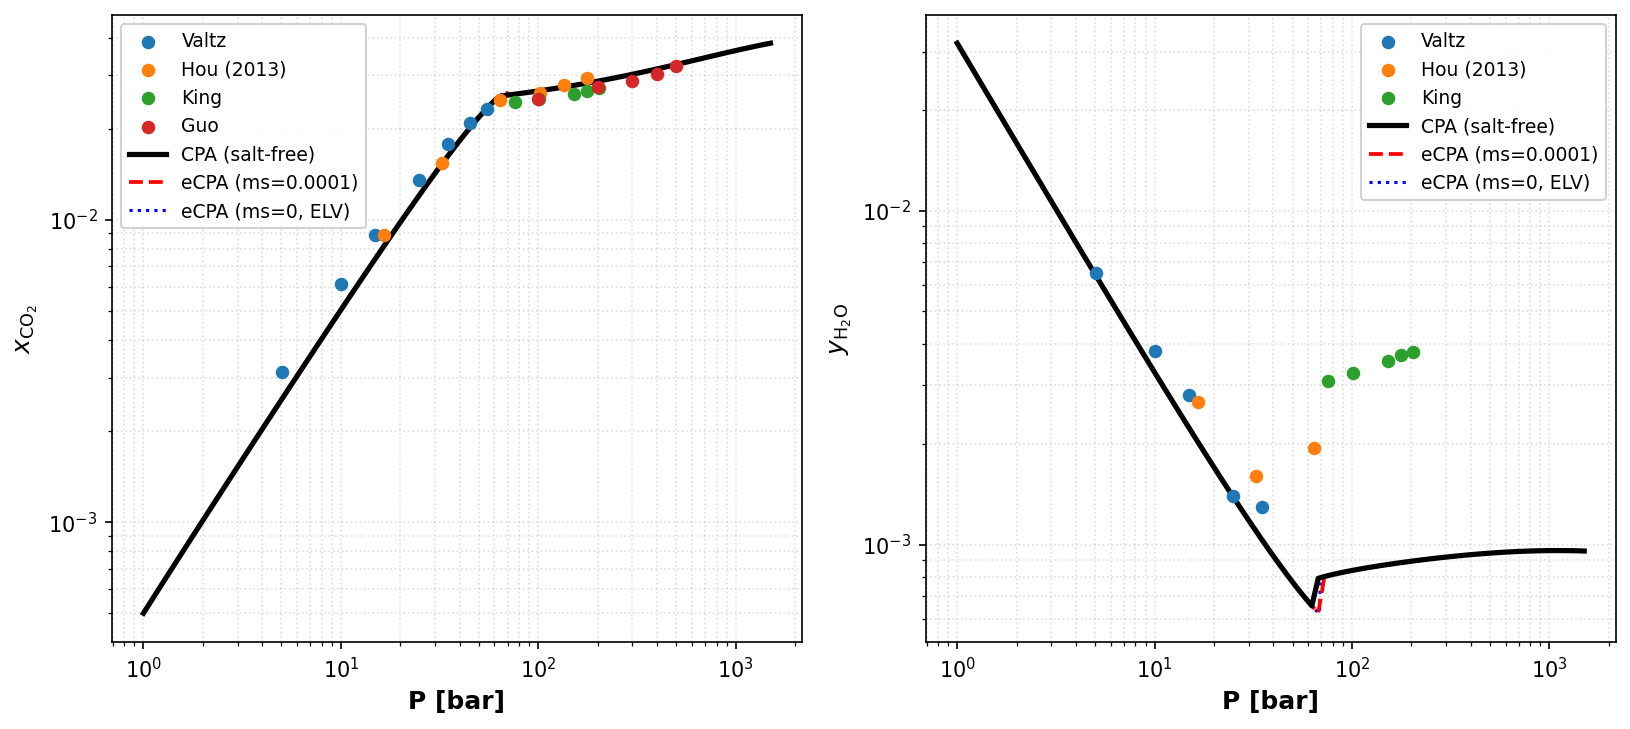

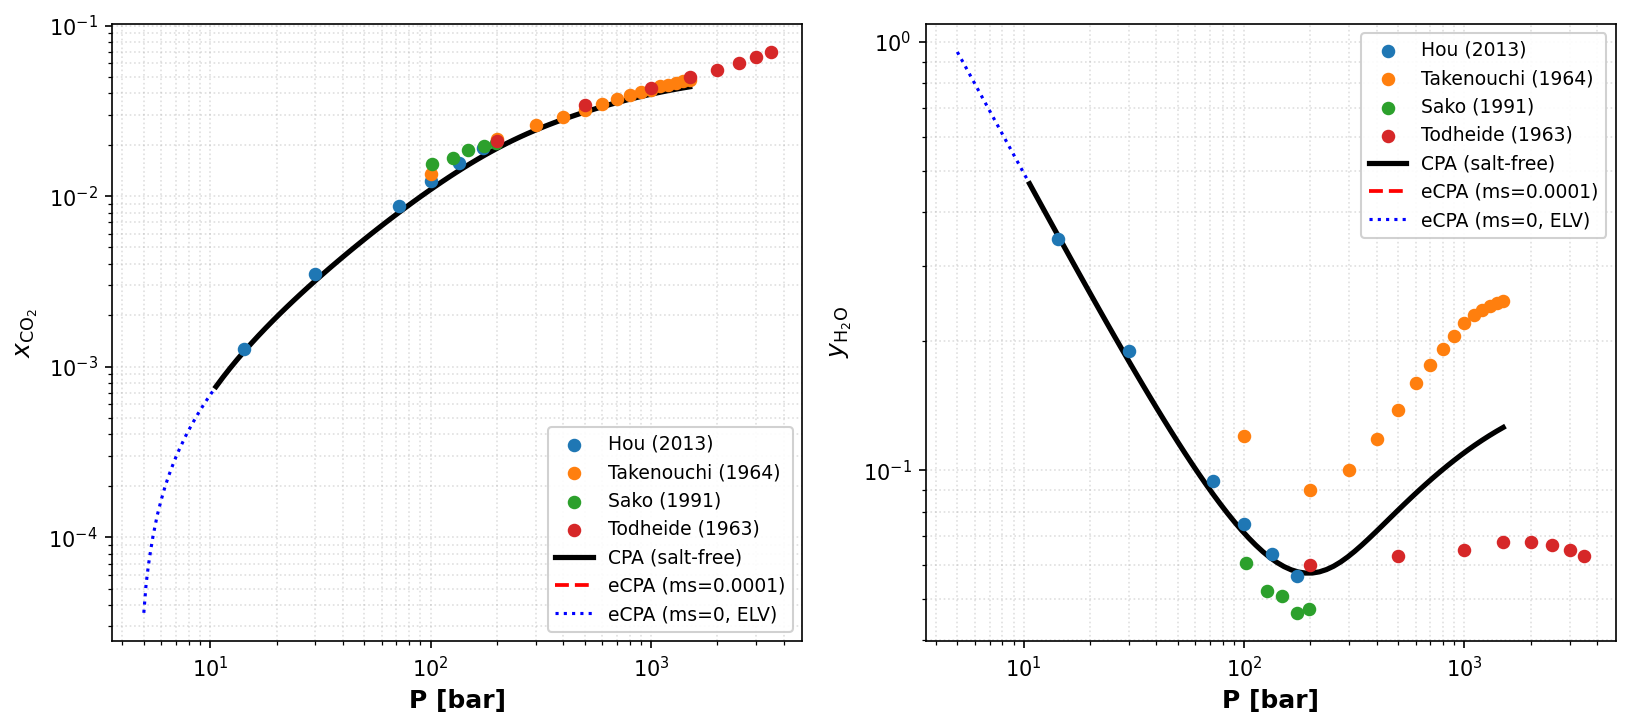

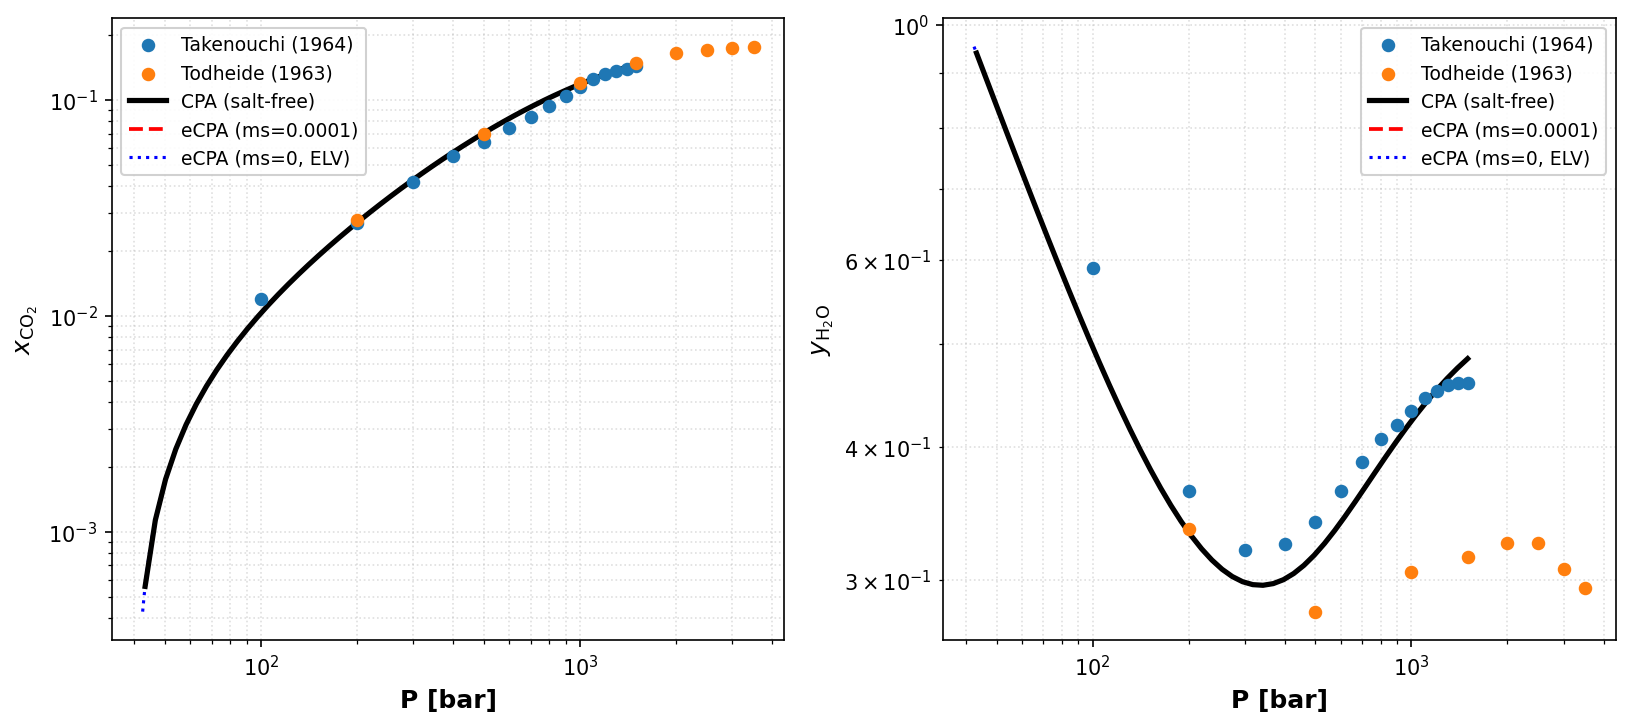

In [2]:
# ▶ Figure 1 — CO2+H2O phase equilibria at 25, 150, 250 °C (cached validation results shipped with the repo)
run_once('scripts/plot_co2h2o_figures.py')
show('figures/co2h2o/T298K.png', 'figures/co2h2o/T423K.png', 'figures/co2h2o/T523K.png')


*Figure 1: CO$_2$ + H$_2$O phase equilibria at three representative temperatures ($25$, $150$, and $250\,^\circ$C).
Each panel shows the CO$_2$ mole fraction in the aqueous phase ($x_{\text{CO}_2}$, left sub-panel)
and the H$_2$O mole fraction in the CO$_2$-rich phase ($y_{\text{H}_2\text{O}}$, right sub-panel)
vs. pressure. Open symbols: experimental data;<sup>[9](#references)</sup> black solid line: CPA (salt-free);
rainbow-colored filled bands: eCPA predictions spanning NaCl molalities
$m_s = 0$–$6$ mol kg$^{-1}$ (filled between consecutive molality contours;
violet $\approx 0$, red $= 6$ mol kg$^{-1}$), with discrete eCPA curves overlaid.
Results for the remaining 32 temperatures are shown in Figure S1.*

These model errors should be interpreted in the context of the experimental
uncertainty in the compiled dataset.
Two independent estimates of measurement scatter can be obtained directly from the data.
First, at the 76 ($T$, $P$) conditions where at least two independent references overlap
(matched within $\pm 2.5$ bar), the coefficient of variation between reported values
averages 4.0% for $x_{\text{CO}_2}$ and 11.1% for $y_{\text{H}_2\text{O}}$.
Second, the Gasser–Sroka–Jennen-Steinmetz (GSJS) difference-based variance
estimator,<sup>[29](#references)</sup> which estimates measurement noise from the
scatter of consecutive data points around a locally interpolated trend within each
isothermal series, yields a median relative noise of 2.4% for $x_{\text{CO}_2}$ and
4.7% for $y_{\text{H}_2\text{O}}$.
Taken together, these estimates suggest an intrinsic experimental uncertainty
of roughly 2–4% for $x_{\text{CO}_2}$ and 5–11% for $y_{\text{H}_2\text{O}}$,
so the model AARE of 6.5% (subsurface) to 9.6% (global) for $x_{\text{CO}_2}$
are close to the measurement noise.

Moreover, relative errors can be misleading when mole fractions span several orders of
magnitude: a 35% AARE for $y_{\text{H}_2\text{O}} < 0.005$ (101 points) corresponds to an
average absolute error (AAE) of only 0.1 mol% — negligible for reservoir
simulation. Across all data, the AAE is 0.53 mol% for $x_{\text{CO}_2}$ and
3.5 mol% for $y_{\text{H}_2\text{O}}$; under subsurface conditions these drop to
0.13 and 0.68 mol%, respectively.


<a id="sec18"></a>

### 4.2 CO$_2$ + NaCl brine

Figure 1 also illustrates the effect of brine salinity on the equilibrium compositions by including predictions for the full molality range considered in this work.
We further validate the eCPA ternary flash against all available experimental data from the
literature,<sup>[30](#references),[31](#references),[32](#references),[33](#references),[34](#references),[35](#references),[36](#references),[37](#references),[38](#references),[39](#references),[40](#references),[41](#references),[42](#references),[43](#references),[44](#references)</sup>
spanning $T = 5$–$450\,^\circ$C, $P = 1$–$1400$ bar, and
$m_s = 0.17$–$6.0$ mol kg$^{-1}$ NaCl (708 experimental data points in total).
Two types of measurements are compared: CO$_2$ solubility in the aqueous
phase and the CO$_2$ mole fraction in the CO$_2$-rich phase
($y_{\text{CO}_2}$).
Aqueous-phase solubility is reported differently by different sources:
as CO$_2$ molality ($m_{\text{CO}_2}$ [mol kg$^{-1}$]), or as the mole fraction
on a NaCl-free basis
($x_{\text{CO}_2}^{\text{sf}} = x_{\text{CO}_2}/(x_{\text{CO}_2}+x_{\text{H}_2\text{O}})$),
where NaCl is excluded from the denominator.
The latter is a reporting convention used by some authors and describes
the same physical quantity as $m_{\text{CO}_2}$; it is converted to molality via
$m_{\text{CO}_2} = x_{\text{CO}_2}^{\text{sf}}/[(1-x_{\text{CO}_2}^{\text{sf}})M_w]$
before comparison.

All experimental results and eCPA predictions are illustrated in Figure 2 and Figure 3 of the main text and Figures S2 and S3 of the Supporting Information.


Loaded 708 rows  (686 ok)
Loaded smooth_data for 9 ms values: [1e-05, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0]
Saved 21 per-T figures to figures/co2nacl_ws/
Saved 21 figures → figures/co2nacl_ws/
Saved 19 per-T figures to figures/co2nacl/
Saved 19 figures → figures/co2nacl/
Regenerating heatmap …
Saved figures/validation_heatmap_extended.png
Done.



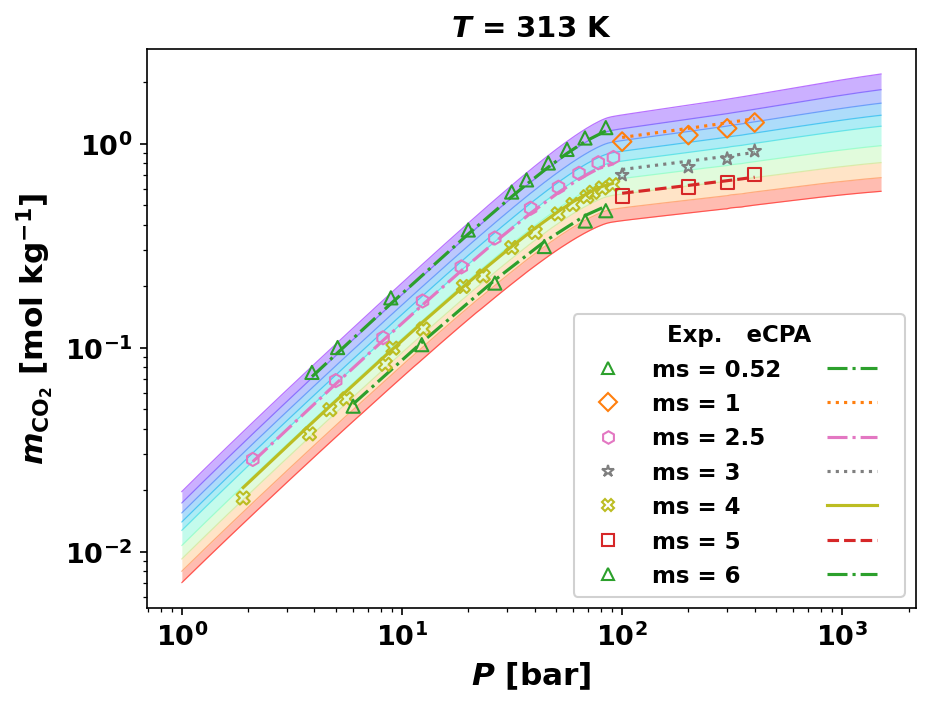

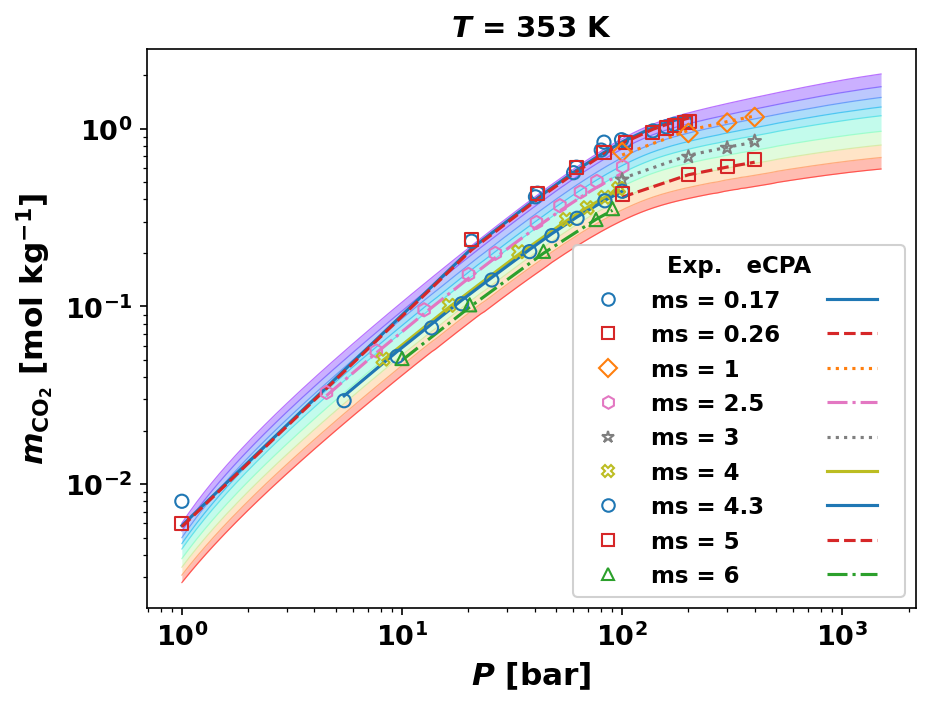

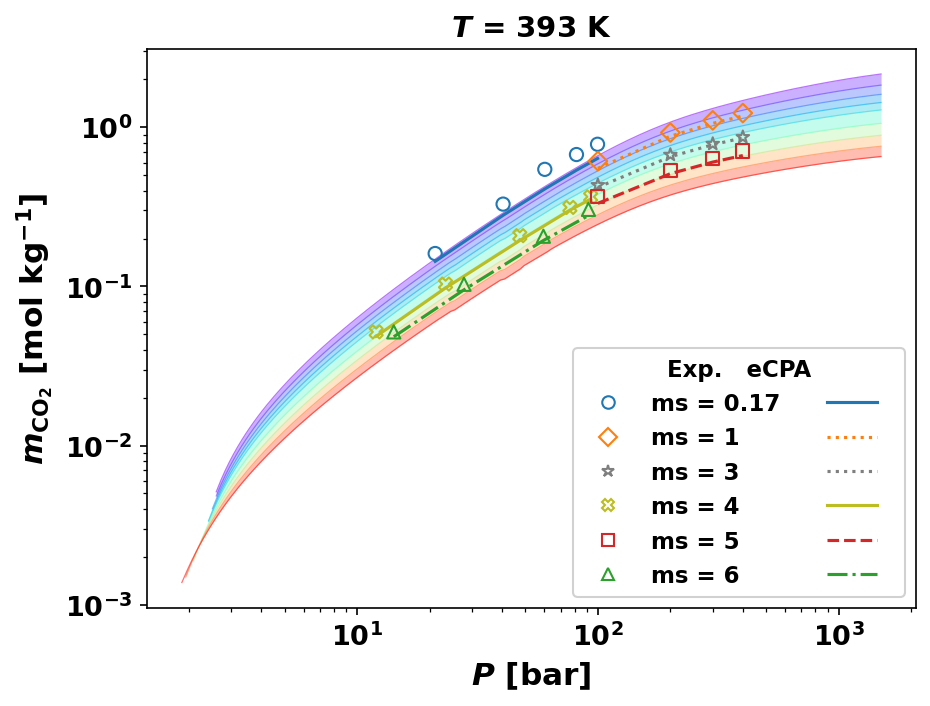

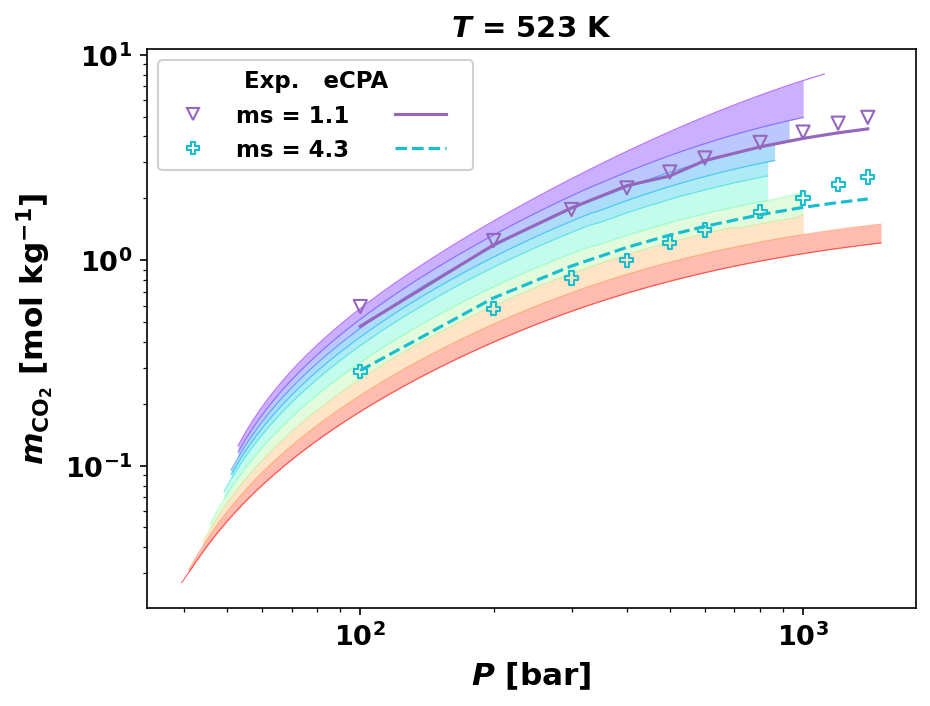

In [3]:
# ▶ Figure 2 — CO2 solubility in NaCl brine at 40, 80, 120, 250 °C
run_once('scripts/plot_co2nacl_figures.py')
show('figures/co2nacl/T313K.png', 'figures/co2nacl/T353K.png', 'figures/co2nacl/T393K.png', 'figures/co2nacl/T523K.png')


*Figure 2: CO$_2$ solubility in NaCl brine at four representative temperatures ($40$, $80$, $120$, and $250\,^\circ$C).
Each panel shows CO$_2$ molality $m_{\text{CO}_2}$ [mol kg$^{-1}$] vs. pressure (log–log).
Open symbols: experimental data;<sup>[30](#references),[31](#references),[33](#references),[41](#references),[40](#references),[42](#references),[34](#references)</sup> discrete lines
with markers: eCPA at the experimental NaCl molalities.
Rainbow-colored background bands: continuous eCPA predictions spanning
$m_s = 0$–$6$ mol kg$^{-1}$ (color scale as in Figure 1:
violet $\approx 0$, red $= 6$ mol kg$^{-1}$).
Temperatures with additional CO$_2$-rich phase data ($y_{\text{CO}_2}$) are shown separately
in Figure 3; all 18 temperatures in Figures S2 and S3.*

Table 2 shows the accuracy breakdown.
689 of 708 points converge to a two-phase solution using the K-value SSI warm-started
from the solution table; the model predicts single-phase behavior at 18 points
(particularly at $T \geq 350\,^\circ$C where CO$_2$ + H$_2$O approaches complete
miscibility in the model) and fails to converge at one extreme high-$P$, high-$m_s$
condition, giving an overall two-phase convergence rate of 97.3%.
The K-value SSI requires a median of 6 outer iterations per converged call.
Overall AARE across all converged points is 6.2%, with a slight underprediction bias
of $-1.5\%$.
The AARE for $m_{\text{CO}_2}$ across all $T$ and $m_s$ is 6.6%, in excellent agreement with the 6.9%
reported by Coelho et al.<sup>[9](#references)</sup> using the original eCPA parameterization.
The CO$_2$-rich phase composition $y_{\text{CO}_2}$ is reproduced to within 0.4% AARE, reflecting the
near-purity of the CO$_2$-rich phase and its weak dependence on salinity.


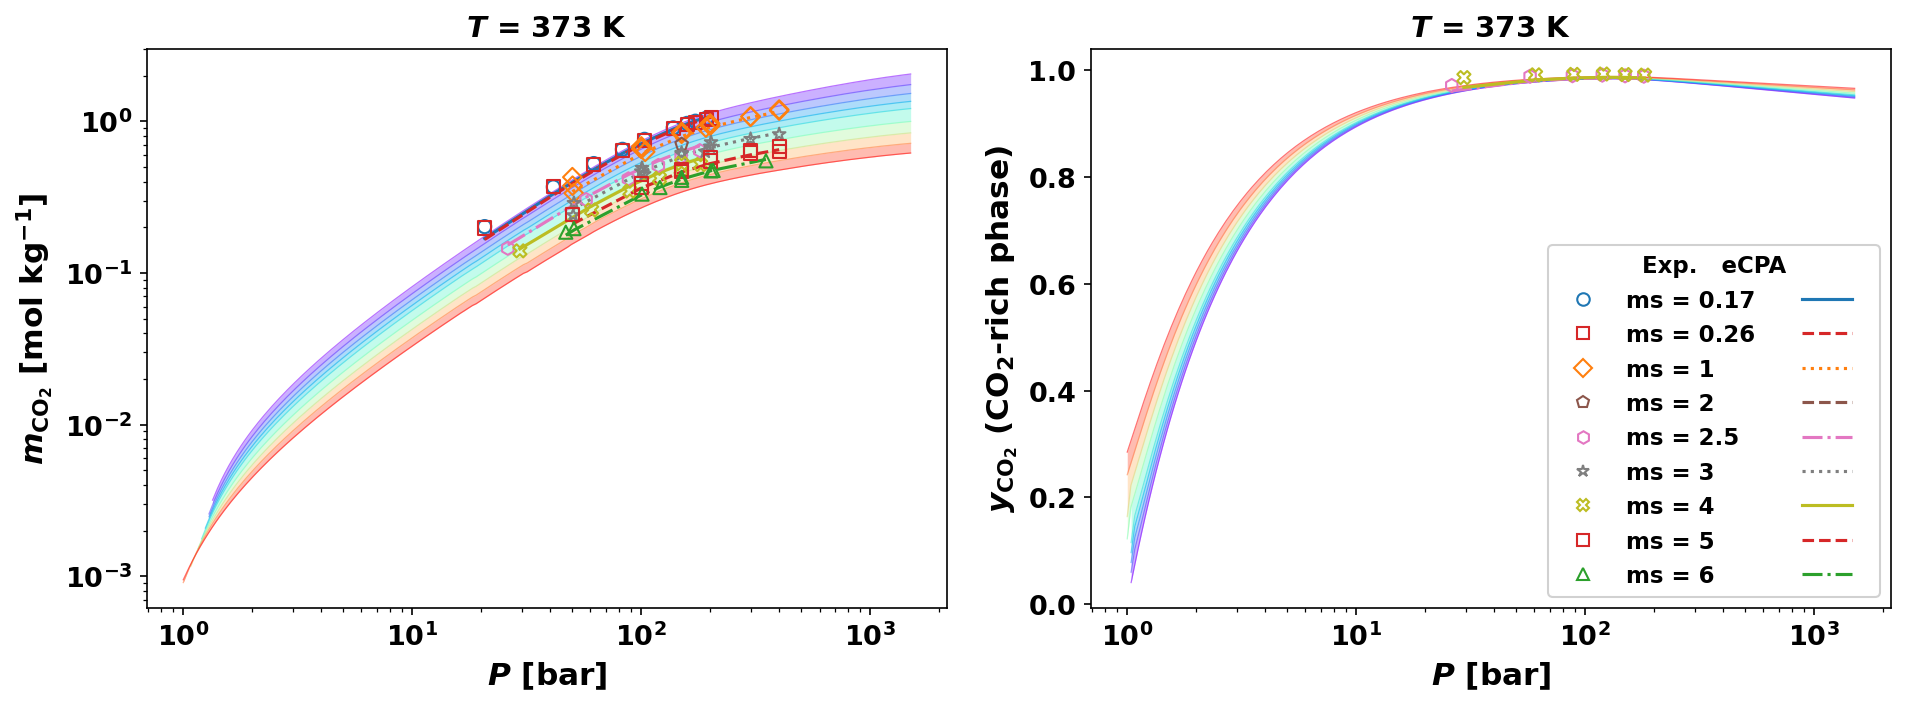

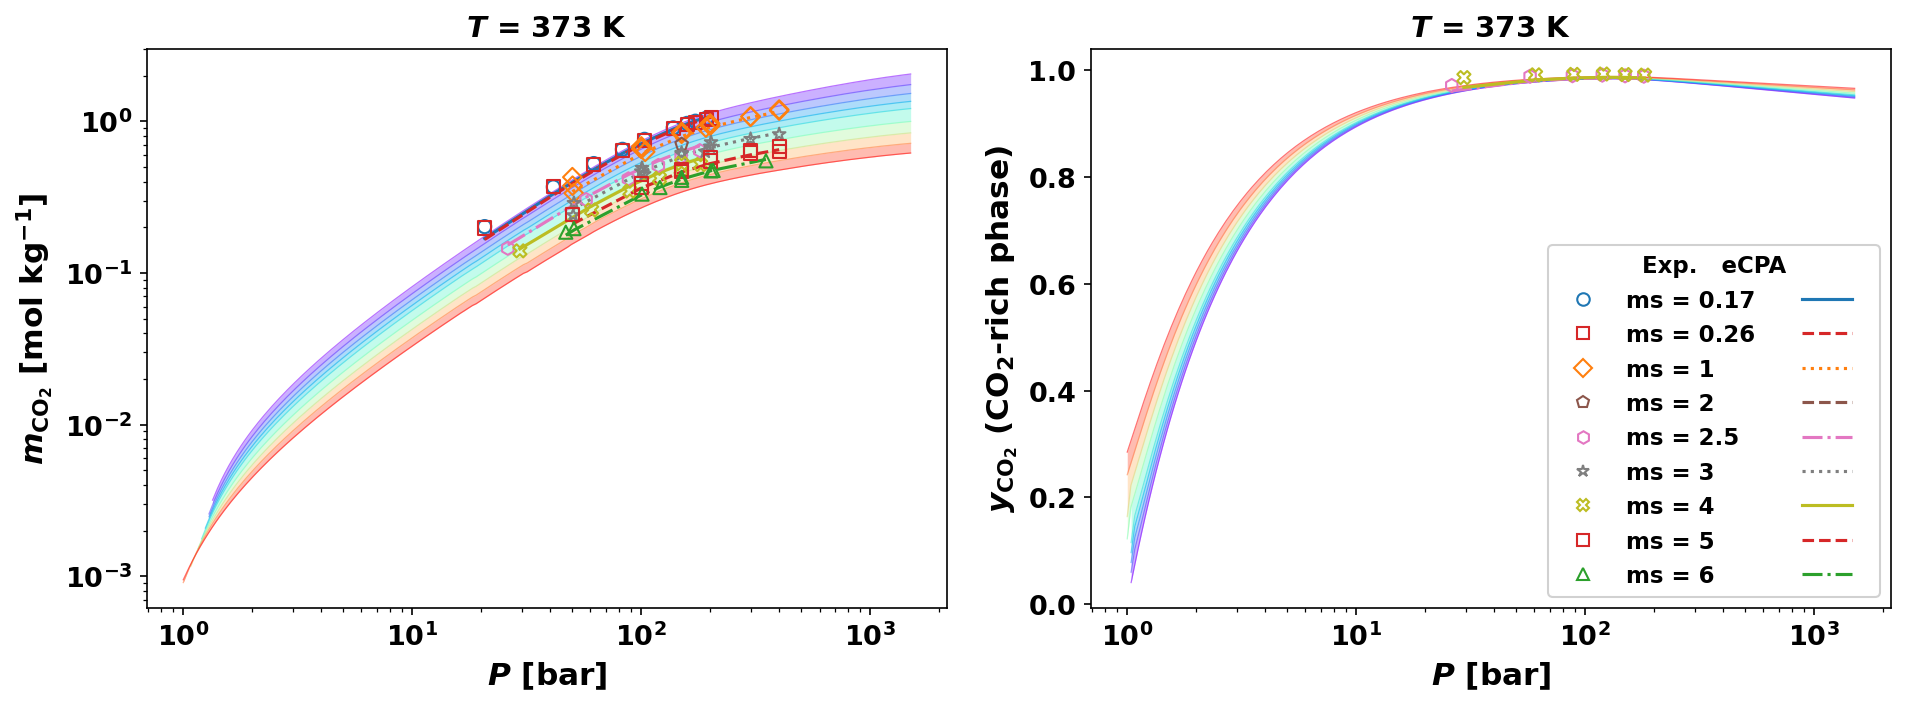

In [4]:
# ▶ Figure 3 — CO2+NaCl at 100 °C: aqueous and CO2-rich panels
run_once('scripts/plot_co2nacl_figures.py')
show('figures/co2nacl/T373K.png', 'figures/co2nacl_ws/T373K.png')


*Figure 3: CO$_2$ + NaCl brine phase equilibria at temperatures for which both CO$_2$ molality
($m_{\text{CO}_2}$, left panel) and CO$_2$ mole fraction in the CO$_2$-rich phase ($y_{\text{CO}_2}$, right panel)
data are available: (top) $50\,^\circ$C, (bottom) $150\,^\circ$C
(see also Figure S3 for $100\,^\circ$C).
Open symbols: experimental data;<sup>[40](#references),[35](#references),[30](#references),[37](#references),[32](#references),[42](#references),[36](#references),[44](#references),[34](#references),[38](#references),[39](#references)</sup> discrete lines with markers: eCPA at the
experimental NaCl molalities.
Rainbow-colored background bands: continuous eCPA predictions across
$m_s = 0$–$6$ mol kg$^{-1}$ (color scale as in Figure 1).*

At hydrothermal temperatures, AARE for $m_{\text{CO}_2}$ rises to 14.0% at $T = 300\,^\circ$C and
12.8% at $T = 350\,^\circ$C, reflecting reduced eCPA accuracy at conditions beyond the
conventional reservoir temperature range.
At $T \geq 400\,^\circ$C, the available experimental pressures (300–900 bar, all from
Takenouchi and Kennedy<sup>[34](#references)</sup>) fall in the region where eCPA predicts single-phase behavior,
suggesting that the CO$_2$ + H$_2$O miscibility gap closes at these extreme conditions
in the model.
Notably, accuracy at the lowest temperatures ($T = 5$–$10\,^\circ$C) is also reduced
(AARE 14–21%), reflecting the challenge of modeling CO$_2$ solubility very close to
the freezing point where eCPA is not specifically parameterized.
These conditions furthermore fall within the CO$_2$ hydrate stability zone, where solid
CO$_2$ clathrates can form; the eCPA EoS computes fluid-phase VLE only and does not
model hydrate formation explicitly.
Figure S4 provides a comprehensive view of the error distribution
across the full $(T, m_s)$ parameter space: accuracy is best at intermediate temperatures
($T = 27$–$227\,^\circ$C) and moderate salinities ($m_s \leq 3$ mol kg$^{-1}$), and degrades
systematically at the boundaries of the validated range.

**Table 2:** VLE accuracy metrics for CO$_2$ + NaCl brine ($T = 5$–$450\,^\circ$C,
$m_s = 0.17$–$6.0$ mol kg$^{-1}$, 708 data points total, 689 two-phase converged).
Bias $= \langle(\hat{y} - y)/y\rangle$.

| Quantity | $N$ | AARE (%) | Bias (%) |
|---|---:|---:|---:|
| $m_{\text{CO}_2}$ [mol kg$^{-1}$] | 501 | 6.6 | $-3.3$ |
| $x_{\text{CO}_2}^{\text{sf}}$ (NaCl-free basis, conv. to $m_{\text{CO}_2}$) | 116 | 5.5 | $+2.7$ |
| $x_{\text{CO}_2}$ [salt-incl.] | 36 | 8.6 | $+8.6$ |
| $y_{\text{CO}_2}$ | 36 | 0.5 | $-0.1$ |
| **All converged** | 689 | 6.2 | $-1.5$ |


#### 4.2.1 Comparison against other equations of state

It is instructive to place this accuracy against other established
CO$_2$-brine solubility models.
Duan and Sun<sup>[45](#references)</sup> report an accuracy of better than 7% AAD in
CO$_2$ solubility over $T = 273$–$533$ K, $P = 0$–$2000$ bar, and
$m_s = 0$–$4$ mol kg$^{-1}$ NaCl.
Chabab et al.<sup>[46](#references)</sup> evaluate four models — their own electrolyte
Peng-Robinson-CPA (e-PR-CPA), a re-optimized Søreide–Whitson model
(m-SW), a CHESS/HYTEC geochemical (SIT) model, and a re-implementation of
the Duan and Sun model — against a common literature
compilation of $>$1100 points; under their 'storage conditions' subset
($T = 297$–$433$ K, $P = 50$–$600$ bar, $m_s = 0$–$6$ mol kg$^{-1}$)
the four models achieve AAD of 6.6%, 7.5%, 7.6%, and 6.5%,
respectively (Table 7 of Chabab et al.<sup>[46](#references)</sup>).
Pabsch et al.<sup>[47](#references)</sup> report 7.73% AARD for CO$_2$
solubility in H$_2$O+NaCl with the electrolyte statistical-associating-fluid-theory
model ePC-SAFT ($T = 298$–$423$ K, $P = 1$–$400$ bar,
$m_s = 0$–$6$ mol kg$^{-1}$), and cross-validate against
Chabab et al.<sup>[46](#references)</sup> and an e-CPA study, finding all three broadly
consistent (6.6–7.7%).
A follow-up ePC-SAFT study<sup>[48](#references)</sup> removes the fitted
CO$_2$–ion interaction parameter entirely and still reports
${\sim}10\%$ AARD averaged over 14 salt systems, at the cost of no longer
being adjusted to the target property at all.
Carvalho et al.<sup>[49](#references)</sup> compare two further electrolyte equations of
state available in the commercial Multiflash package (CPA-Infochem and
RKSA-Infochem, extensively used by the oil and gas industry) against new CO$_2$+H$_2$O+NaCl data
($T = 293$–$353$ K, $P \approx 10$–$140$ bar,
$m_s = 0.25$–$2$ mol kg$^{-1}$), reporting 12% and 9.4% AAD,
respectively; note these are bubble-point *pressure* deviations
rather than solubility AARE, so are not directly numerically comparable
to the other entries in Table 3 but are included for context.
Table 3 summarizes these figures alongside the present work.
The eCPA framework used here achieves comparable or better accuracy
(6.6% AARE for $m_{\text{CO}_2}$) while validated over a substantially
wider envelope — up to $723$ K and the full $0$–$6$ mol kg$^{-1}$
salinity range, versus temperature ceilings of $400$–$533$ K and, for
most of the models above, a salinity range curtailed at or below
saturation for a narrower pressure window.


**Table 3:** Comparison of CO$_2$-brine solubility accuracy across
established models and this work.
AAD/AARE figures are as reported by the cited sources over
their own stated validity range; see text for the specific
literature compilation each was evaluated against.
$^a$Duan and Sun.<sup>[45](#references)</sup> $^b$Chabab et al.<sup>[46](#references)</sup> $^c$Pabsch et al.<sup>[47](#references)</sup>
$^d$Carvalho et al.<sup>[49](#references)</sup> $^\dagger$Bubble-point pressure AAD, not solubility AARE — see text.

| Model | $T$ range (K) | $P$ range (bar) | $m_s$ range (mol kg$^{-1}$) | AAD/AARE (%) |
|---|:---:|:---:|:---:|:---:|
| DUAN$^a$ | 273–533 | 0–2000 | 0–4 | $<7$ |
| m-Søreide–Whitson$^b$ | 297–433 | 50–600 | 0–6 | 7.5 |
| Geochemical (SIT)$^b$ | 297–433 | 50–600 | 0–6 | 7.6 |
| e-PR-CPA$^b$ | 297–433 | 50–600 | 0–6 | 6.6 |
| DUAN (re-implemented)$^b$ | 297–433 | 50–600 | 0–6 | 6.5 |
| ePC-SAFT$^c$ | 298–423 | 1–400 | 0–6 | 7.73 |
| CPA-Infochem$^{d\dagger}$ | 293–353 | 10–140 | 0.25–2 | 12$^\dagger$ |
| RKSA-Infochem$^{d\dagger}$ | 293–353 | 10–140 | 0.25–2 | 9.4$^\dagger$ |
| **This work (eCPA)** | **278–723** | **1–1400** | **0.17–6.0** | **6.6** |


The models compared above are not all structurally alike, and the
distinction matters for interpreting the numbers.
eCPA, the ePC-SAFT family,<sup>[47](#references),[48](#references)</sup>
and the vapor-phase treatment underlying the DUAN model<sup>[45](#references)</sup> decompose the residual Helmholtz energy into terms
with an explicit physical meaning — dispersion/repulsion, hydrogen-bond
association, and electrostatics (Debye–Hückel, MSA, or Born) — with
one parameter set applied self-consistently to both the aqueous and
non-aqueous phases.
The widely used Spycher and Pruess model<sup>[50](#references)</sup> — the
CO$_2$-brine engine inside the TOUGH2/ECO2N reservoir simulator —
illustrates the alternative: it pairs an equation of state for the vapor
phase with liquid-phase activity coefficients that are not derived from
the model's own theory but assembled from other authors' correlations,
and it is validated only over a comparatively narrow window
($T = 12$–$100\,^\circ$C, $P \leq 600$ bar) relative to the present
work.
The m-Søreide–Whitson model above illustrates the same issue from the
inside: it requires two different binary interaction parameters for the
same species pair, one for the aqueous phase and one for the non-aqueous
phase, which Chabab et al.<sup>[46](#references)</sup> explicitly note "makes the mixture
inconsistent (which makes it equivalent to a gamma-phi approach)."
Such per-phase-fitted closures, and purely empirical correlations more
generally, can achieve high accuracy within their fitted range by
construction — Pabsch et al.<sup>[47](#references)</sup> note that a
competing model achieving under 5% AAD does so with six fitted
interaction parameters against their own two, and recent machine-learning
surrogates trained directly on CO$_2$-brine solubility data routinely
report $R^2 > 0.99$ — but the fit does not thereby constrain the model
outside the conditions it was trained on, nor does it offer mechanistic
insight transferable to a new salt, gas species, or property.


<a id="sec19"></a>

### 4.3 Flash results as a function of feed composition

A central motivation for full stability+flash — rather than straightforward
VLE calculations at a fixed salinity — arises naturally in reservoir simulation.
When CO$_2$ is injected into a saline aquifer, the reservoir fluid at any given
grid cell can be represented as a mixture of brine (carrying NaCl at feed molality
$m_s$) and varying amounts of injected CO$_2$.
The overall CO$_2$ mole fraction $z_{\rm CO_2}$ in this mixture is the primary degree of freedom,
and stability+flash must be performed to determine the equilibrium state.

As shown in Section 1, in the ternary system the equilibrium molality
$m_s^\mathrm{aq}$ exceeds the feed value because NaCl is concentrated as H$_2$O
partitions into the CO$_2$-rich phase; quantitatively (from Eq. (22)):

$$
  m_s^\mathrm{aq}
    = m_s
      \,\frac{(1-\beta)\,x_{\mathrm{H_2O}}+\beta\,y_{\mathrm{H_2O}}}
             {(1-\beta)\,x_{\mathrm{H_2O}}}
    = m_s\!\left(1 + \frac{\beta\,y_{\mathrm{H_2O}}}{(1-\beta)\,x_{\mathrm{H_2O}}}\right),
$$

where $\beta$ is the CO$_2$-rich molar phase fraction.
Because $\beta\,y_{\mathrm{H_2O}} > 0$ in the two-phase region, $m_s^\mathrm{aq}$
*exceeds* $m_s$, and the excess grows with $z_{\rm CO_2}$ as $\beta$ increases.
This elevated salinity modifies the aqueous-phase fugacity coefficients and in
turn shifts the equilibrium phase compositions — an effect that cannot be
captured by a VLE table indexed on feed molality alone.


T=300K (27°C): 287 two-phase points
T=325K (52°C): 293 two-phase points
T=350K (77°C): 293 two-phase points
T=375K (102°C): 292 two-phase points
T=400K (127°C): 289 two-phase points
T=425K (152°C): 283 two-phase points
T=450K (177°C): 275 two-phase points
T=475K (202°C): 262 two-phase points
T=500K (227°C): 244 two-phase points
T=525K (252°C): 222 two-phase points
Saved figures/flash_vs_z.png



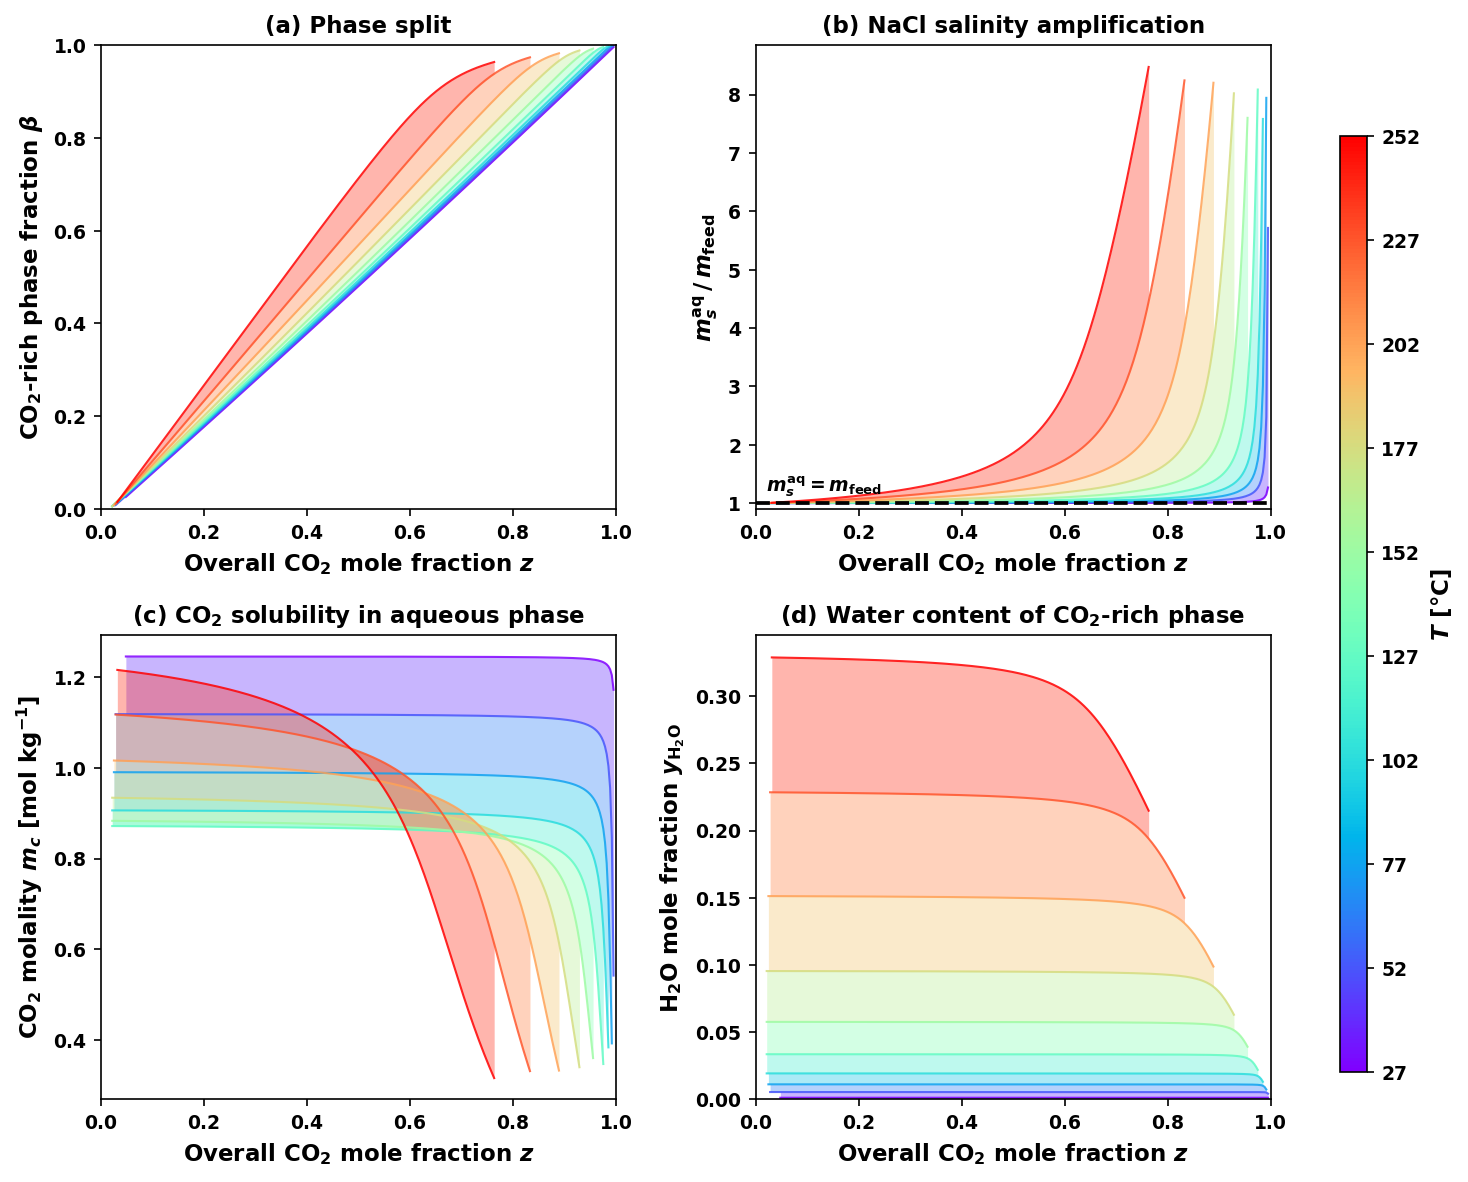

In [5]:
# ▶ Figure 4 — eCPA flash vs CO2 feed fraction z (cached scan table)
run_once('scripts/plot_flash_vs_z.py')
show('figures/flash_vs_z.png')


*Figure 4: eCPA flash results as a function of overall CO$_2$ feed mole fraction $z_{\rm CO_2}$
at $P = 200$ bar, feed molality $m_s = 1.0$ mol kg$^{-1}$
NaCl, and ten isotherms from $27$ to $252\,^\circ$C (violet to red).
(a) CO$_2$-rich phase fraction $\beta$; the two-phase window narrows
progressively at higher temperature.
(b) Ratio of equilibrium aqueous NaCl molality to feed molality,
$m_s^\mathrm{aq}/m_s$; NaCl concentrates in the aqueous phase
as H$_2$O partitions to the CO$_2$-rich phase, reaching a factor of ${\sim}8$
at $T = 252\,^\circ$C and $z_{\rm CO_2} \approx 0.98$.
(c) CO$_2$ molality $m_{\text{CO}_2}$ in the aqueous phase; the salting-out effect
driven by the elevated $m_s^\mathrm{aq}$ reduces CO$_2$ solubility
with increasing $z_{\rm CO_2}$.
(d) H$_2$O mole fraction $y_{\mathrm{H_2O}}$ in the CO$_2$-rich phase;
substantial water content at high temperatures (up to ${\sim}30$ mol%
at $252\,^\circ$C) and its strong variation with $z_{\rm CO_2}$ highlight the need
for full flash rather than a fixed-salinity VLE lookup.*

Figure 4 demonstrates these effects for $P = 200$ bar,
$m_s = 1.0$ mol kg$^{-1}$ NaCl, and ten isotherms from $27$ to
$252\,^\circ$C (in $25\,^\circ$C increments) over the two-phase feed range $z_{\rm CO_2} = 0.005$–$0.995$.
Panel (a) shows the CO$_2$-rich phase fraction $\beta$, which rises from 0 to 1
across the two-phase window.
Higher temperatures narrow the window because CO$_2$ is less soluble and
H$_2$O more volatile, both effects shrinking the range of $z_{\rm CO_2}$ that sustains
two-phase coexistence.

Panel (b) illustrates the salinity amplification: at the highest isotherm
($T = 252\,^\circ$C) the ratio $m_s^\mathrm{aq}/m_s$ reaches
$\approx 8$ at the high-$z_{\rm CO_2}$ end of the two-phase window, meaning the aqueous
NaCl concentration increases eightfold relative to the injected brine as H$_2$O
partitions into the growing CO$_2$-rich phase.
At lower temperatures the amplification is smaller because less H$_2$O leaves
the aqueous phase at the lower $\beta$ values attained.

Panel (c) shows the resulting CO$_2$ molality in the aqueous phase,
$m_{\text{CO}_2}$ [mol kg$^{-1}$].
Despite operating at fixed $(T, P)$, $m_{\text{CO}_2}$ decreases substantially with increasing
$z_{\rm CO_2}$: at $T = 227\,^\circ$C it falls from $\approx 1.1$ to $\approx 0.4$ mol kg$^{-1}$
across the two-phase window.
This is a direct consequence of the salting-out effect — the elevated
$m_s^\mathrm{aq}$ suppresses CO$_2$ solubility.
A simple VLE lookup at the feed molality $m_s$ would return the
wrong CO$_2$ solubility for all but the dilute-CO$_2$ end of the window.

Panel (d) shows the H$_2$O mole fraction in the CO$_2$-rich phase, $y_{\mathrm{H_2O}}$,
and reveals a second consequence of the salting-out chain.
As $z_{\rm CO_2}$ increases, $\beta$ increases and $m_s^\mathrm{aq}$ rises (panel b), which suppresses
CO$_2$ solubility in the aqueous phase (panel c): the aqueous phase can dissolve less CO$_2$,
so proportionally more CO$_2$ remains in the CO$_2$-rich phase and, by molar conservation,
$y_{\mathrm{H_2O}}$ is diluted downward.
At low temperatures this effect is invisible because the baseline water content of
the CO$_2$-rich phase is tiny; at high temperatures, where $y_{\mathrm{H_2O}}$ starts near
$\approx 35$ mol%, the same salting-out suppression translates into a large absolute drop
— falling to $\approx 22$ mol% by $z_{\rm CO_2} \approx 0.75$ at $T = 252\,^\circ$C.
This also underscores the importance of accurate modeling of the CO$_2$-rich phase
at elevated temperatures.

Taken together, these results demonstrate that the correct representation of
CO$_2$+brine phase behavior in reservoir models requires a full
stability+flash computation for each cell at each time step, with the
NaCl molality updated self-consistently from the aqueous-phase amount.


<a id="sec20"></a>

### 4.4 Aqueous-phase density

We validate pure-water density by comparing eCPA predictions (with the
temperature-dependent Péneloux shift described in Section 2.3)
against the IAPWS-95 international standard<sup>[51](#references)</sup> — fitted to a
comprehensive body of experimental measurements and valid to 1 000 MPa and
1 273 K, with a documented uncertainty in liquid-water density of $\pm 0.001$–$0.02\%$.
Over 475 liquid/compressed-water conditions spanning
$T = 0$–$350\,^\circ$C and $P = 1$–$2\,000$ bar, the AARE is **0.30%**,
with a maximum of 3% near 350 $^\circ$C (close to the critical point of water).
For typical subsurface CO$_2$ storage conditions ($T \leq 120\,^\circ$C,
$P = 75$–$600$ bar), the AARE is **0.12%**.
We note that IAPWS-95 is itself a 56-parameter empirical Helmholtz free energy fit
with no molecular basis, optimized specifically to reproduce water data.
Achieving 0.30% with a physics-based association EoS (CPA/eCPA) is therefore a strong result.
Full details, the parity plot, and the signed-error surface are provided in
Section S4.1 of the Supplemental Information.


<a id="sec21"></a>

## 5. Computational Performance

### 5.1 Flash convergence statistics

#### 5.1.1 Parameter-space scan for the salt-free CPA binary

To rigorously evaluate the robustness and efficiency of the accelerated SSI and
multi-guess stability test, we perform a comprehensive parameter-space scan over
$86 \times 18 \times 19 = 29{,}412$ conditions spanning
$T = 0$–$425\,^\circ$C, $P = 1$–$1500$ bar, and
$z_{\rm CO_2} = 0.001$–$0.999$ (Table 4).
At each $(T, P, z_{\rm CO_2})$ point, we run the stability test with all six initial guesses,
followed by four independent flash strategies:
standard SSI with Wilson K initialization ("Std+Wilson"),
accelerated SSI with Wilson K ("Acc+Wilson"),
accelerated SSI with K from the stability test ("Acc+StabK"),
and the full hierarchical robust algorithm ("Robust").

**Table 4:** Parameter-space scan grid for the salt-free CPA binary.

| Variable | Range | Points | Spacing |
|---|---:|---:|---:|
| $T$ ($^\circ$C) | 0–425 | 86 | $5\,^\circ$C |
| $P$ (bar) | 1–1500 | 18 | semi-log |
| $z_{\text{CO}_2}$ | 0.001–0.999 | 19 | variable |
| **Total** | | 29,412 | |


Of the 29,412 conditions, 19,586 (66.6%) are classified as single-phase by the
stability test and 9,825 (33.4%) as two-phase.
Table 5 compares six flash strategies on the two-phase subset.
The hierarchical robust algorithm achieves 100% convergence by combining the
stability-informed K-value initialization with Wilson-K fallback for the
0.3% of points where the stability K fails to converge.
Only a single point at the extreme corner of the domain ($T = 425\,^\circ$C,
$P = 1500$ bar, $z_{\text{CO}_2} = 0.995$) produces a spurious instability;
all neighbors are correctly identified as single-phase.

The accelerated SSI reduces the mean iteration count from 25.4 to 13.7
(a 46% reduction, or $1.9\times$ speedup) compared to standard SSI with the same
Wilson K initialization (Figures 6a and S11).
The speedup is most pronounced near the CO$_2$ critical point ($T \approx 31\,^\circ$C,
$P \approx 74$ bar) and at extreme compositions, where standard SSI requires many
iterations to converge (Figure 5).
Elevated iteration counts at the lowest temperatures in the scan ($T \lesssim 12\,^\circ$C)
are also noteworthy: these conditions fall within the CO$_2$ hydrate stability zone,
where eCPA — which computes fluid-phase VLE only — returns a metastable fluid equilibrium
that may be physically unrealizable.
The additional iterations in this regime likely reflect the difficulty of converging
a fluid-phase flash at conditions where the true equilibrium involves a solid hydrate phase.
Using K-values from the stability test as the flash initial guess provides a further
8% reduction in iterations (13.7 to 12.6) on average.

**Table 5:** Comparison of six flash strategies across 9,825 two-phase conditions
from the parameter-space scan ($T = 0$–$425\,^\circ$C, $P = 1$–$1500$ bar,
$z_{\rm CO_2} = 0.001$–$0.999$).
The first four rows use cold-start initialization;
the fifth and sixth use K-values interpolated from a pre-computed solution table
extended to $T = 0$–$400\,^\circ$C (99.9% of two-phase points).
The sixth row additionally applies Newton polish once $\|\mathbf{g}\| < 10^{-4}$,
with mean 4.8 SSI and 2.1 Newton iterations per converged call.

| Strategy | Converged | Conv. rate | Mean iters | Median iters |
|---|---:|---:|---:|---:|
| Std SSI + Wilson K | 9,756 | 99.3% | 25.4 | 17 |
| Acc SSI + Wilson K | 9,775 | 99.5% | 13.7 | 9 |
| Acc SSI + Stability K | 9,793 | 99.7% | 12.6 | 9 |
| Acc SSI + Stability K + Wilson K fall-back | 9,825 | **100%** | 13.0 | 9 |
| Acc SSI + Table K | 9,818 | 99.9% | 9.8 | 6 |
| Acc SSI + Table K + Newton | 9,808 | 99.8% | **6.9** | 5 |


In [6]:
# ▶ Figure 5 — mean SSI iteration count (CPA parameter-space scan)
# NOTE: full recompute — set RUN_LONG = True in the setup cell to enable (~30 min on a laptop).
if RUN_LONG:
    run_once('scripts/run_parameter_scan.py')
    run_once('scripts/run_newton_scan.py')
    run_once('scripts/plot_newton_figures.py')
show('figures/scan/newton_heatmap.png')


not found (needs RUN_LONG or a prior cell): figures/scan/newton_heatmap.png


*Figure 5: Mean SSI iteration count for the salt-free CPA flash, averaged over all
$z_{\text{CO}_2}$ values (two-phase points only), as a function of $T$ and $P$.
Left: standard SSI with Wilson K initialization.
Center: accelerated SSI with Wilson K.
Right: accelerated SSI with stability-test K.
The accelerated SSI substantially reduces iteration counts across the
entire parameter space, with the largest improvements near the CO$_2$
critical point ($T \approx 31\,^\circ$C, $P \approx 74$ bar).
Elevated counts at the lowest temperatures ($T \lesssim 12\,^\circ$C) also
reflect conditions within the CO$_2$ hydrate stability zone, where eCPA
computes a metastable fluid-phase equilibrium.*

When a pre-computed solution table is available — as in sequential simulation
where flash solutions from the previous time step or neighboring grid cells
serve as initial guesses — the iteration count drops further to a mean of 9.8
(median 6), a 25% improvement over the best cold-start strategy.
The table covers $T = 0$–$360\,^\circ$C with $1\,^\circ$C resolution and all practically
relevant pressures ($P = 1$–$2000$ bar); it captures 99.9% of the two-phase
scan points, eliminating the Wilson-K fallback for virtually all conditions.
Because the table also pre-classifies each cell as single- or two-phase, the
Michelsen stability test (six guesses, $\approx 10$ ms per guess) can be skipped
for all cells confidently inside the two-phase window, so the dominant cost of a
cold-start stability+flash call ($\approx 30\times$ higher wall time) is avoided
in the warm-start regime.
Phase compositions obtained from the two approaches agree to within 1.1% AARE
for $x_{\text{CO}_2}$ and 3.9% for $y_{\text{H}_2\text{O}}$, with residual
discrepancies concentrated near the two-phase boundary where both methods are
most sensitive to initial guesses.

Adding Newton polish (Table 5, bottom row) reduces the
mean count further to 6.9 (4.8 SSI + 2.1 Newton), a 29% improvement over
table-warm-started SSI alone and a 73% reduction from the standard cold-start.
Newton polish is triggered at 85.6% of points; the remaining 14.4% converge
in fewer than $\tau_{\text{switch}} = 10^{-4}$ SSI steps and need no Newton
correction.
In the near-CO$_2$-critical region ($T \approx 7$–$57\,^\circ$C) the Newton step
can temporarily diverge; the solver then reverts to the pre-Newton SSI state
and continues, so no convergence is lost in that region.
The iteration breakdown and wall-time ratio across the full $(T, P)$ parameter
space are shown in Figure S10.


In [7]:
# ▶ Figure 6 — SSI speedup ratio and best stability initial guess
# NOTE: full recompute — set RUN_LONG = True in the setup cell to enable (~30 min on a laptop).
if RUN_LONG:
    run_once('scripts/run_parameter_scan.py')
    run_once('scripts/run_newton_scan.py')
    run_once('scripts/plot_newton_figures.py')
show('figures/scan/strategy_comparison_bar.png')


not found (needs RUN_LONG or a prior cell): figures/scan/strategy_comparison_bar.png


*Figure 6: (a) Iteration speedup from accelerated SSI, averaged over $z_{\rm CO_2}$ (two-phase only).
The speedup exceeds 2$\times$ across most of the parameter space and reaches
3–4$\times$ near the critical region.
(b) Distribution of the initial guess that found the lowest TPD across all
9,825 unstable points. No single guess dominates: each of the six trials
is the best for 9–25% of conditions, demonstrating the importance of multiple
initial guesses for robust stability testing.*

Figure 6b shows that all six stability initial guesses
contribute materially: Wilson is best for 17.2% of unstable points, inverse Wilson for
25.0%, H$_2$O-rich for 20.3%, CO$_2$-rich for 14.5%, inverse cube-root for 14.1%, and
cube-root Wilson for 8.9%.
While the first two guesses (Wilson and inverse Wilson) can detect instability (TPD $< 0$)
for 99.8% of conditions, they locate the *most negative* TPD — and thus the best
K-value initialization for the subsequent flash — for only 42.2%.
All six guesses are required to ensure the optimal K-value initialization across the
full parameter space.


#### 5.1.2 Convergence statistics for the eCPA ternary flash

To characterize eCPA flash performance over the full thermodynamic parameter space
relevant to geological CO$_2$ storage and geothermal energy production, we compute the three-dimensional solution table
described in Section 3.6.1, covering the grid summarized in Table 6.

Each grid point is evaluated with the full hierarchical stability+flash algorithm: the Michelsen
stability test (six trial compositions) is performed first; only genuinely unstable
conditions proceed to the K-value SSI flash.
The CO$_2$ feed fraction $z_{\rm CO_2}$ is not a table dimension; a representative value
$z_{\rm CO_2} = 0.5$ is used for the stability call (K-values and tie-line endpoints are
only weakly $z_{\rm CO_2}$-dependent, as discussed in Section 3.6.1).
Of the 505,400 grid points, 36,100 use the CPA sub-model ($m_s = 0$, no
electrostatic terms); the eCPA model covers the remaining 469,300 points.

**Table 6:** Parameter grid for the eCPA ternary solution table
(CO$_2$+H$_2$O+NaCl, $361\times100\times14 = 505{,}400$ points).

| Dimension | Range | Points |
|---|---|---|
| Temperature $T$ | $0$–$360\,^\circ$C | 361 ($1\,^\circ$C steps) |
| Pressure $P$ | 1–2000 bar | 100 (log-spaced) |
| NaCl feed molality $m_s$ | 0–6 mol kg$^{-1}$ | 14 |

Table 7 reports the outcome of all evaluations.
Every grid point is classified — 100% convergence is achieved over the
complete three-dimensional domain.

**Table 7:** Classification of eCPA flash outcomes over the full 3D solution table
(505,400 total points; 469,300 eCPA, 36,100 CPA).

| Classification | Count | Description |
|---|---:|---|
| Two-phase, converged | 289,065 | Valid two-phase split; SSI converged |
| Single-phase (stable) | 216,335 | Michelsen stability test: no phase split |
| **Total classified** | 505,400 | 100% |


ms=0 phase-swap fix: corrected 12855 cells (63.5% of two-phase)
Generating phase map...
  → ecpa_phase_map.pdf
Generating aq composition grid...
  → ecpa_composition_aq_grid.pdf
Generating CO2-rich composition grid...
  → ecpa_composition_c_grid.pdf
Generating timing heatmap...
  → ecpa_timing_heatmap.pdf
All scan_v4 figures done.



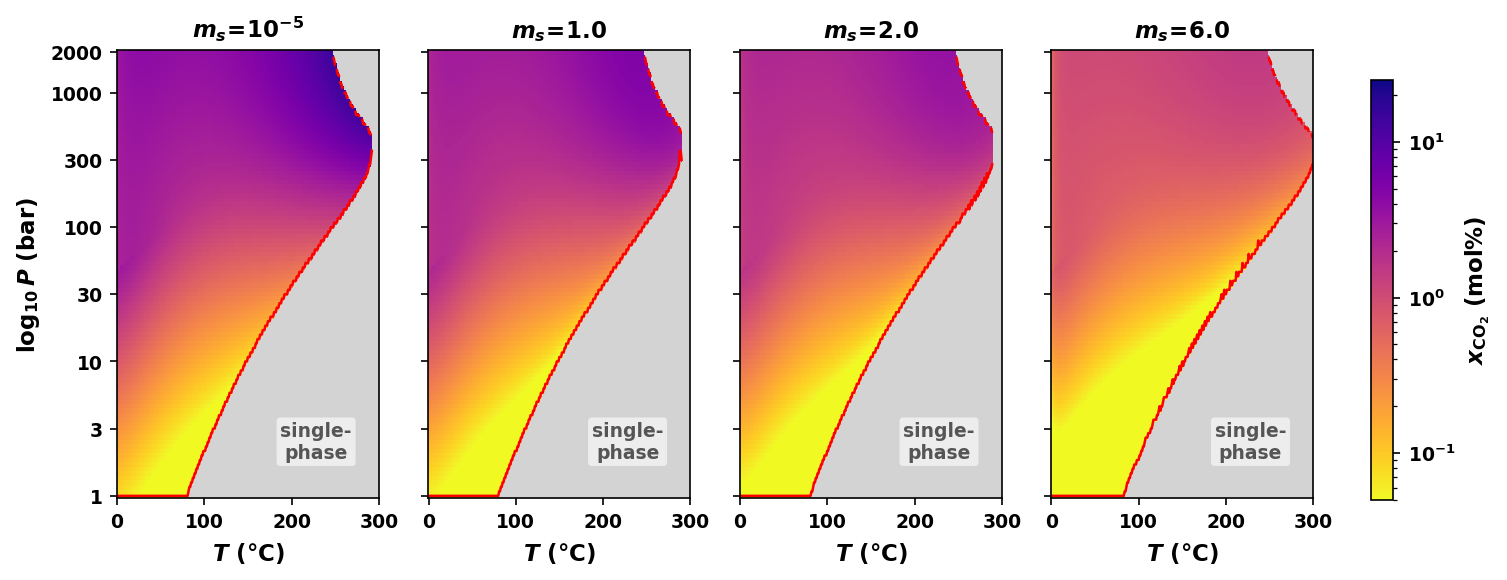

In [8]:
# ▶ Figure 7 — CO2 mol% in the aqueous phase (eCPA scan grid, cached)
run_once('scripts/plot_scan_figures.py')
show('figures/scan_v4/ecpa_composition_aq_grid.png')


*Figure 7: Equilibrium CO$_2$ mol% in the aqueous phase ($x_{\text{CO}_2}$)
over the $T$–$P$ plane at representative feed $z_{\rm CO_2} = 0.5$,
for six NaCl molalities (columns, $m_s = 0$–$6$ mol kg$^{-1}$).
The logarithmic color scale spans three orders of magnitude to resolve
both the dilute near-bubble-point regime and the high-solubility
hydrothermal limit.
Grey regions are thermodynamically single-phase at those conditions.
Red curves mark the phase envelope: the solid line is the dew-point
boundary (lower pressure limit of the two-phase window) and the dashed
line is the bubble-point boundary (upper pressure limit).
The phase boundaries are nearly independent of $m_s$; the salting-out
effect manifests as a reduction in $x_{\text{CO}_2}$ within the window,
not as a shift of its extent.*

**CO$_2$ solubility in the aqueous phase.**
Figures 7 and 8 map $x_{\text{CO}_2}$ and
$y_{\text{H}_2\text{O}}$, respectively, across the full $(T, P)$ domain for six NaCl molalities (and a pure salt-free condition with CPA)
at a representative feed $z_{\rm CO_2} = 0.5$; red curves trace the dew- (solid) and bubble-point (dashed) boundaries,
with the gray region indicating single-phase conditions.
Figure 9 maps mean flash wall time per call
across the $T$–$P$ plane for all six NaCl molalities, serving as a proxy for
solver effort.
Figure 7 shows $x_{\text{CO}_2}$ (aqueous phase) over a
logarithmic color scale spanning 0.05–25 mol%.
The two-phase window is broad, spanning the full pressure range from 1 to
2000 bar at most temperatures below $\sim$250 $^\circ$C, and closes at the highest
temperatures as CO$_2$ and water approach complete miscibility.
Three physically distinct solubility regimes are apparent.
At low temperatures ($T \lesssim 50\,^\circ$C), the CO$_2$-rich phase is a dense
supercritical or liquid-like fluid; solubility is moderate and increases with pressure.
At intermediate temperatures (50–200 $^\circ$C), solubility passes through a minimum
as the competing effects of pressure and thermal expansion partially cancel.
At high temperatures ($T \gtrsim 250\,^\circ$C), solubility rises sharply because the
aqueous phase increasingly resembles steam; values reach 20–25 mol% at the highest
pressures, well into a regime relevant to hydrothermal and geothermal CO$_2$ storage.
Increasing NaCl molality (left to right) reduces CO$_2$ solubility within the
two-phase window — the classical salting-out effect.
The phase boundaries (red curves) are nearly independent of $m_s$: the dew-point
shifts by less than 15% across the full salinity range,
and the bubble-point (visible only near $T \approx 250\,^\circ$C where it falls below
the 2000 bar grid ceiling) likewise shows negligible salinity dependence.
The dominant effect of NaCl is therefore a reduction in $x_{\text{CO}_2}$ within the
two-phase window rather than a change in the window's extent.


**H$_2$O content of the CO$_2$-rich phase.**
Figure 8 shows $y_{\text{H}_2\text{O}}$ (CO$_2$-rich phase) on the same
grid layout.
In sharp contrast to CO$_2$ solubility, the water content of the CO$_2$-rich phase is
controlled almost entirely by temperature: the color field in each panel varies
primarily along the horizontal axis, with near-vertical isopleths.
This reflects the dominant role of the water saturation pressure, which rises steeply
with temperature and sets the water activity in the CO$_2$-rich phase regardless of
pressure or salinity.
At $T = 50\,^\circ$C, $y_{\text{H}_2\text{O}}$ is below 1 mol% across
essentially all pressures; by $T = 300\,^\circ$C it reaches 50–70 mol%, meaning the
nominal CO$_2$-rich phase is in fact predominantly water vapour.
The effect of NaCl (columns) on $y_{\text{H}_2\text{O}}$ is weak:
the isopleths and the phase envelope (red curves) are essentially unchanged across all
salinity columns, confirming that water content in the CO$_2$-rich phase is set by
temperature alone and is insensitive to brine salinity.


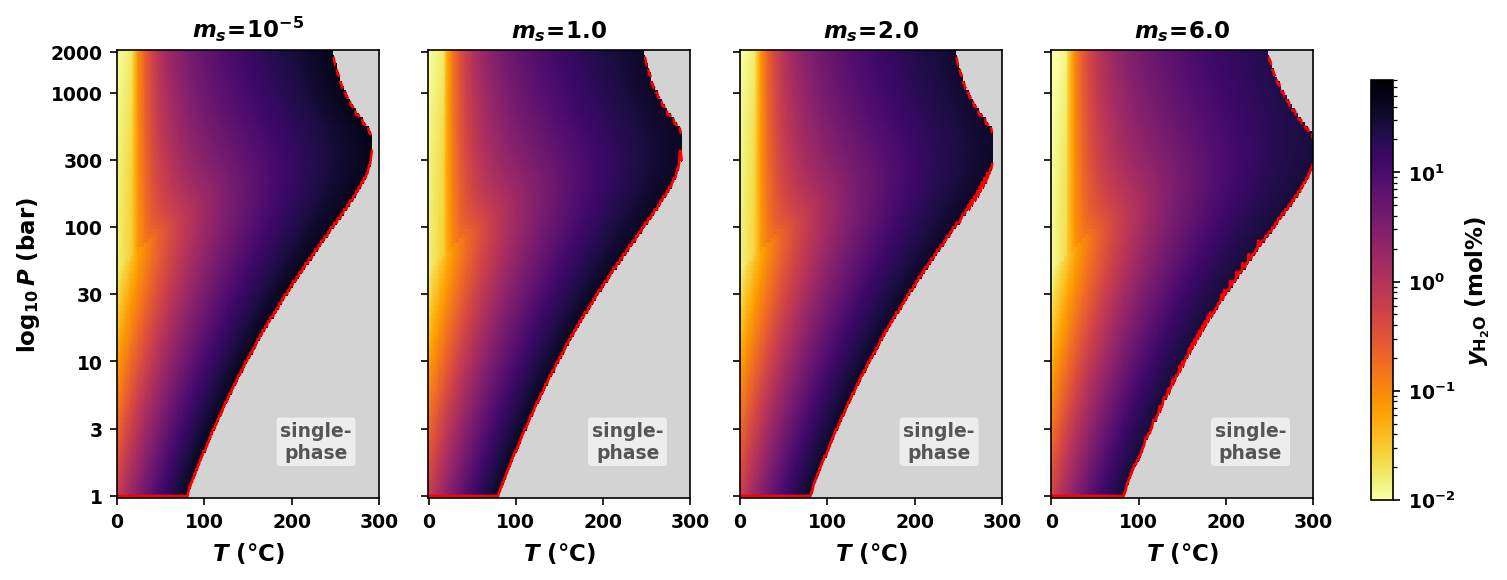

In [9]:
# ▶ Figure 8 — H2O mol% in the CO2-rich phase (eCPA scan grid, cached)
run_once('scripts/plot_scan_figures.py')
show('figures/scan_v4/ecpa_composition_c_grid.png')


*Figure 8: Equilibrium H$_2$O mol% in the CO$_2$-rich phase ($y_{\text{H}_2\text{O}}$)
over the $T$–$P$ plane at representative feed $z_{\rm CO_2} = 0.5$,
on the same grid as Figure 7.
Unlike $x_{\text{CO}_2}$, water content in the CO$_2$-rich phase
is governed almost entirely by temperature (water vapour pressure),
producing near-vertical isopleths that are nearly independent of
pressure and NaCl molality.
Red curves show the phase envelope (solid: dew point; dashed: bubble
point); their near-identical positions across columns confirm that
NaCl has negligible influence on the phase boundaries.
At temperatures above $250\,^\circ$C the CO$_2$-rich phase contains
more than 25 mol% H$_2$O, approaching 70 mol% at the highest
temperatures — a regime relevant to geothermal CO$_2$ storage.*

**Flash wall time.**
Figure 9 maps the mean wall time per eCPA flash call
(table-warm-started K-value SSI) across the $T$–$P$ plane for six NaCl molalities;
gray regions are single-phase.
The $m_s\!=\!0$ (CPA) column is excluded: its cold-start six-trial robust solver
runs at a median of $\sim$215 ms per call (reported in Table 8),
which would render uniformly at the colorbar ceiling; the warm-start table applies
equally to CPA.
Wall time serves as a proxy for solver effort.
Times are lowest ($\lesssim 5$ ms) in the interior of the two-phase region,
where the warm-started SSI converges in 2–3 steps.
Times rise near the phase boundaries — particularly near the bubble point and the
CO$_2$ critical temperature — where K-values approach unity and more iterations
are required.
The pattern is qualitatively similar across all NaCl molalities.


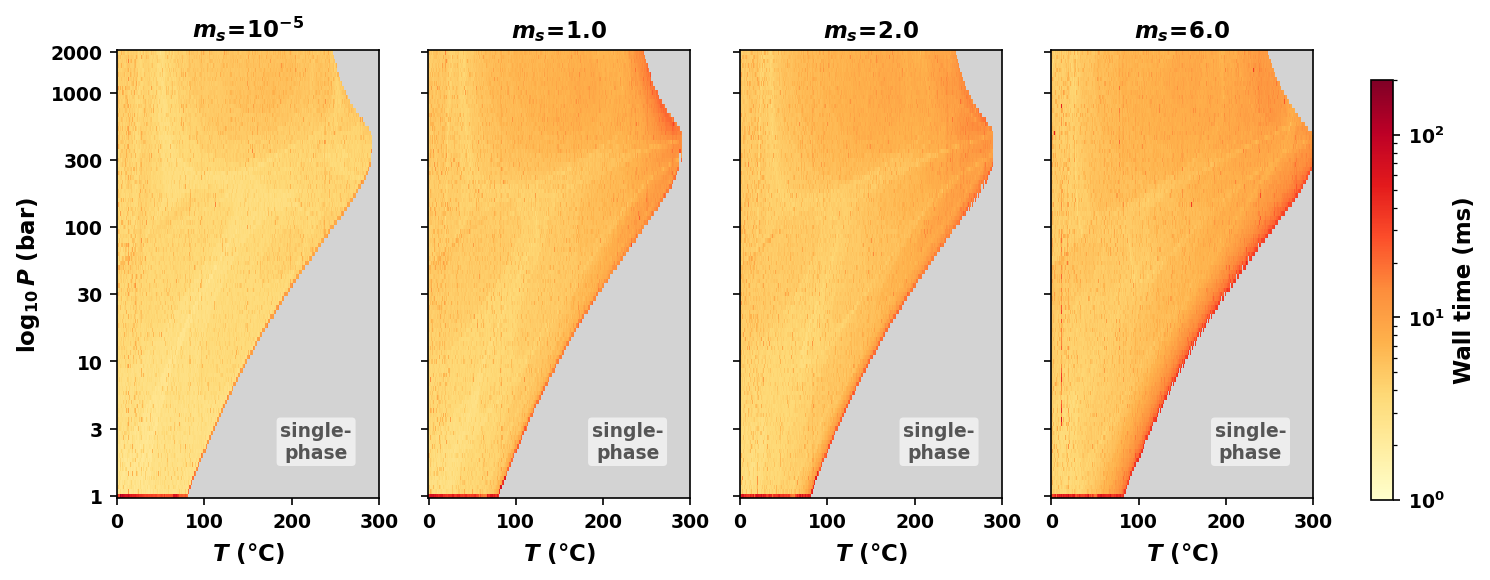

In [10]:
# ▶ Figure 9 — mean wall time per flash call (eCPA scan grid, cached)
run_once('scripts/plot_scan_figures.py')
show('figures/scan_v4/ecpa_timing_heatmap.png')


*Figure 9: Mean wall time per flash call (ms) for the eCPA warm-started
K-value SSI over the $T$–$P$ plane for six NaCl molalities (columns),
from the 3D scan.
Gray regions are thermodynamically single-phase.
The colormap is log-scaled (1–200 ms).
Times are lowest in the interior of the two-phase window and highest
near the phase boundaries where K-values approach unity and more
SSI iterations are required.
The $m_s\!=\!0$ (CPA) column is excluded; its cold-start robust solver
runs at a median of $\sim$215 ms per call and is reported separately
in Table 8.*

Table 8 summarizes SSI iteration counts and wall times across the
experimental validation datasets used in Sections 4.1–4.2.

**Table 8:** Flash convergence statistics across the experimental validation datasets.

| Method | $N$ calls | Mean iter | Median | Max | Median time/call |
|---|---:|---:|---:|---:|---:|
| CPA (cold, accel.) | 29,412 | 6.3 | 6 | 272 | $\sim$215 ms |
| CPA (warm SSI) | 626 | 6.2 | 6 | 40 | $\sim$2 ms |
| eCPA (warm SSI, $m_s\!\approx\!0$) | 631 | 5.9 | 6 | 10 | $\sim$2 ms |
| eCPA (warm SSI) | 686 | 5.8 | 6 | 16 | $\sim$2 ms |

All three warm-start rows use the same solution table and achieve a median of
6 SSI iterations and $\lesssim$2 ms per call.
The warm-started CPA row directly demonstrates that the $\sim$100$\times$ speedup
over cold-start CPA (row 1) is attributable entirely to the warm-start strategy:
the eCPA model adds electrostatic terms not present in CPA, yet both achieve
comparable wall times when started from a good initial guess.
Among the eCPA rows, the additional salt does not materially increase cost.
Each warm-started SSI step costs only $\sim$0.2 ms; the solution-table lookup
itself takes $\lesssim$0.05 ms and contributes negligible overhead.
Convergence is robust across the full validation range.


<a id="sec22"></a>

### 5.2 Inner EoS solve efficiency: Newton–Raphson versus cold-start alternatives

Each outer SSI iteration requires solving the inner per-phase EoS system.
The two systems — CPA's $(Z, \chi_{\rm H_2O}, \chi_{\rm CO_2})$ and eCPA's $(Z^{\rm aq}, \varepsilon_r, \chi_{\rm H_2O})$
— differ in structure but share the same warm-started Newton–Raphson strategy
described in Sections 3.3 and 3.4;
the analytical Jacobians are derived in Sections S3.1 and S3.2 of the Supplemental Information.
The benchmarks below quantify the advantage of the warm-started Newton solve
over the respective cold-start alternatives, and are distinct from the outer
SSI$+$Newton-polish acceleration discussed in Section 5.1 and Figure S10.

**CPA: $(Z, \chi_{\rm H_2O}, \chi_{\rm CO_2})$ system.**
Starting from the previous SSI iterate (typically within 0.5% of the converged
value), the warm-started Newton solve converges in **3–4 iterations**
(median 3, maximum 4 across 9,825 two-phase conditions).
The cold-start fallback — a 12-point log-spaced scan to bracket the root of $F_1$,
followed by Brent refinement — requires on average 23 residual evaluations
(median 21) per call, equivalent to $\approx$0.38 ms.
The warm-start Newton solve costs $\approx$0.03 ms across 128 two-phase conditions
spanning $T = 27$–$227\,^\circ$C and $P = 50$–$800$ bar:
a **13$\times$** reduction in inner-solve cost per SSI step.

**eCPA: $(Z^{\rm aq}, \varepsilon_r, \chi_{\rm H_2O})$ system.**
For the aqueous $3\times 3$ system, a 0.5–1% warm-start perturbation yields
convergence in **4–6 iterations** (median 5 at 1%), with a wall time of
$\approx$0.25 ms per call.
The cold-start alternative — solving from a heuristic initial guess via a
general-purpose modified-Powell root-finder — requires on average 47 residual
evaluations and costs $\approx$1.5 ms per call: a **6$\times$** overhead.

**Computational cost of CPA and eCPA versus a cubic EOS.**
To quantify the per-iteration overhead of the association terms relative to a plain
cubic EoS, we time each component of a single SSI iteration across 871 two-phase
$(T, P)$ conditions sampled from the CO$_2$–H$_2$O parameter space.
CPA (with the Newton $Z$/$\chi$ solve) is compared against a notional SRK reference
(same EoS parameter computation and fugacity evaluation, but $Z$ found by direct
solution of the cubic and $\chi \equiv 1$).
The per-iteration median wall times were 98 μs (CPA) versus 32 μs
(SRK), a ratio of **3.1$\times$**.
The EoS-parameter and fugacity-evaluation steps are identical between the two models;
the entire overhead arises in the $Z$/$\chi$ solve, which costs 75 μs
(CPA Newton, two phases) versus 9 μs (SRK direct cubic, two phases).
This factor-of-3 per-iteration cost must be weighed against the additional physics
captured by CPA: accurate partitioning of a self- and cross-associating system over
a wide temperature and pressure range, and (in the full eCPA model) correct salt
activity without empirical brine corrections.


<a id="sec23"></a>

### 5.3 Simplified versus full flash: accuracy and efficiency

Over 3,285 two-phase conditions spanning $T = 10$–$250\,^\circ$C,
$P = 25$–$800$ bar, and $m_s = 1$–$6$ mol kg$^{-1}$, the simplified flash
reproduces the full K-value SSI result with AARE $< 2\%$ in dissolved CO$_2$ molality
for $T \leq 80\,^\circ$C, rising to 3.2% at 100 $^\circ$C and exceeding 5% above
120 $^\circ$C as the $y_{\text{H}_2\text{O}} = 0$ assumption deteriorates.
Phase identification agrees with the full flash in 99.7% of cases.
The accuracy is insensitive to brine salinity: the error is controlled entirely by
temperature.
Contrary to expectation, the mean wall time is essentially identical to the full flash
($0.8\times$ speedup), because Brent root-finding on the 1D fugacity residual requires
$\sim$11 inner Newton evaluations while SSI needs only $\sim$6 outer iterations with at
most two inner solves each.
Full per-temperature statistics, diagnostic figures, and a salinity breakdown are
provided in Section S4.2 of the Supplemental Information.


<a id="sec24"></a>

## 6. Reservoir Simulation Demonstration

To confirm that the flash algorithms developed in this work perform reliably under
realistic conditions, we implement them within an isothermal IMPEC compositional
simulator for CO$_2$ injection into a saline aquifer.
Two 5-year simulations are run on identical $100\times100$ m$^2$, $50\times50$-cell
grids (homogeneous 100 mD permeability, $\phi = 0.20$, Corey relative permeabilities)
with a five-spot well pattern — a central CO$_2$ injector and four BHP-controlled
corner producers ($P_{\rm BHP} = 150$ bar) — injecting at 20% of pore volume per
year at $T = 77\,^\circ$C, differing only in brine salinity: salt-free (CPA,
$m_s = 0$) versus saline (eCPA, $m_s = 4$ mol kg$^{-1}$ NaCl).

Figure 10 shows the final-state ($t = 5$ yr) CO$_2$-rich
phase saturation, dissolved-CO$_2$ molality, and pressure fields for both cases.
The displacement fronts are nearly identical, reflecting advection-dominated flow at
this injection rate, but the equilibrium aqueous-phase CO$_2$ molality inside the
plume is roughly a factor of two lower in the saline case
(${\approx}0.63$ vs. ${\approx}1.25$ mol kg$^{-1}$), directly reflecting the
salting-out reduction in CO$_2$ solubility.
This translates into a proportionally lower solubility-trapped CO$_2$ fraction for
the saline case throughout the simulation (Figure S13), showing that brine salinity
has a quantitatively significant impact on long-term storage permanence even when
short-term displacement dynamics appear unaffected.


In [11]:
# ▶ Figure 10 — reservoir simulator: final spatial fields (CPA vs eCPA)
# NOTE: full recompute — set RUN_LONG = True in the setup cell to enable (~10 min on a laptop).
if RUN_LONG:
    run_once('scripts/run_simulator_paper.py')
show('figures/simulator/fig_compositions.png')


not found (needs RUN_LONG or a prior cell): figures/simulator/fig_compositions.png


*Figure 10: Final-state ($t = 5$ yr) spatial fields for the salt-free CPA case
($m_s = 0$, left column) and the saline eCPA case
($m_s = 4$ mol kg$^{-1}$ NaCl, right column).
Top row: CO$_2$-rich phase saturation $S_g$.
Middle row: dissolved CO$_2$ molality $m_{\text{CO}_2}$ in the
aqueous phase; the white region near the central injector (white star)
marks cells where brine has been completely expelled into the
CO$_2$-rich phase (drying-out).
Bottom row: pressure field.
Black triangles: producers.*

Across 300 time steps and all 2500 grid cells in both cases, no flash
failures are recorded, confirming 100% convergence of the
hierarchical stability and flash approach.
The warm-started eCPA flash achieves a throughput of 14,270 calls s$^{-1}$ and
the CPA flash 8,840 calls s$^{-1}$, with the flash accounting for 80–87% of
total step cost.
Full simulation parameters, the solubility/structural-trapping time series, and
detailed flash-performance statistics are provided in Section S6 of the
Supplemental Information.


<a id="sec25"></a>

## 7. Conclusions

This work presents the first complete phase stability and flash framework built on the
eCPA equation of state of Coelho et al.,<sup>[9](#references)</sup> extending it from single-phase property
evaluation to fully converged, production-ready VLE calculations for CO$_2$ + H$_2$O +
NaCl mixtures across reservoir to hydrothermal conditions.

The central algorithmic contribution is the tight integration of four independently
novel elements:

- Fast inner Newton–Raphson solvers for the CPA and eCPA root-finding problems,
  based on analytical Jacobians derived in closed form, which reduce the
  per-evaluation overhead to only $\sim$3$\times$ that of a simple cubic EoS.
- A hierarchical outer flash algorithm combining Michelsen stability testing with
  six initial guesses, accelerated SSI, and optional Newton polish — achieving
  100% convergence over a comprehensive parameter-space scan.
- A precomputed three-dimensional $(T, P, m_s)$ solution table that provides warm
  starts reducing flash iterations by a factor of three relative to cold-start SSI.
- A simplified flash that exploits the $y_{\text{H}_2\text{O}} \approx 0$
  approximation to reduce the equilibrium problem to a single scalar equation,
  yielding errors below 2% in dissolved CO$_2$ for $T \leq 80\,^\circ$C at
  essentially the same computational cost.

Together, these enable warm-started eCPA flash at throughputs competitive with
conventional cubic-EoS implementations, as demonstrated in a prototype IMPEC reservoir
simulator.

Validation against $>$1100 experimental data points shows AARE of 6.5% for CO$_2$
solubility under subsurface conditions and 6.6% for CO$_2$ molality in NaCl brine.
Comparison against the IAPWS-95 international standard over 475 liquid conditions
($T = 0$–$350\,^\circ$C, $P = 1$–$2000$ bar) with a temperature-dependent Péneloux
volume shift for H$_2$O gives a density AARE of 0.30% overall and 0.12% for
subsurface storage conditions.


<a id="sec26"></a>

## Future Work

A fundamental extension is the generalization to brines containing
multiple salts (e.g. NaCl + CaCl$_2$ + MgCl$_2$ + KCl + Na$_2$SO$_4$, as encountered in
deep formation waters and CO$_2$-storage target aquifers).
In the single-salt eCPA framework the NaCl molality provides a single scalar
coupling between phase amounts and phase compositions.
For multi-salt brines the ionic interactions become more complex, and it is
necessary to shift from a molecular-species basis to an ionic basis, treating each
cation and anion (Na$^+$, Cl$^-$, K$^+$, Ca$^{2+}$, Mg$^{2+}$, SO$_4^{2-}$) as an
independent component with its own association and electrostatic
parameters.
Several electrolyte equation-of-state frameworks already address mixed-salt
systems along these lines, including ePC-SAFT-based models<sup>[52](#references),[53](#references)</sup> and
ion-specific extensions of eCPA itself;<sup>[54](#references)</sup> see Kontogeorgis et al.<sup>[8](#references)</sup> for a comprehensive
review of the electrolyte-EoS landscape.
We are actively extending the present flash and stability framework in this
direction, adding CO$_2$ and CH$_4$ solubility across the full six-ion
system, in a companion paper currently in preparation.
We do not fold this extension into the present work: the additional ionic
degrees of freedom, association-parameter fitting, and validation against a
distinct experimental database spanning multiple salts and a second volatile
species roughly double the scope of the paper, while the single-salt
CO$_2$+H$_2$O+NaCl system already provides the cleanest testbed for the
flash and stability algorithms that are this paper's central contribution.
Extending the eCPA framework to multiple salts and gases in this direction
represents a significant but tractable next step toward a truly general
thermodynamic engine for saline CO$_2$ storage.


A related limitation is that the present flash and stability framework is
two-phase throughout.
For the CO$_2$+H$_2$O binary (and, essentially unchanged, the
CO$_2$+H$_2$O+NaCl ternary), a genuine three-phase vapor–liquid–liquid
equilibrium — a CO$_2$-rich vapor and a CO$_2$-rich liquid coexisting with
the aqueous phase — is not a broad region but a narrow, univariant curve in
$(T,P)$: by the Gibbs phase rule, fixing the temperature of a two-component,
three-phase system also fixes the pressure, so this three-phase locus closely
tracks the pure-CO$_2$ saturation curve between the CO$_2$–H$_2$O
hydrate quadruple point ($T \approx 10\,^\circ$C) and the CO$_2$ critical
point ($T_{c,{\rm CO_2}} = 31.3\,^\circ$C).
Away from this curve, the two-phase treatment used throughout this work is
exact, including at the validation conditions reported in
Section 4 (e.g. the $25\,^\circ$C panel of
Figure 1, which lies at pressures off the three-phase
curve at that temperature).
On or very close to the curve itself, the present stability test returns the
single thermodynamically stable non-aqueous root (whichever of the
CO$_2$-rich liquid or vapor has the lower Gibbs energy) rather than
resolving a genuine three-phase split, and the flash as implemented does not
detect or handle this case.

We have previously developed three-phase compositional stability and flash
algorithms with CPA-family equations of state for closely related systems,
including CO$_2$–water–oil systems,<sup>[20](#references),[55](#references)</sup>
three-phase flow in fractured porous media,<sup>[56](#references)</sup> and
asphaltene-precipitation vapor–liquid–liquid equilibria;<sup>[57](#references)</sup>
Jex et al.<sup>[11](#references)</sup> provide a hierarchical multiphase
stability and flash algorithm directly applicable to this extension.
Admitting a third phase is not simply an additional root-solve: every
condition must be tested for three-phase stability (effectively two two-phase
stability tests instead of one), and, based on our prior experience with
three-phase systems, reliably converging to the thermodynamically correct
phase state near three-phase boundaries typically requires substantially more
initial guesses than the two-phase problem, increasing the computational cost
of the flash algorithms that are this paper's central contribution.
For the single-salt, single-gas system studied here, this added complexity
would buy accuracy only in the narrow $(T,P)$ sliver described above.
The three-phase region becomes more consequential once multiple volatile
species are present simultaneously — the true multi-component gas mixtures
targeted by the multi-salt, multi-gas extension discussed above — where
three-phase behavior can occupy a larger and more practically relevant part
of the operating envelope.
We therefore defer a three-phase extension to that future work, where the
computational cost is better justified by the physics.

The algorithms and validation presented here are implemented entirely in Python.
While this facilitates rapid prototyping and transparent benchmarking, it means that
the absolute throughput numbers reported are conservative relative to what a compiled
implementation would achieve.
A natural next step is to integrate the CPA and eCPA flash routines into a
production-level compiled simulator that fully accounts for gravity-driven and
density-driven flow, Fickian diffusion, capillarity, and explicitly resolved discrete
fractures in three-dimensional unstructured grids (e.g. refs.<sup>[3](#references),[17](#references),[20](#references),[56](#references),[58](#references),[59](#references),[60](#references)</sup>).
Such an integration will enable high-fidelity simulation of CO$_2$ sequestration
in saline aquifers at reservoir scale.


<a id="sec27"></a>

## Supporting Information

The Supporting Information is available free of charge.
It comprises the nomenclature; EoS parameters and binary interaction coefficients
(Tables S1–S4); analytical Jacobian matrices for the CPA and eCPA inner Newton
solvers (Eqs. S2–S29); additional CO$_2$+H$_2$O and CO$_2$+NaCl validation figures
at all temperatures (Figures S1–S7); the simplified flash accuracy assessment
(Table S5; Figures S8–S9); the SSI+Newton iteration breakdown and flash strategy
comparison (Figures S10–S11); and the reservoir simulation setup, results, and
performance analysis (Tables S6–S7; Figures S12–S13). The SI content follows
later in this notebook.


<a id="sec28"></a>

## Author Contributions

**Joachim Moortgat:** Conceptualization, Data curation, Formal analysis,
Investigation, Methodology, Project administration, Resources, Software,
Validation, Visualization, Writing – original draft.
**Felipe Mourão Coelho:** Data curation, Writing – original draft.
**Abbas Firoozabadi:** Conceptualization, Funding acquisition, Writing – original draft.


<a id="sec29"></a>

## Data and Code Availability

All source code implementing the CPA and eCPA equations of state,
the phase stability and flash algorithms, the solution table construction,
and the reservoir simulator described in this work is freely available at
[https://github.com/jmoortgat/CPA_and_eCPA_flash](https://github.com/jmoortgat/CPA_and_eCPA_flash).
The repository includes the precomputed three-dimensional solution table,
all experimental VLE data used for validation, and scripts to reproduce
every figure and table in this paper.


<a id="sec30"></a>

## Acknowledgments

Abbas Firoozabadi was supported by the member companies of the Reservoir Engineering Research Institute.
J. Moortgat did not receive any specific grant from funding agencies in the public, commercial, or not-for-profit sectors.


<a id="references"></a>

## References

1. Metz, B.; Davidson, O.; de Coninck, H. C.; Loos, M.; Meyer, L. A., Eds. *IPCC Special Report on Carbon Dioxide Capture and Storage*; Cambridge University Press: Cambridge, UK, **2005**.
2. Orr, F. M. Storage of Carbon Dioxide in Geologic Formations. *J. Pet. Technol.* **2004**, 56, 90–97.
3. Solovský, J.; Firoozabadi, A. Efficient numerical simulation of heat extraction from fractured media in enhanced geothermal systems (EGS) by water and CO$_2$. *Int. J. Heat Mass Transfer* **2026**, 256, 128065.
4. Kontogeorgis, G. M.; Voutsas, E. C.; Yakoumis, I. V.; Tassios, D. P. An Equation of State for Associating Fluids. *Ind. Eng. Chem. Res.* **1996**, 35, 4310–4318.
5. Wertheim, M. S. Fluids with Highly Directional Attractive Forces. I. Statistical Thermodynamics. *J. Stat. Phys.* **1984**, 35, 19–34.
6. Li, Z.; Firoozabadi, A. Cubic-Plus-Association Equation of State for Water-Containing Mixtures: Is “Cross Association” Necessary? *AIChE J.* **2009**, 55, 1803–1813.
7. Maribo-Mogensen, B.; Thomsen, K.; Kontogeorgis, G. M. An Electrolyte CPA Equation of State for Mixed Solvent Electrolytes. *AIChE J.* **2015**, 61, 2933–2950.
8. Kontogeorgis, G. M.; Schlaikjer, A.; Olsen, M. D.; Maribo-Mogensen, B.; Thomsen, K.; von Solms, N.; Liang, X. A review of electrolyte equations of state with emphasis on those based on cubic and cubic-plus-association (CPA) models. *Int. J. Thermophys.* **2022**, 43, 54.
9. Coelho, F. M.; Franco, L. F. M.; Firoozabadi, A. Phase Equilibria of CO$_2$–Water and CO$_2$–Brine at High Temperatures: From Monte Carlo Simulations to the Equation of State. *Ind. Eng. Chem. Res.* **2025**, 64, 8492–8505.
10. Michelsen, M. L. The Isothermal Flash Problem. Part I: Stability. *Fluid Phase Equilib.* **1982**, 9, 1–19.
11. Jex, M.; Mikyška, J.; Firoozabadi, A. Fast and Robust Multiphase Equilibrium Calculation at High Pressures and Temperatures Using Accelerated Successive Substitution and New Multiple Initial Guesses for Stability Analysis. *SPE J.* **2024**, 29, 3643–3658.
12. Lie, K.-A. *An Introduction to Reservoir Simulation Using MATLAB/GNU Octave: User Guide for the MATLAB Reservoir Simulation Toolbox (MRST)*; Cambridge University Press: Cambridge, UK, **2019**.
13. Rasmussen, A. F.; Sandve, T. H.; Bao, K.; Lauser, A.; Hove, J.; Skåflestad, B.; Klöfkorn, R.; Blatt, M.; Rustad, A. B.; Sævareid, O.; Lie, K.-A.; Thune, A. The Open Porous Media Flow Reservoir Simulator. *Comput. Math. Appl.* **2021**, 81, 159–185.
14. Koch, T.; Gläser, D.; Weishaupt, K.; Ackermann, S.; Beck, M.; Becker, B.; Burbulla, S.; Class, H.; Coltman, E.; Emmert, S.; et al. DuMu$^x$ 3 — An Open-Source Simulator for Solving Flow and Transport Problems in Porous Media with a Focus on Model Coupling. *Comput. Math. Appl.* **2021**, 81, 423–443.
15. Soave, G. Equilibrium Constants from a Modified Redlich–Kwong Equation of State. *Chem. Eng. Sci.* **1972**, 27, 1197–1203.
16. Peng, D.-Y.; Robinson, D. B. A New Two-Constant Equation of State. *Ind. Eng. Chem. Fundam.* **1976**, 15, 59–64.
17. Moortgat, J. Reservoir simulation with the cubic plus (cross-) association equation of state for water, CO$_2$, hydrocarbons, and tracers. *Adv. Water Resour.* **2018**, 114, 29–44.
18. Nasrabadi, H.; Moortgat, J.; Firoozabadi, A. New three-phase multicomponent compositional model for asphaltene precipitation during CO$_2$ injection using CPA-EOS. *Energy & Fuels* **2016**, 30, 3306–3319.
19. Moortgat, J. Vapor-liquid equilibrium of water-hydrogen mixtures: A review of experimental data and modeling with a Cubic-Plus-Association Equation-of-State. *PLoS One* **2025**, 20, e0332157.
20. Moortgat, J.; Li, Z.; Firoozabadi, A. Three-phase compositional modeling of CO$_2$ injection by higher-order finite element methods with CPA equation of state. SPE Reservoir Simulation Conference, **2011**; SPE-141907.
21. Huron, M.-J.; Vidal, J. New Mixing Rules in Simple Equations of State for Representing Vapour-Liquid Equilibria of Strongly Non-Ideal Mixtures. *Fluid Phase Equilib.* **1979**, 3, 255–271.
22. Péneloux, A.; Rauzy, E.; Fréze, R. A Consistent Correction for Redlich–Kwong–Soave Volumes. *Fluid Phase Equilib.* **1982**, 8, 7–23.
23. Span, R.; Wagner, W. A New Equation of State for Carbon Dioxide Covering the Fluid Region from the Triple-Point Temperature to 1100 K at Pressures up to 800 MPa. *J. Phys. Chem. Ref. Data* **1996**, 25, 1509–1596.
24. Brent, R. P. *Algorithms for Minimization without Derivatives*; Prentice-Hall: Englewood Cliffs, NJ, **1973**.
25. Michelsen, M. L.; Hendriks, E. M. Physical Properties from Association Models. *Fluid Phase Equilib.* **2001**, 180, 165–174.
26. Tödheide, K.; Franck, E. U. Das Zweiphasengebiet und die kritische Kurve im System Kohlendioxid–Wasser bis zu Drucken von 3500 bar. *Z. Phys. Chem.* **1963**, 37, 387–401.
27. King, M. B.; Mubarak, A.; Kim, J. D.; Bott, T. R. The Mutual Solubilities of Water with Supercritical and Liquid Carbon Dioxides. *J. Supercrit. Fluids* **1992**, 5, 296–302.
28. Meyer, C. W.; Harvey, A. H. Dew-Point Measurements for Water in Compressed Carbon Dioxide. *AIChE J.* **2015**, 61, 2913–2925.
29. Gasser, T.; Sroka, L.; Jennen-Steinmetz, C. Residual Variance and Residual Pattern in Nonlinear Regression. *Biometrika* **1986**, 73, 625–633.
30. Guo, H.; Huang, Y.; Chen, Y.; Zhou, Q. Quantitative Raman Spectroscopic Measurements of CO$_2$ Solubility in NaCl Solution from 273.15 to 473.15 K at p = 10 to 100 MPa. *J. Chem. Eng. Data* **2015**, 61, 466–474.
31. Rumpf, B.; Nicolaisen, H.; Öcal, C.; Maurer, G. Solubility of Carbon Dioxide in Aqueous Solutions of Sodium Chloride: Experimental Results and Correlation. *J. Solution Chem.* **1994**, 23, 431–448.
32. Koschel, D.; Coxam, J.-Y.; Rodier, L.; Majer, V. Enthalpy and Solubility Data of CO$_2$ in Water and NaCl(aq) at Conditions of Interest for Geological Sequestration. *Fluid Phase Equilib.* **2006**, 247, 107–120.
33. Kiepe, J.; Horstmann, S.; Fischer, K.; Gmehling, J. Experimental Determination and Prediction of Gas Solubility Data for CO$_2$ + H$_2$O Mixtures Containing NaCl or KCl at Temperatures between 313 and 393 K and Pressures up to 10 MPa. *Ind. Eng. Chem. Res.* **2002**, 41, 4393–4398.
34. Takenouchi, S.; Kennedy, G. C. The Solubility of Carbon Dioxide in NaCl Solutions at High Temperatures and Pressures. *Am. J. Sci.* **1965**, 263, 445–454.
35. Chabab, S.; Théveneau, P.; Coquelet, C.; Corvisier, J.; Fossion, P. Measurements and Predictive Models of High-Pressure H$_2$S Solubility in Brine (NaCl Aqueous Solution) and Mixed Gas (CO$_2$ + H$_2$S) Solubilities in Various Aqueous Solutions at High Pressures. *Int. J. Greenhouse Gas Control* **2020**, 93, 102894.
36. Messabeb, H.; Contamine, F.; Cézac, P.; Serin, J. P.; Gaucher, E. C. Experimental Measurement of CO$_2$ Solubility in Aqueous NaCl Solution at Temperature from 323.15 to 423.15 K and Pressure of up to 20 MPa. *J. Chem. Eng. Data* **2016**, 61, 3573–3584.
37. Hou, S.-X.; Maitland, G. C.; Trusler, J. P. M. Measurement and Modeling of the Phase Behavior of the (Carbon Dioxide + Water) and (Carbon Dioxide + Water + NaCl) Systems at Temperatures from 298.15 to 448.15 K. *J. Supercrit. Fluids* **2013**, 73, 87–96.
38. Yan, W.; Huang, S.; Stenby, E. H. Measurement and Modeling of CO$_2$ Solubility in NaCl Brine and CO$_2$ + NaCl Brine + CH$_4$ Systems. *Int. J. Greenhouse Gas Control* **2011**, 5, 1460–1477.
39. Zhao, H.; Dilmore, R.; Allen, D. E.; Hedges, S. W.; Soong, Y.; Lvov, S. N. Measurement and Model Predictions of Solubility of CO$_2$ in NaCl Aqueous Solution at Temperatures from 323 to 423 K and Pressures up to 40 MPa. *Int. J. Greenhouse Gas Control* **2015**, 37, 59–69.
40. Bando, S.; Takemura, F.; Nishio, M.; Hihara, E.; Akai, M. Solubility of CO$_2$ in Aqueous Solutions of NaCl at (30 to 60) °C and (10 to 20) MPa. *J. Chem. Eng. Data* **2003**, 48, 576–579.
41. Nighswander, J. A.; Kalogerakis, N.; Mehrotra, A. K. Solubilities of Carbon Dioxide in Water and 1 wt % NaCl Solution at Pressures up to 10 MPa and Temperatures from 80 to 200 °C. *J. Chem. Eng. Data* **1989**, 34, 355–360.
42. Liu, B.; Mahmood, B. S.; Mohammadian, E.; Khaksar Manshad, A.; Rosli, N. R.; Ostadhassan, M. Measurement of Solubility of CO$_2$ in NaCl, CaCl$_2$, MgCl$_2$ and MgCl$_2$ + CaCl$_2$ Brines at Temperatures from 298 to 373 K and Pressures up to 20 MPa Using the Potentiometric Titration Method. *Energies* **2021**, 14, 7222.
43. Liu, Y.; Hou, M.; Yang, G.; Han, B. Solubility of CO$_2$ in aqueous solutions of NaCl, KCl, CaCl$_2$ and their mixed salts at different temperatures and pressures. *J. Supercrit. Fluids* **2011**, 56, 125–129.
44. Savary, V.; Berger, G.; Dubois, M.; Lacharpagne, J.-C.; Pages, A.; Thibeau, S.; Lescanne, M. The solubility of CO$_2$ + H$_2$S mixtures in water and 2 M NaCl at 120 °C and pressures up to 35 MPa. *Int. J. Greenhouse Gas Control* **2012**, 10, 123–133.
45. Duan, Z.; Sun, R. An Improved Model Calculating CO$_2$ Solubility in Pure Water and Aqueous NaCl Solutions from 273 to 533 K and from 0 to 2000 bar. *Chem. Geol.* **2003**, 193, 257–271.
46. Chabab, S.; Théveneau, P.; Corvisier, J.; Coquelet, C.; Paricaud, P.; Houriez, C.; Ahmar, E. E. Thermodynamic study of the CO$_2$–H$_2$O–NaCl system: Measurements of CO$_2$ solubility and modeling of phase equilibria using Soreide and Whitson, electrolyte CPA and SIT models. *Int. J. Greenhouse Gas Control* **2019**, 91, 102825.
47. Pabsch, D.; Held, C.; Sadowski, G. Modeling the CO$_2$ Solubility in Aqueous Electrolyte Solutions Using ePC-SAFT. *J. Chem. Eng. Data* **2020**, 65, 5768–5777.
48. Schick, D.; Bierhaus, L.; Strangmann, A.; Figiel, P.; Sadowski, G.; Held, C. Predicting CO$_2$ Solubility in Aqueous and Organic Electrolyte Solutions with ePC-SAFT Advanced. *Fluid Phase Equilib.* **2023**, 567, 113714.
49. Carvalho, P. J.; Pereira, L. M. C.; Gonçalves, N. P. F.; Queimada, A. J.; Coutinho, J. A. P. Carbon Dioxide Solubility in Aqueous Solutions of NaCl: Measurements and Modeling with Electrolyte Equations of State. *Fluid Phase Equilib.* **2015**, 388, 100–106.
50. Spycher, N.; Pruess, K. CO$_2$–H$_2$O Mixtures in the Geological Sequestration of CO$_2$. II. Partitioning in Chloride Brines at 12–100 °C and up to 600 bar. *Geochim. Cosmochim. Acta* **2005**, 69, 3309–3320.
51. Wagner, W.; Pruß, A. The IAPWS Formulation 1995 for the Thermodynamic Properties of Ordinary Water Substance for General and Scientific Use. *J. Phys. Chem. Ref. Data* **2002**, 31, 387–535 (IAPWS-95; revised release 2016).
52. Held, C.; Cameretti, L. F.; Sadowski, G. Modeling aqueous electrolyte solutions: Part 1. Fully dissociated electrolytes. *Fluid Phase Equilib.* **2008**, 270, 87–96.
53. Bülow, M.; Ascani, M.; Held, C. ePC-SAFT advanced — Part II: Application to Salt Solubility in Ionic and Organic Solvents and the Impact of Ion Pairing. *Fluid Phase Equilib.* **2021**, 537, 112989.
54. Schlaikjer, A.; Thomsen, K.; Kontogeorgis, G. M. eCPA: An ion-specific approach to parametrization. *Fluid Phase Equilib.* **2018**, 470, 176–187.
55. Moortgat, J.; Li, Z.; Firoozabadi, A. Three-Phase Compositional Modeling of CO$_2$ Injection by Higher-Order Finite Element Methods with CPA Equation of State for Aqueous Phase. *Water Resour. Res.* **2012**, 48, W12511.
56. Moortgat, J.; Firoozabadi, A. Higher-order compositional modeling of three-phase flow in 3D fractured porous media based on cross-flow equilibrium. *J. Comput. Phys.* **2013**, 250, 425–445.
57. Nasrabadi, H.; Moortgat, J.; Firoozabadi, A. New Three-Phase Multicomponent Compositional Model for Asphaltene Precipitation during CO$_2$ Injection Using CPA-EOS. *Energy & Fuels* **2016**, 30, 3306–3319.
58. Moortgat, J.; Sun, S.; Firoozabadi, A. Compositional Modeling of Three-Phase Flow with Gravity Using Higher-Order Finite Element Methods. *Water Resour. Res.* **2011**, 47, W05511.
59. Moortgat, J.; Firoozabadi, A. Mixed-Hybrid and Vertex-Discontinuous-Galerkin Finite Element Modeling of Multiphase Compositional Flow on 3D Unstructured Grids. *J. Comput. Phys.* **2016**, 315, 476–500.
60. Solovský, J.; Moortgat, J. Efficient High-Resolution Simulation of Compositional Two-Phase Flow in Fractured Porous Media. *Adv. Water Resour.* **2025**.


<a id="sec31"></a>

# Supporting Information

*This notebook is the Supporting Information (SI) of the same paper: "Fast and Robust Phase Equilibrium Computations for CO$_2$ + H$_2$O + NaCl Mixtures Using the Electrolyte Cubic-Plus-Association Equation of State" (Joachim Moortgat, Felipe Mourão Coelho, Abbas Firoozabadi).*

This document provides supplementary material for the main paper.
Section S1 gives a complete nomenclature listing.
Section S2 tabulates the CPA/eCPA equation-of-state parameters and the coefficients of the temperature-dependent Péneloux volume shift for H$_2$O introduced in this work.
Section S3 derives the closed-form analytical Jacobian matrices used by the inner Newton–Raphson solvers for the CPA and eCPA phase-fugacity calculations.
Section S4 presents additional validation figures for CO$_2$+H$_2$O and CO$_2$+NaCl phase equilibria, aqueous density, and the simplified flash.
Section S5 shows supplementary convergence and efficiency figures.
Section S6 provides the full reservoir-simulation setup and performance tables.

<a id="sec32"></a>

## S1. Nomenclature

This section provides a complete listing of all mathematical symbols used throughout the paper.
Latin symbols are given in Table S1; Greek symbols, subscripts, and superscripts follow in the unnumbered tables below.
Within each group, symbols are listed in alphabetical order.

### Latin symbols

**Table S1:** Nomenclature: all mathematical symbols used in this work. Latin symbols are listed below; Greek symbols, subscripts, and superscripts follow in the unnumbered tables at the end of this section.

*Upper case*

| Symbol | Description | Units |
|---|---|---|
| $A$ | Dimensionless SRK attractive parameter, $A = a(T)P/(RT)^2$ | — |
| $A^r$ | Residual Helmholtz energy per mole | J mol$^{-1}$ |
| $A^{\mathrm{assoc}}$ | Wertheim association term of $A^r$ | J mol$^{-1}$ |
| $A^{\mathrm{Born}}$ | Born solvation contribution to $A^r$ | J mol$^{-1}$ |
| $A^{\mathrm{DH}}$ | Debye–Hückel electrostatic contribution to $A^r$ | J mol$^{-1}$ |
| $A^{\mathrm{SRK}}$ | Soave–Redlich–Kwong contribution to $A^r$ | J mol$^{-1}$ |
| AARE | Average absolute relative error | % |
| $B$ | Dimensionless SRK co-volume parameter, $B = bP/(RT)$ | — |
| $D_c$ | CO$_2$ association denominator | — |
| $D_w$ | H$_2$O association denominator | — |
| $F_1, F_2, F_3$ | CPA inner-solve residuals in $(Z,\chi_{\mathrm{H_2O}},\chi_{\mathrm{CO_2}})$ | — |
| $F_z$ | Molar fractional flow of CO$_2$ | — |
| $G^{\mathrm{res}}$ | Residual Gibbs energy | J mol$^{-1}$ |
| $G_0, G_1, G_2$ | eCPA inner-solve residuals in $(Z^{\mathrm{aq}},\varepsilon_r,\chi_{\mathrm{H_2O}})$ | — |
| $H_{ij}$ | Jacobian entries for the eCPA $(Z^{\mathrm{aq}},\varepsilon_r,\chi_{\mathrm{H_2O}})$ system | various |
| $J_{ij}$ | Jacobian entries for the CPA $(Z,\chi_{\mathrm{H_2O}},\chi_{\mathrm{CO_2}})$ system | various |
| $K$ | Isotropic permeability | mD |
| $K_i$ | Vapour–liquid K-value of species $i$, $K_i = y_i/x_i$ | — |
| $K_i^W$ | Wilson K-value correlation | — |
| $L$ | Step-size clipping limit in accelerated SSI | — |
| $L_x, L_y, L_z$ | Reservoir domain dimensions | m |
| $M_w$ | Molar mass of water (0.018015 kg mol$^{-1}$) | kg mol$^{-1}$ |
| $N_A$ | Avogadro number | mol$^{-1}$ |
| $N_x, N_y$ | Number of grid cells in $x$- and $y$-direction | — |
| $P$ | Pressure | bar |
| $P_c$ | Critical pressure | bar |
| $P_{\mathrm{BHP}}$ | Bottom-hole pressure | bar |
| $P_{\mathrm{sat}}$ | Saturation pressure of pure H$_2$O | bar |
| $R$ | Universal gas constant | J mol$^{-1}$ K$^{-1}$ |
| $R_B$ | Born radius of ion | Å |
| $S_g$ | CO$_2$-rich phase saturation | — |
| $S_{\mathrm{CO_2},\mathrm{H_2O}}$ | CO$_2$–H$_2$O cross-association strength ratio | — |
| $S_{gr}$ | Residual gas saturation (Corey) | — |
| $S_{wc}$ | Connate water saturation (Corey) | — |
| $T$ | Temperature | °C or K |
| $T_c$ | Critical temperature | K |
| $\text{TPD}(\mathbf{W})$ | Tangent-plane distance function | — |
| $V_g$ | Radial distribution function derivative with respect to $\eta$ | — |
| $W$ | Second derivative of $V_g$; also unnormalized trial composition vector | — |
| $Z$ | Compressibility factor, $Z = Pv/(RT)$ | — |
| $Z^c$ | Compressibility factor of the CO$_2$-rich phase | — |
| $Z^{\mathrm{aq}}$ | Compressibility factor of the aqueous phase | — |

**Table S1 (continued):** Latin symbols — lower case.

| Symbol | Description | Units |
|---|---|---|
| $a(T)$ | Mixture SRK attractive parameter | J cm$^3$ mol$^{-2}$ |
| $a_{0i}$ | Pure-component reference attractive parameter | J cm$^3$ mol$^{-2}$ |
| $b$ | Mixture SRK co-volume parameter | cm$^3$ mol$^{-1}$ |
| $b_i$ | Pure-component co-volume | cm$^3$ mol$^{-1}$ |
| $c_i$ | Péneloux volume-shift parameter of species $i$ | cm$^3$ mol$^{-1}$ |
| $c_{1i}$ | Soave temperature-dependence coefficient of species $i$ | — |
| $d_i$ | Reference chemical-potential offset in TPD, $\ln z_i + \ln\hat{\phi}_i(\mathbf{z})$ | — |
| $g(\eta)$ | Carnahan–Starling radial distribution function | — |
| $g_w$ | Kirkwood $g$-factor for water | — |
| $\mathbf{g}^{(k)}$ | Fugacity-ratio residual vector at SSI iteration $k$ | — |
| $k_{ij}$ | Binary interaction parameter between species $i$ and $j$ | — |
| $k_B$ | Boltzmann constant | J K$^{-1}$ |
| $k_{rg}, k_{rw}$ | Corey relative permeabilities (CO$_2$-rich, aqueous) | — |
| $m^{(k)}$ | Dominant-eigenvalue acceleration factor at iteration $k$ | — |
| $m_{\mathrm{CO_2}}$ | CO$_2$ molality in the aqueous phase | mol kg$^{-1}$ |
| $m_s$ | NaCl feed molality (solution-table grid coordinate); no superscript = feed value | mol kg$^{-1}$ |
| $m_s^{\mathrm{aq}}$ | Self-consistent equilibrium NaCl molality in the aqueous phase | mol kg$^{-1}$ |
| $n_g, n_w$ | Corey exponents (CO$_2$-rich, aqueous) | — |
| $q$ | Well volumetric flow rate | m$^3$ s$^{-1}$ |
| $r_w$ | Wellbore radius | m |
| $t$ | Time | yr |
| $v$ | Molar volume | cm$^3$ mol$^{-1}$ |
| $w_i$ | Normalised trial mole fractions in stability test | — |
| $x_i$ | Mole fraction of species $i$ in the aqueous phase | — |
| $x_{\mathrm{CO_2}}^{\mathrm{sf}}$ | CO$_2$ mole fraction on a salt-free basis | — |
| $y_i$ | Mole fraction of species $i$ in the CO$_2$-rich phase | — |
| $\mathbf{z}$ | Overall feed composition vector, $\mathbf{z} = (z_{\mathrm{H_2O}}, z_{\mathrm{CO_2}})$ | — |
| $z_{\mathrm{H_2O}}$ | Overall H$_2$O feed mole fraction, $z_{\mathrm{H_2O}} = 1 - z_{\mathrm{CO_2}}$ | — |
| $z_{\mathrm{CO_2}}$ | Overall CO$_2$ feed mole fraction | — |

<a id="sec33"></a>

### Greek symbols

| Symbol | Description | Units |
|---|---|---|
| $\alpha_{is}$ | NRTL non-randomness parameter (ion–solvent) | — |
| $\beta$ | CO$_2$-rich phase molar fraction | — |
| $\delta^{A_iB_j}$ | Association bonding volume between sites $A_i$ and $B_j$ | m$^3$ mol$^{-1}$ |
| $\Delta U_{is}$ | Ion–solvent interaction energy (eCPA NRTL term) | J mol$^{-1}$ |
| $\varepsilon/k_B$ | Association well depth (temperature units) | K |
| $\varepsilon_0$ | Vacuum permittivity | F m$^{-1}$ |
| $\varepsilon_\infty$ | High-frequency (optical) relative permittivity | — |
| $\varepsilon_r$ | Static relative permittivity (dielectric constant) of water | — |
| $\eta$ | Packing fraction, $\eta = b/(4v)$ | — |
| $\hat{\phi}_i$ | Fugacity coefficient of species $i$ | — |
| $\kappa$ | Association volume parameter in the Wertheim term | — |
| $\mu_{0w}$ | Permanent dipole moment of water | C m |
| $\mu_g, \mu_w$ | Dynamic viscosity (CO$_2$-rich, aqueous) | Pa s |
| $\rho$ | Mass density | kg m$^{-3}$ |
| $\rho_N$ | Molar density (mixture), $\rho_N = P/(ZRT)$ | mol m$^{-3}$ |
| $\sigma$ | Collision diameter (ion hard-sphere radius) | Å |
| $\tau, \tau_{\mathrm{switch}}$ | SSI convergence tolerance; Newton-polish switch threshold | — |
| $\phi$ | Porosity | — |
| $\chi^{A_i}$ | Fraction of molecules of species $i$ not bonded at site $A$ | — |
| $\chi_{\mathrm{H_2O}}, \chi_{\mathrm{CO_2}}$ | Non-bonded fractions of H$_2$O and CO$_2$ | — |
| $\omega_i$ | Acentric factor of species $i$ | — |

### Subscripts and superscripts

| Symbol | Meaning |
|---|---|
| $c$ | CO$_2$-rich phase |
| $\mathrm{aq}$ | Aqueous phase |
| $i, j$ | Species index |
| $\mathrm{H_2O},\,\mathrm{CO_2}$ | Component (H$_2$O or CO$_2$) |
| assoc | Association contribution |
| Born | Born solvation contribution |
| DH | Debye–Hückel electrostatic contribution |
| feed | Feed (overall) quantity |
| phys | Physical (SRK) contribution |
| res | Residual thermodynamic quantity |
| SRK | Soave–Redlich–Kwong reference fluid |
| $c, i$ | Critical property of species $i$ |

<a id="sec34"></a>

## S2. EoS Parameters

This section supplements the equation-of-state section of the main text.
For completeness, Tables S2 and S3 reproduce the key EoS parameters used in this work, all from Coelho et al.<sup>[1](#si-references)</sup>
The coefficients of the temperature-dependent Péneloux volume shift for H$_2$O (Eq. (S1)), introduced in this work, are given in Table S4.

**Table S2:** Pure-component CPA/eCPA parameters.<sup>[1](#si-references)</sup> For ions, $a_0 = 0$. H$_2$O uses the 4C association scheme.

| Species | $a_0$ (J m$^3$ mol$^{-2}$) | $c_1$ | $b$ (cm$^3$ mol$^{-1}$) | $\varepsilon/k_B$ (K) | $\kappa$ | $\sigma$ (Å) | $R_B$ (Å) |
|---|---|---|---|---|---|---|---|
| H$_2$O | 0.1228 | 0.6736 | 14.52 | 2003 | $\kappa^*$ | — | — |
| CO$_2$ | 0.3508 | 0.7602 | 27.20 | — | — | — | — |
| Na$^+$ | 0 | — | 16.49 | — | — | 2.356 | 1.665 |
| Cl$^-$ | 0 | — | 40.83 | — | — | 3.187 | 1.828 |

$^*\kappa = \kappa_{\text{assoc}} \cdot b_{\text{H}_2\text{O}}$, $\kappa_{\text{assoc}} = 69.2 \times 10^{-3}$.

**Table S3:** Temperature-dependent binary interaction parameters.<sup>[1](#si-references)</sup> $X = A_X(T/T_{c,\mathrm{CO_2}})^2 + B_X(T/T_{c,\mathrm{CO_2}}) + C_X$, $T_{c,\mathrm{CO_2}} = 31.3\,^\circ$C.

| Parameter | $A$ | $B$ | $C$ |
|---|---|---|---|
| $k_{\mathrm{CO_2},\mathrm{H_2O}}$ (CO$_2$–H$_2$O binary interaction parameter) | $-0.492$ | $2.101$ | $-1.571$ |
| $S_{\mathrm{CO_2},\mathrm{H_2O}}$ (cross-assoc. strength) | $+0.192$ | $-0.173$ | $-0.009$ |

| Ion–neutral pair | $\Delta U^{\text{ref}}$ (J mol$^{-1}$) | $\alpha$ (K) | $T^\alpha$ (K) | Source |
|---|---|---|---|---|
| H$_2$O–NaCl ($\Delta U_{ws}$) | $-1858$ | 1573 | 340 | Maribo-Mogensen et al. (2015) |
| CO$_2$–NaCl ($\Delta U_{cs}$) | $+6056$ | 692 | 244 | Coelho et al.<sup>[1](#si-references)</sup> |

### Temperature-dependent Péneloux shift for H$_2$O

A temperature-dependent volume shift for H$_2$O is introduced in this work.
We fit a degree-4 polynomial in the reduced temperature $T_R = T / T_{c,\text{H}_2\text{O}}$ ($T_{c,\text{H}_2\text{O}} = 647.29$ K) to 455 IAPWS-95 liquid/compressed-water conditions ($T = 0$–$350\,^\circ$C, $P = 1$–$2000$ bar):

$$
c_{\text{H}_2\text{O}}(T) = a_4 T_R^4 + a_3 T_R^3 + a_2 T_R^2 + a_1 T_R + a_0
\quad [\text{cm}^3\,\text{mol}^{-1}]. \tag{S1}
$$

The fitted coefficients are given in Table S4.

**Table S4:** Coefficients of the degree-4 Péneloux volume shift polynomial for H$_2$O (Eq. (S1)), fitted in this work to 455 IAPWS-95 liquid/compressed-water conditions ($T = 0$–$350\,^\circ$C, $P = 1$–$2000$ bar).

| Coefficient | Value |
|---|---|
| $a_4$ | $+32.862$ |
| $a_3$ | $-96.052$ |
| $a_2$ | $+110.954$ |
| $a_1$ | $-58.111$ |
| $a_0$ | $+11.233$ |

<a id="sec35"></a>

## S3. Analytical Jacobians for the Inner Newton Solvers

This section supplements the SSI and K-value flash sections of the main text, which describe the inner Newton–Raphson solvers used at each SSI iteration to evaluate the CPA and eCPA phase fugacities.
Here we derive the full analytical Jacobian matrices that make those Newton steps computationally efficient.
The three coupled inner equations originate from the CPA framework<sup>[2](#si-references)</sup>: $F_1$ is the SRK compressibility equation augmented with the Wertheim association pressure contribution<sup>[3](#si-references)</sup>; $F_2$ and $F_3$ are the Wertheim site-balance equations for the H$_2$O (4C scheme) and CO$_2$ (single cross-association site) bonding fractions, respectively.<sup>[4](#si-references)</sup>
Within each SSI iteration two distinct Newton systems are solved, one per phase.
The CO$_2$-rich phase and both phases of the salt-free CPA binary use a $3\times 3$ system in $(Z,\chi_{\mathrm{H_2O}},\chi_{\mathrm{CO_2}})$ (Section S3.1).
The eCPA aqueous phase requires a different $3\times 3$ system in $(Z^{\mathrm{aq}},\varepsilon_r,\chi_{\mathrm{H_2O}})$, because the relative permittivity $\varepsilon_r$ satisfies an additional Kirkwood self-consistency equation (Section S3.2).

### S3.1 CPA binary: Newton system for $(Z,\,\chi_{\mathrm{H_2O}},\,\chi_{\mathrm{CO_2}})$

The system is written for the aqueous phase (mole fractions $x_i$); the CO$_2$-rich phase uses the identical equations with $y_i$ in place of $x_i$.
The three residuals are the direct site-balance form of Eqs. (13)–(15) in the main text; the cubic polynomial form of Eq. (14) is obtained by multiplying $F_2 = 0$ through by $D_w$ and collecting powers of $\chi_{\mathrm{H_2O}}$.<sup>[3](#si-references),[4](#si-references)</sup>
The fixed-point residuals are

$$
F_1 = Z - \frac{Z}{Z-B} + \frac{A}{Z+B}
- G\bigl[x_{\mathrm{H_2O}}(\chi_{\mathrm{H_2O}}-1)+x_{\mathrm{CO_2}}(\chi_{\mathrm{CO_2}}-1)\bigr] = 0, \tag{S2}
$$

$$
F_2 = \chi_{\mathrm{H_2O}} - \frac{Z}{D_w} = 0, \tag{S3}
$$

$$
F_3 = \chi_{\mathrm{CO_2}} - \frac{Z}{D_c} = 0, \tag{S4}
$$

with the denominators

$$
D_w = Z + 2x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}}\Delta_w + 2x_{\mathrm{CO_2}}\chi_{\mathrm{CO_2}}\Delta_{\mathrm{CO_2},\mathrm{H_2O}}, \qquad
D_c = Z + 2x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}}\Delta_{\mathrm{CO_2},\mathrm{H_2O}}, \tag{S5}
$$

where $\Delta_w = g(\eta)\kappa_w[\exp(\varepsilon_w/k_BT)-1]P/(RT)$, $\Delta_{\mathrm{CO_2},\mathrm{H_2O}} = S_{\mathrm{CO_2},\mathrm{H_2O}}\Delta_w$, $\eta = B/(2Z)$, and $G = 1 + V_g$ with

$$
V_g \equiv \frac{\eta g'(\eta)}{g(\eta)} = \frac{\eta(5-2\eta)}{(1-\eta)(2-\eta)}, \qquad
W \equiv \frac{\mathrm{d}V_g}{\mathrm{d}\eta} = \frac{10-8\eta+\eta^2}{(1-\eta)^2(2-\eta)^2}, \tag{S6}
$$

for the Carnahan–Starling radial distribution function $g(\eta) = (2-\eta)/[2(1-\eta)^3]$.
Because $\eta \propto Z^{-1}$, the key identity is

$$
Z\,\frac{\partial\Delta_w}{\partial Z} = -V_g\,\Delta_w, \tag{S7}
$$

from which all $Z$-derivatives of $D_w$ and $D_c$ follow.
Setting $D = x_{\mathrm{H_2O}}(\chi_{\mathrm{H_2O}}-1)+x_{\mathrm{CO_2}}(\chi_{\mathrm{CO_2}}-1)$, the $3\times 3$ Jacobian $J_{ij} = \partial F_i/\partial v_j$ with $\mathbf{v}=(Z,\chi_{\mathrm{H_2O}},\chi_{\mathrm{CO_2}})^\top$ is:

**Row 1**

$$
J_{11} = 1 + \frac{B}{(Z-B)^2} - \frac{A}{(Z+B)^2} + \frac{D\,W\eta}{Z}, \tag{S8}
$$

$$
J_{12} = -G\,x_{\mathrm{H_2O}}, \tag{S9}
$$

$$
J_{13} = -G\,x_{\mathrm{CO_2}}. \tag{S10}
$$

**Row 2**

Using $Z\partial D_w/\partial Z = Z - 2(x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}} + x_{\mathrm{CO_2}}\chi_{\mathrm{CO_2}} S_{\mathrm{CO_2},\mathrm{H_2O}})V_g\Delta_w$ and $\chi_{\mathrm{H_2O}} = Z/D_w$:

$$
J_{21} = -\frac{2\Delta_w(1+V_g)(x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}} + x_{\mathrm{CO_2}}\chi_{\mathrm{CO_2}} S_{\mathrm{CO_2},\mathrm{H_2O}})}{D_w^2}, \tag{S11}
$$

$$
J_{22} = 1 + \frac{2x_{\mathrm{H_2O}}\Delta_w\chi_{\mathrm{H_2O}}}{D_w}, \tag{S12}
$$

$$
J_{23} = \frac{2x_{\mathrm{CO_2}} S_{\mathrm{CO_2},\mathrm{H_2O}}\Delta_w\chi_{\mathrm{H_2O}}}{D_w}. \tag{S13}
$$

**Row 3**

Using $Z\partial D_c/\partial Z = Z - 2x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}} S_{\mathrm{CO_2},\mathrm{H_2O}} V_g\Delta_w$ and $\chi_{\mathrm{CO_2}} = Z/D_c$:

$$
J_{31} = -\frac{2x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}} S_{\mathrm{CO_2},\mathrm{H_2O}}\Delta_w(1+V_g)}{D_c^2}, \tag{S14}
$$

$$
J_{32} = \frac{2x_{\mathrm{H_2O}} S_{\mathrm{CO_2},\mathrm{H_2O}}\Delta_w\chi_{\mathrm{CO_2}}}{D_c}, \tag{S15}
$$

$$
J_{33} = 1. \tag{S16}
$$

Note $J_{33}=1$ because $D_c$ does not depend on $\chi_{\mathrm{CO_2}}$; Newton therefore has a direct update for $\chi_{\mathrm{CO_2}}$ at each step.
For the CO$_2$-rich phase the identical Jacobian applies with $y_i$ in place of $x_i$.

<a id="sec36"></a>

### S3.2 eCPA aqueous phase: Newton system for $(Z^{\mathrm{aq}},\,\varepsilon_r,\,\chi_{\mathrm{H_2O}})$

In the aqueous phase the relative permittivity $\varepsilon_r$ is an additional unknown satisfying the Kirkwood self-consistency equation (S18).
The CO$_2$ cross-association fraction $\chi_{\mathrm{CO_2}}$ is eliminated algebraically via $\chi_{\mathrm{CO_2}} = Z^{\mathrm{aq}}/D_c$ with $D_c = Z^{\mathrm{aq}} + 2x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}} S_{\mathrm{CO_2},\mathrm{H_2O}}\Delta_w$, reducing the system to three equations in $\mathbf{v}=(Z^{\mathrm{aq}},\varepsilon_r,\chi_{\mathrm{H_2O}})^\top$:

$$
G_0 = Z^{\mathrm{aq}} - Z^{\mathrm{aq},\text{phys}} - Z^{\mathrm{aq},\text{assoc}}
- Z^{\mathrm{aq},\text{DH}} - Z^{\mathrm{aq},\text{Perm}} = 0, \tag{S17}
$$

$$
G_1 = T_1(\varepsilon_r,\varepsilon_\infty) - T_2(Z^{\mathrm{aq}},\chi_{\mathrm{H_2O}}) = 0, \tag{S18}
$$

$$
G_2 = \chi_{\mathrm{H_2O}} - \frac{Z^{\mathrm{aq}}}{D_w} = 0, \tag{S19}
$$

where $T_1$ and $T_2$ are the left- and right-hand sides of the Onsager–Kirkwood relative permittivity fixed-point equation,<sup>[1](#si-references)</sup> $D_w = Z^{\mathrm{aq}} + 2x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}}\Delta_w + 2x_{\mathrm{CO_2}}\chi_{\mathrm{CO_2}} S_{\mathrm{CO_2},\mathrm{H_2O}}\Delta_w$, and all $Z^{\mathrm{aq}}$-derivatives of $\Delta_w$ satisfy the same identity (S7) (with $Z^{\mathrm{aq}}$ in place of $Z$).

**Row 2 (exact)**

$G_2$ has the same structure as $F_2$ (S3) with $\varepsilon_r$ absent from $D_w$, so

$$
H_{20} = -\frac{2\Delta_w(1+V_g)(x_{\mathrm{H_2O}}\chi_{\mathrm{H_2O}} + x_{\mathrm{CO_2}}\chi_{\mathrm{CO_2}} S_{\mathrm{CO_2},\mathrm{H_2O}})}{D_w^2}, \tag{S20}
$$

$$
H_{21} = 0, \tag{S21}
$$

$$
H_{22} = 1 + \frac{2x_{\mathrm{H_2O}}\Delta_w\chi_{\mathrm{H_2O}}}{D_w}. \tag{S22}
$$

**Row 1 (exact)**

$T_1 = F(\varepsilon_r,\varepsilon_\infty)$ (left-hand side of the Onsager–Kirkwood equation) and

$$
T_2 = (N_A c/9\varepsilon_0 k_B T)\,x_{\mathrm{H_2O}}\, g_w\,\mu_{0w}^2
$$

depend on $(Z^{\mathrm{aq}},\varepsilon_r,\chi_{\mathrm{H_2O}})$ through $\varepsilon_\infty(Z^{\mathrm{aq}})$, $\varepsilon_r$, and the Kirkwood g-factor $g_w(\chi_{\mathrm{H_2O}})$, respectively:

$$
H_{10} = \left(\frac{\partial F}{\partial\varepsilon_\infty}\right)
\frac{V(\partial\varepsilon_\infty/\partial V)}{Z^{\mathrm{aq}}}
- \frac{N_A\mu_{0w}^2}{9\varepsilon_0 k_BT}\,x_{\mathrm{H_2O}}
\left(-\frac{\rho_N}{Z^{\mathrm{aq}}}\,g_w
+ \rho_N\,\frac{\partial g_w}{\partial Z^{\mathrm{aq}}}\right), \tag{S23}
$$

$$
H_{11} = \frac{\partial F}{\partial\varepsilon_r}
= \frac{2\varepsilon_r^2+\varepsilon_\infty^2}
{\varepsilon_r^2(\varepsilon_\infty+2)^2}, \tag{S24}
$$

$$
H_{12} = -\frac{N_A\rho_N\mu_{0w}^2}{9\varepsilon_0 k_BT}\,x_{\mathrm{H_2O}}\,
\frac{\partial g_w}{\partial\chi_{\mathrm{H_2O}}}, \tag{S25}
$$

where $\rho_N = P/(Z^{\mathrm{aq}}RT)$, $V(\partial\varepsilon_\infty/\partial V)$ follows from the Clausius–Mossotti relation for $\varepsilon_\infty$,<sup>[1](#si-references)</sup> and $\partial g_w/\partial Z^{\mathrm{aq}}$ and $\partial g_w/\partial\chi_{\mathrm{H_2O}}$ follow from differentiating the Kirkwood g-factor<sup>[1](#si-references)</sup> through $\mathcal{P}_{ww}$ and $\mathcal{P}_{wc}$ using Eq. (S7) for $\partial\delta_w/\partial Z^{\mathrm{aq}}$ and $\partial\chi_{\mathrm{CO_2}}/\partial\chi_{\mathrm{H_2O}} = -Z^{\mathrm{aq}}\cdot 2x_{\mathrm{H_2O}}S_{\mathrm{CO_2},\mathrm{H_2O}}\Delta_w/D_c^2$, respectively.

**Row 0 (partially approximate)**

The Debye screening length satisfies

$$
\frac{\partial\kappa}{\partial Z^{\mathrm{aq}}} = -\frac{\kappa}{2Z^{\mathrm{aq}}}, \qquad
\frac{\partial\kappa}{\partial\varepsilon_r} = -\frac{\kappa}{2\varepsilon_r}. \tag{S26}
$$

The $\varepsilon_r$-column entry combines DH and permittivity contributions,

$$
H_{01} = -\frac{\partial Z^{\mathrm{aq},\text{DH}}}{\partial\varepsilon_r}
- \frac{\partial Z^{\mathrm{aq},\text{Perm}}}{\partial\varepsilon_r}, \tag{S27}
$$

where $\partial Z^{\mathrm{aq},\text{DH}}/\partial\varepsilon_r$ is obtained from the DH compressibility expression<sup>[1](#si-references)</sup> through $\kappa(\varepsilon_r)$ using Eq. (S26), and $\partial Z^{\mathrm{aq},\text{Perm}}/\partial\varepsilon_r$ requires differentiating $Z^{\mathrm{aq},\text{Perm}} = -a_{\varepsilon_r}V(\partial\varepsilon_r/\partial V)$ with respect to $\varepsilon_r$ through $\kappa$ and through $V(\partial\varepsilon_r/\partial V)$, using the second-order $F$-derivatives

$$
\frac{\partial^2 F}{\partial\varepsilon_r^2}
= -\frac{2\varepsilon_\infty^2}{\varepsilon_r^3(\varepsilon_\infty+2)^2}, \qquad
\frac{\partial^2 F}{\partial\varepsilon_r\,\partial\varepsilon_\infty}
= \frac{4(\varepsilon_\infty - \varepsilon_r^2)}{\varepsilon_r^2(\varepsilon_\infty+2)^3}. \tag{S28}
$$

The $\chi_{\mathrm{H_2O}}$-column entry is

$$
H_{02} = -\frac{\partial Z^{\mathrm{aq},\text{assoc}}}{\partial\chi_{\mathrm{H_2O}}}
- \frac{\partial Z^{\mathrm{aq},\text{Perm}}}{\partial\chi_{\mathrm{H_2O}}}, \tag{S29}
$$

where $\partial Z^{\mathrm{aq},\text{assoc}}/\partial\chi_{\mathrm{H_2O}}$ follows from the Wertheim association compressibility<sup>[1](#si-references)</sup> through $\chi_{\mathrm{CO_2}}(\chi_{\mathrm{H_2O}})$, and $\partial Z^{\mathrm{aq},\text{Perm}}/\partial\chi_{\mathrm{H_2O}}$ is obtained by differentiating the chi cross-derivative system with respect to $\chi_{\mathrm{H_2O}}$ and propagating through $\mathcal{P}_{ww}$, $\mathcal{P}_{wc}$, $g_w$, and $V(\partial F/\partial V)$.
The $Z^{\mathrm{aq}}$-column entry $H_{00}$ approximates $\partial(Z^{\mathrm{aq},\text{phys}}+Z^{\mathrm{aq},\text{assoc}}+Z^{\mathrm{aq},\text{DH}}+Z^{\mathrm{aq},\text{Perm}})/\partial Z^{\mathrm{aq}}$ by omitting the implicit $Z^{\mathrm{aq}}$-dependence of $V(\partial\chi_{\mathrm{H_2O}}/\partial V)$ and $V(\partial\chi_{\mathrm{CO_2}}/\partial V)$ through the chi cross-derivative system.
Comparison with centered finite differences confirms this approximation incurs a 1–2 % error in $H_{00}$ at typical conditions, which does not impair Newton convergence from warm starts (the other eight entries are exact to machine precision).

<a id="sec37"></a>

## S4. Additional Validation Figures

This section supplements the CO$_2$+H$_2$O and CO$_2$+NaCl validation sections of the main text.
Figures S1–S4 and S7 provide complete coverage of the CO$_2$+H$_2$O and CO$_2$+NaCl validation datasets at all temperatures and salinities considered.
Figures S5–S6 present the extended aqueous density validation against IAPWS-95.
The accuracy and efficiency of the simplified flash are further characterized in Table S5 and Figs. S8–S9.

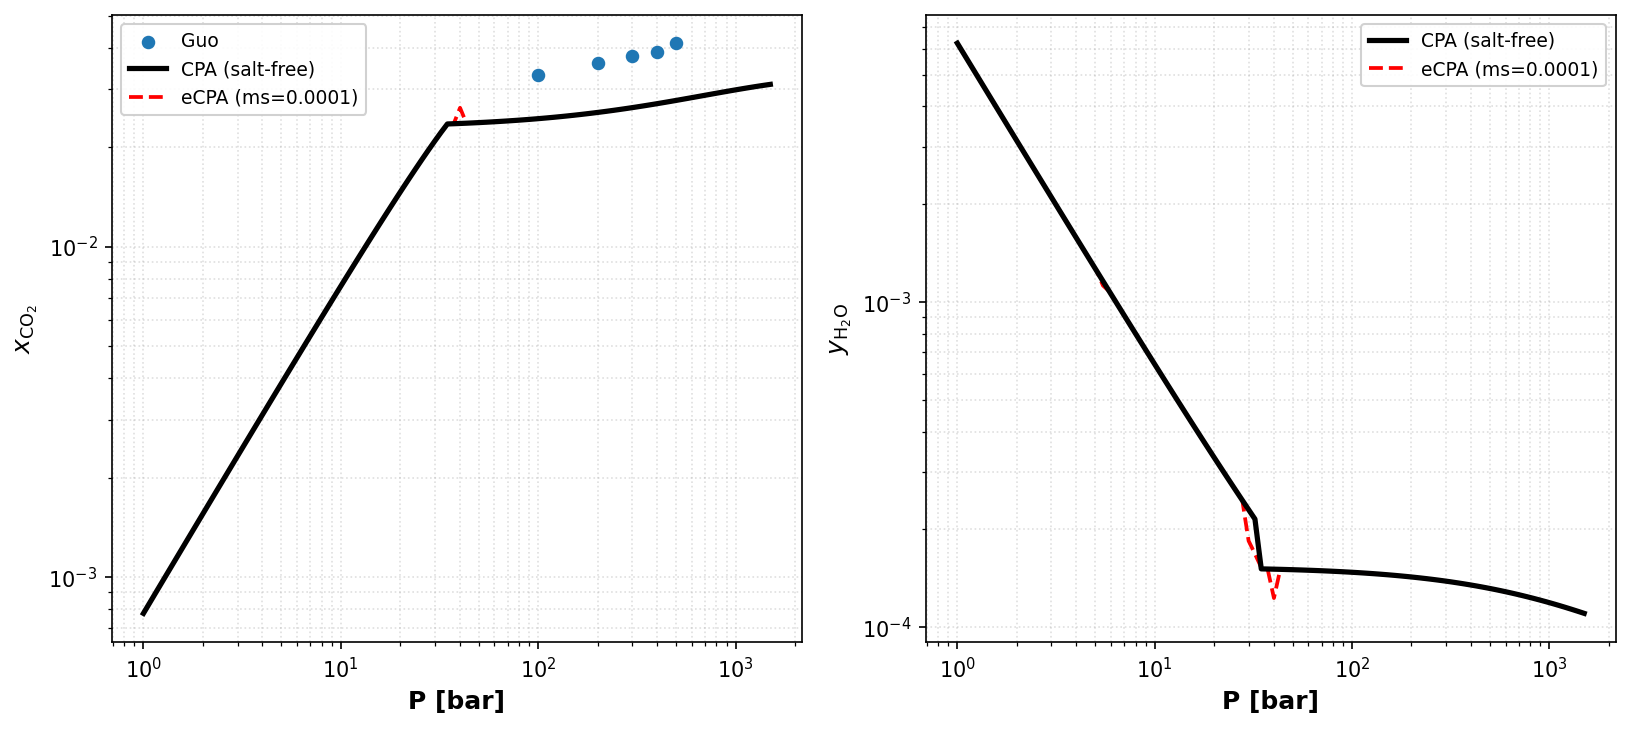

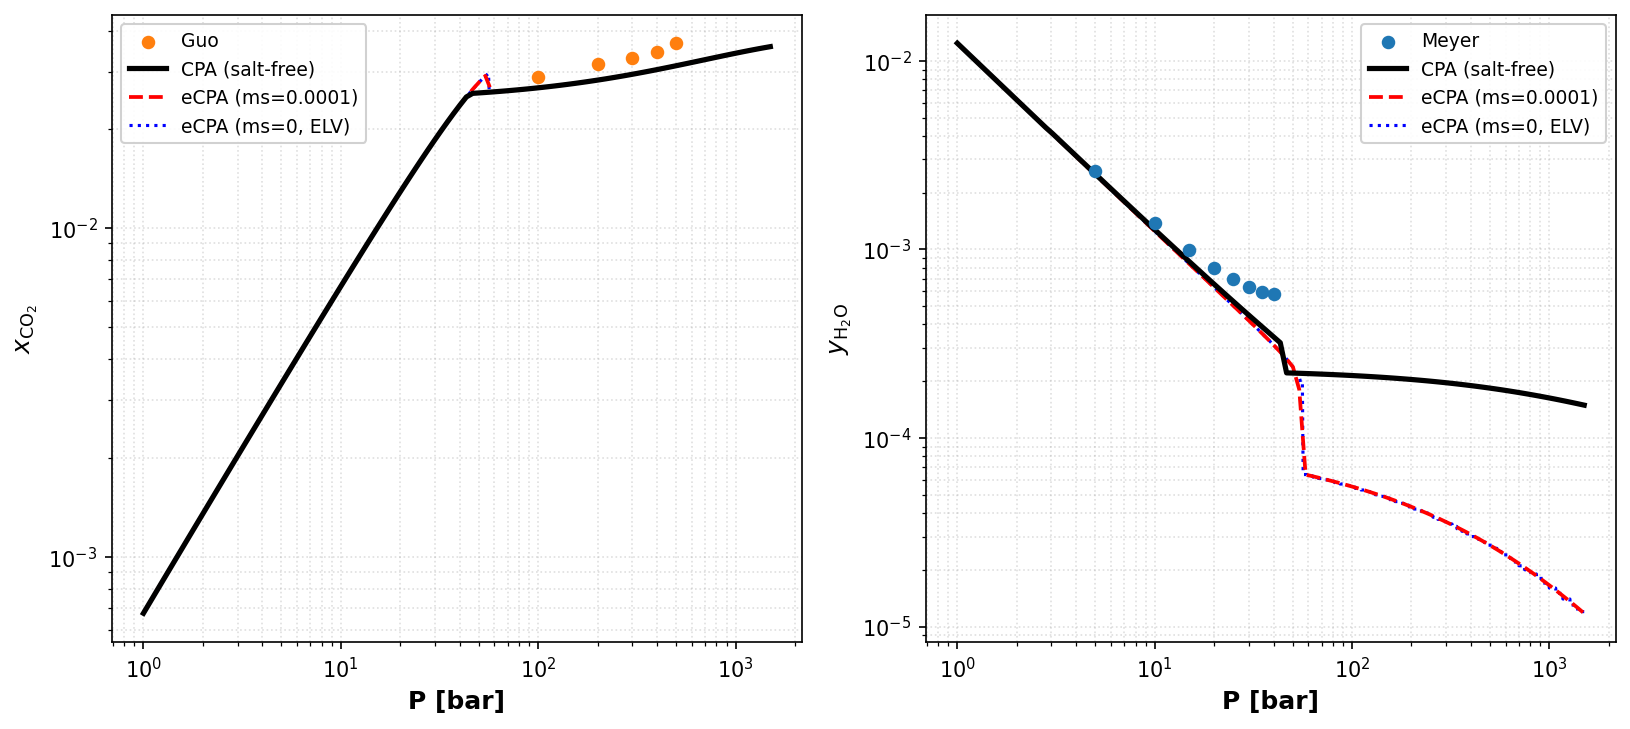

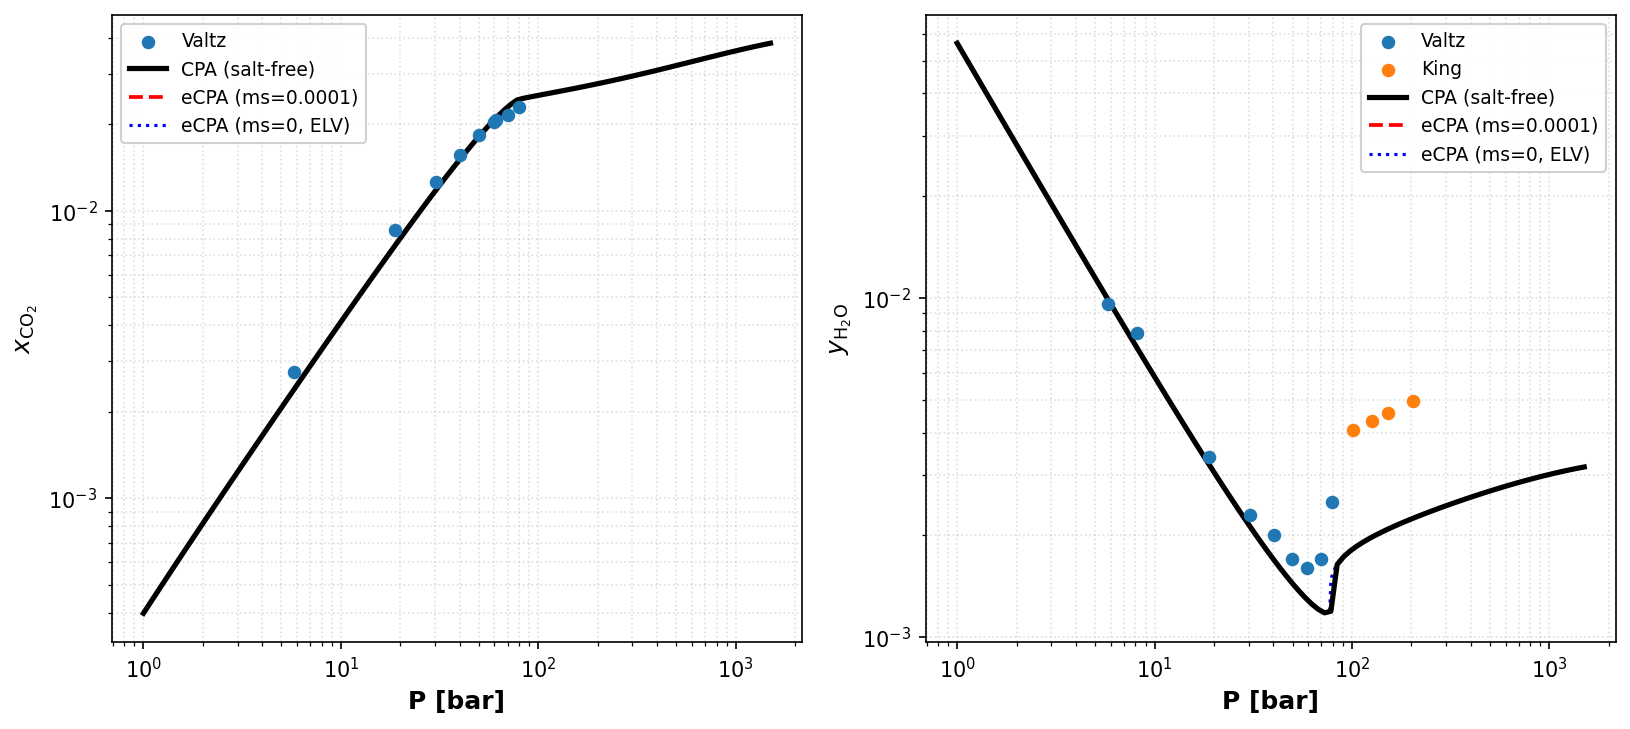

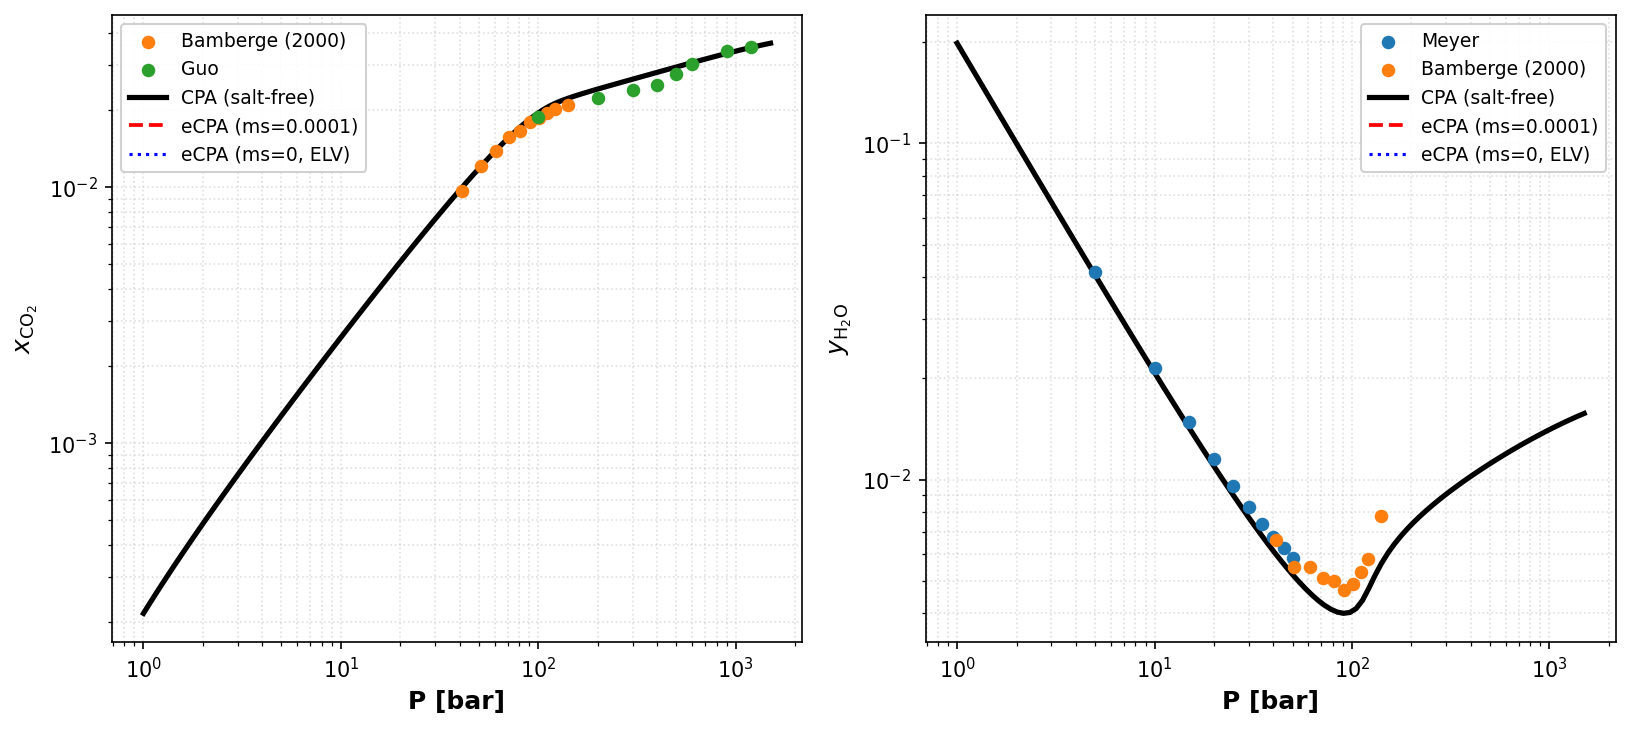

not found (needs RUN_LONG or a prior cell): figures/co2h2o/T363K.png


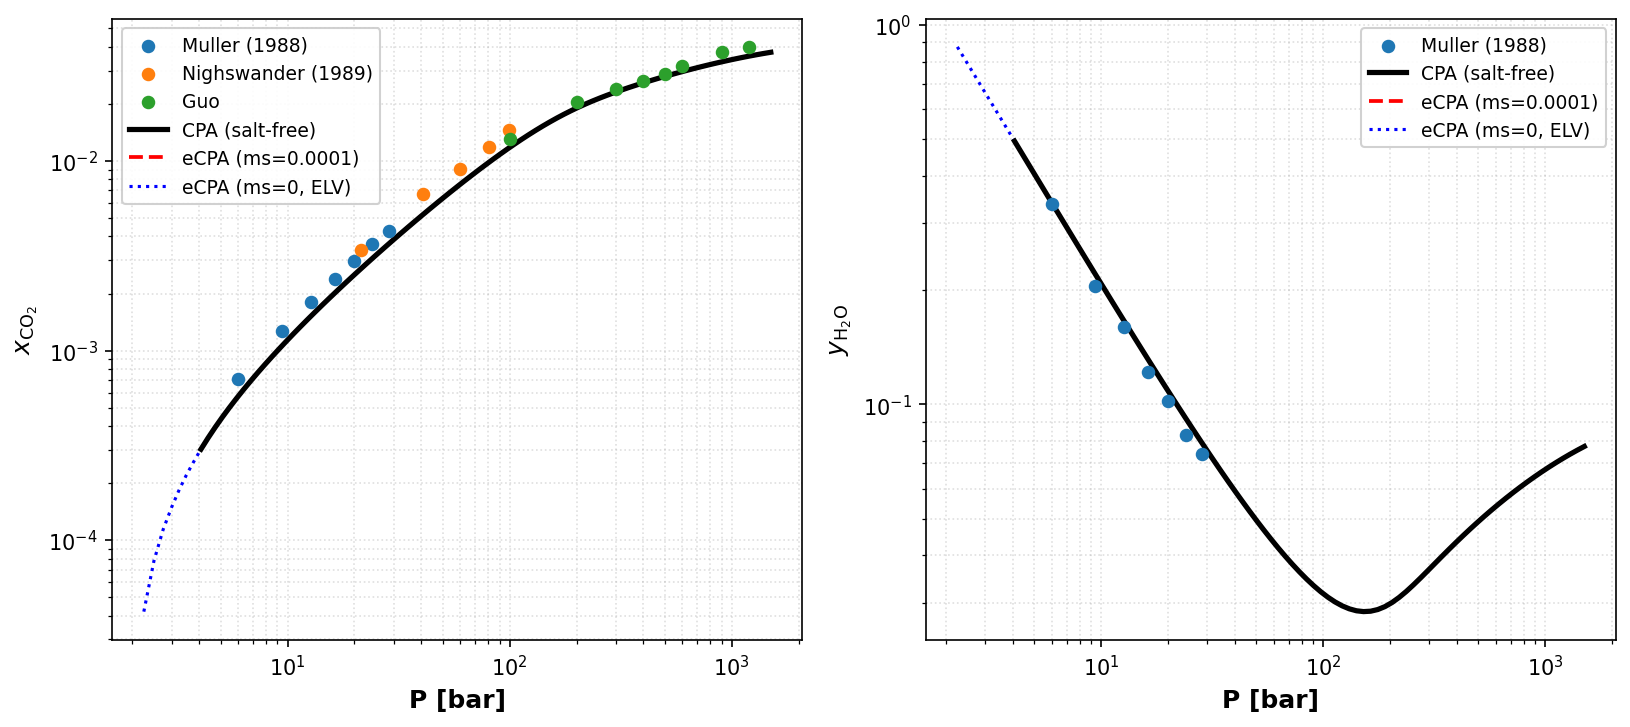

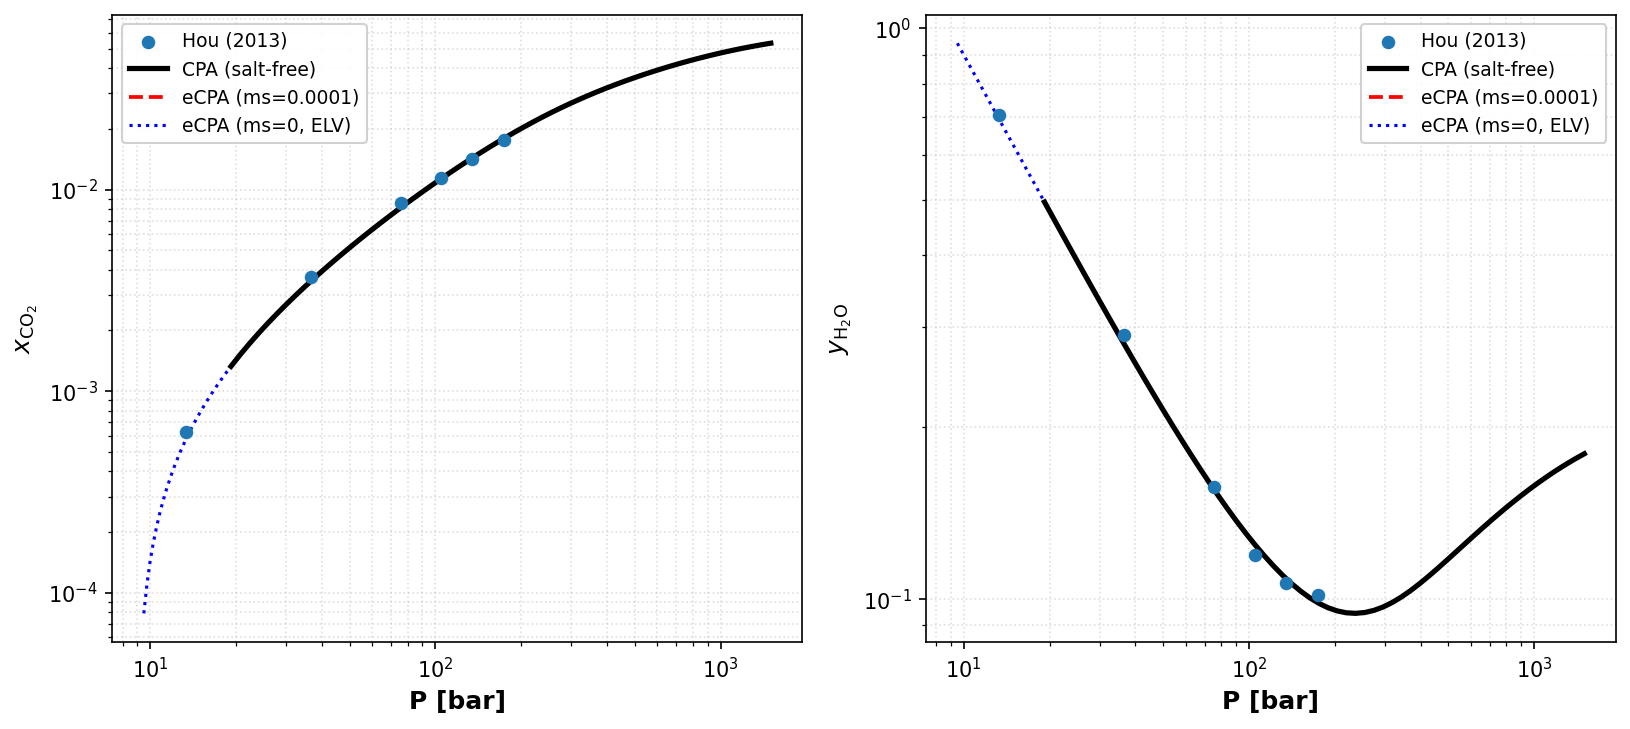

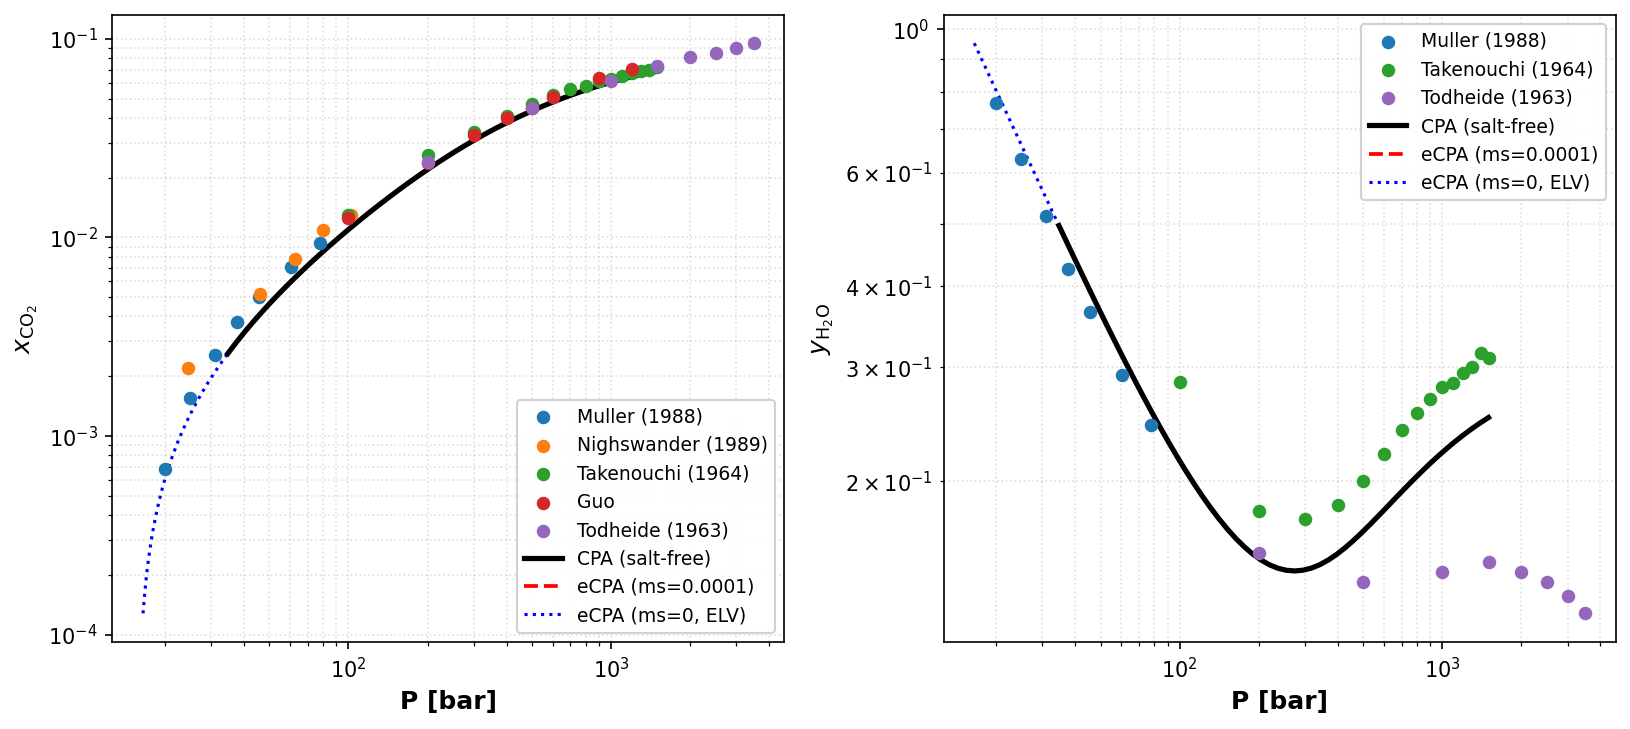

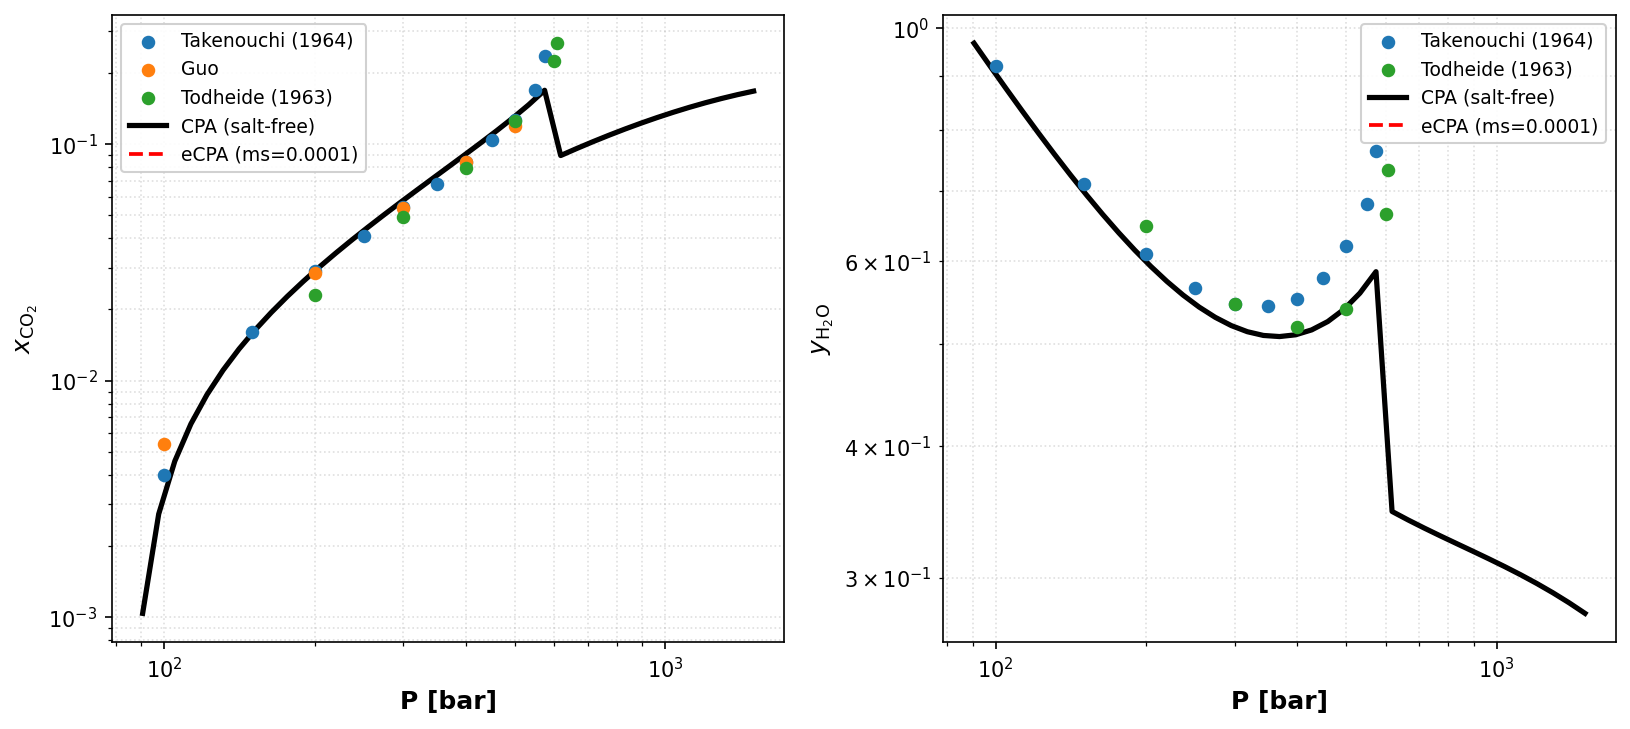

In [12]:
# ▶ Figure S1 — CO2+H2O panels at further temperatures (9 of 32 shown here; the script writes all panels to figures/co2h2o/)
run_once('scripts/plot_co2h2o_figures.py')
show('figures/co2h2o/T273K.png', 'figures/co2h2o/T283K.png', 'figures/co2h2o/T308K.png', 'figures/co2h2o/T333K.png', 'figures/co2h2o/T363K.png', 'figures/co2h2o/T393K.png', 'figures/co2h2o/T448K.png', 'figures/co2h2o/T473K.png', 'figures/co2h2o/T573K.png')


*Figure S1: CO$_2$ + H$_2$O phase equilibria at all 32 temperatures not shown in Fig. 1 of the main text ($0$–$350\,^\circ$C), one temperature per row. For each temperature, we show the CO$_2$ mole fraction in the aqueous phase ($x_{\mathrm{CO_2}}$, left panel) and H$_2$O mole fraction in the CO$_2$-rich phase ($y_{\mathrm{H_2O}}$, right panel) vs. pressure. Open symbols: experimental data<sup>[1](#si-references)</sup>; black solid line: CPA (salt-free); rainbow-colored filled bands: eCPA spanning $m_s = 0$–$6$ mol kg$^{-1}$ (violet to red), with discrete molality contours overlaid. This figure continues through multiple pages; panel temperatures (in °C): 0, 5, 10, 15, 20, 31, 35, 40, 45, 50, 60, 75, 80, 100, 110, 120, 140, 160, 175, 180, 200, 220, 240, 260, 265, 268, 270, 275, 280, 300, 325, 350.*

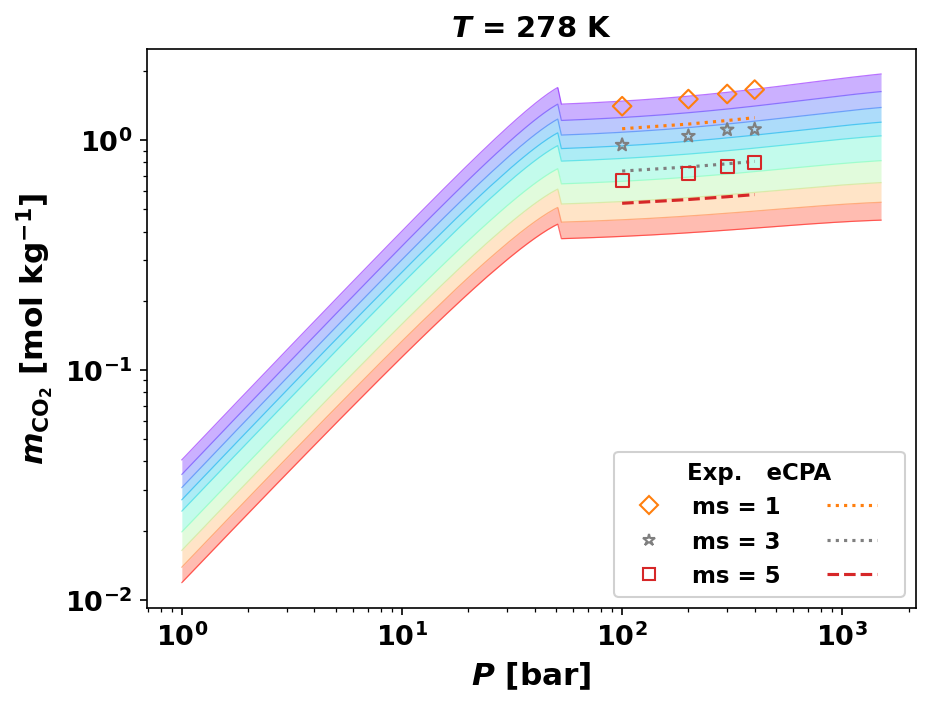

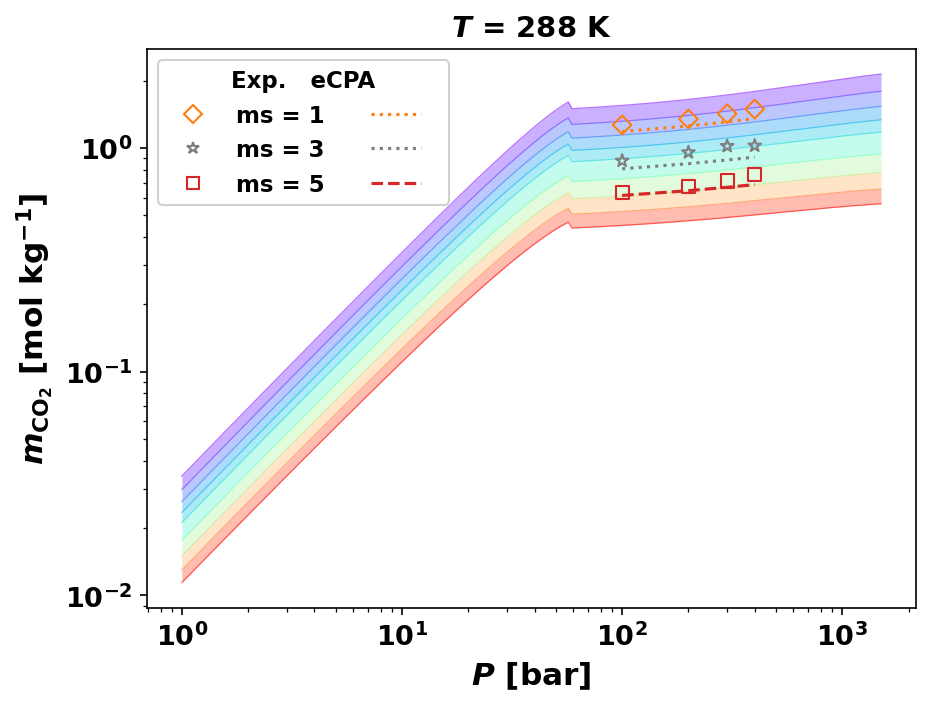

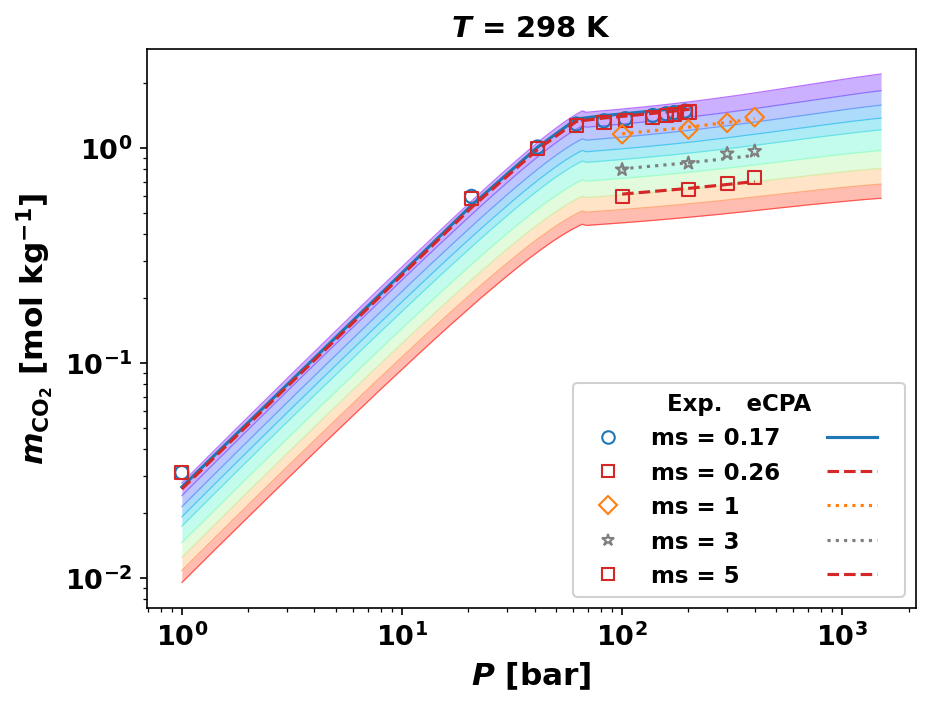

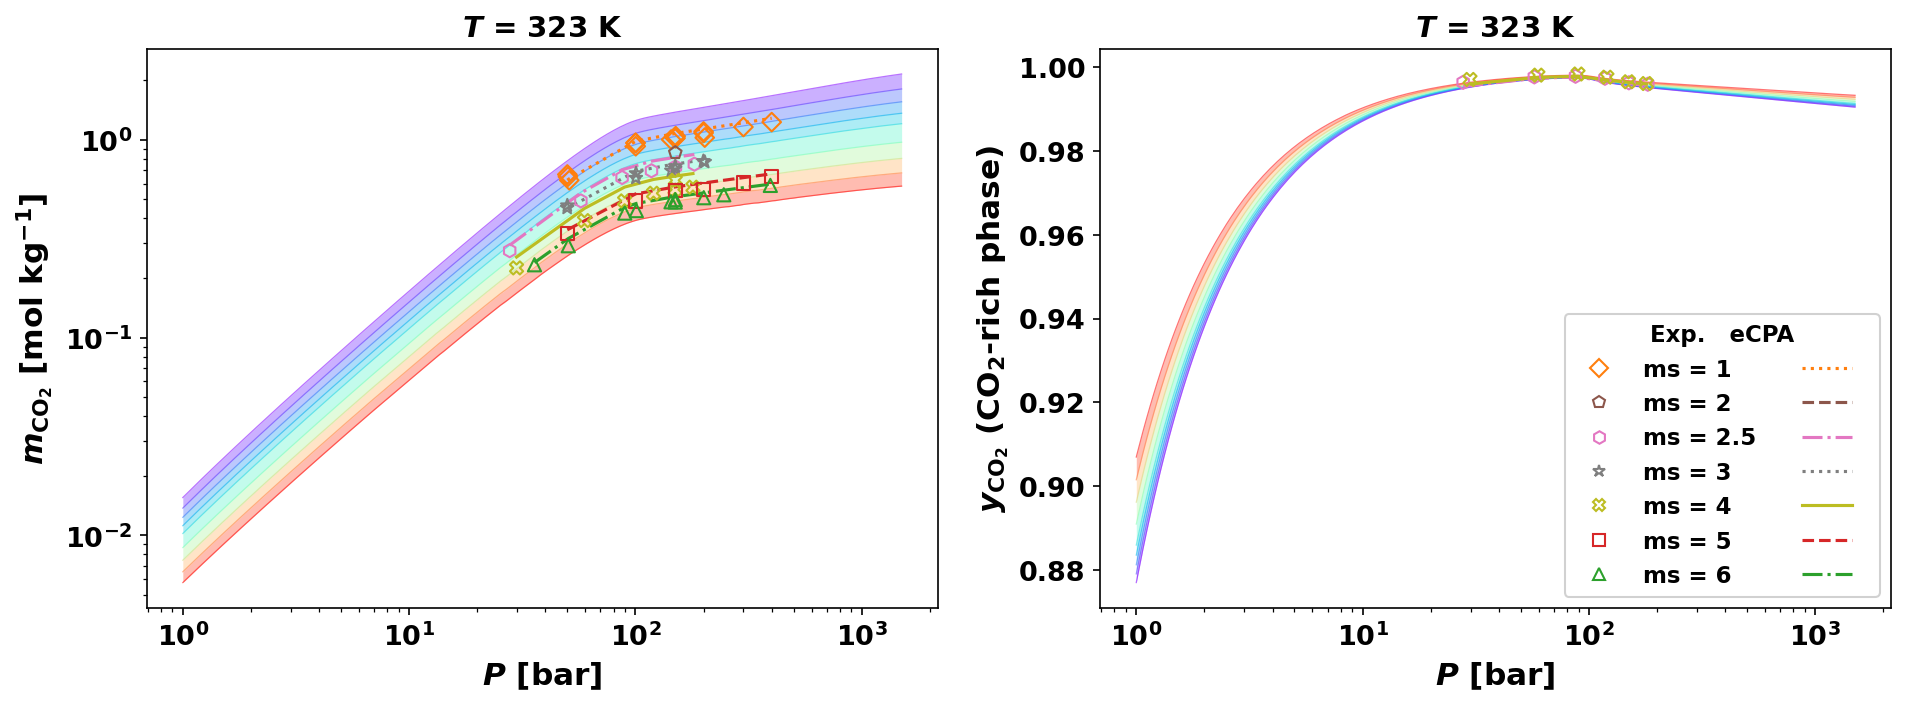

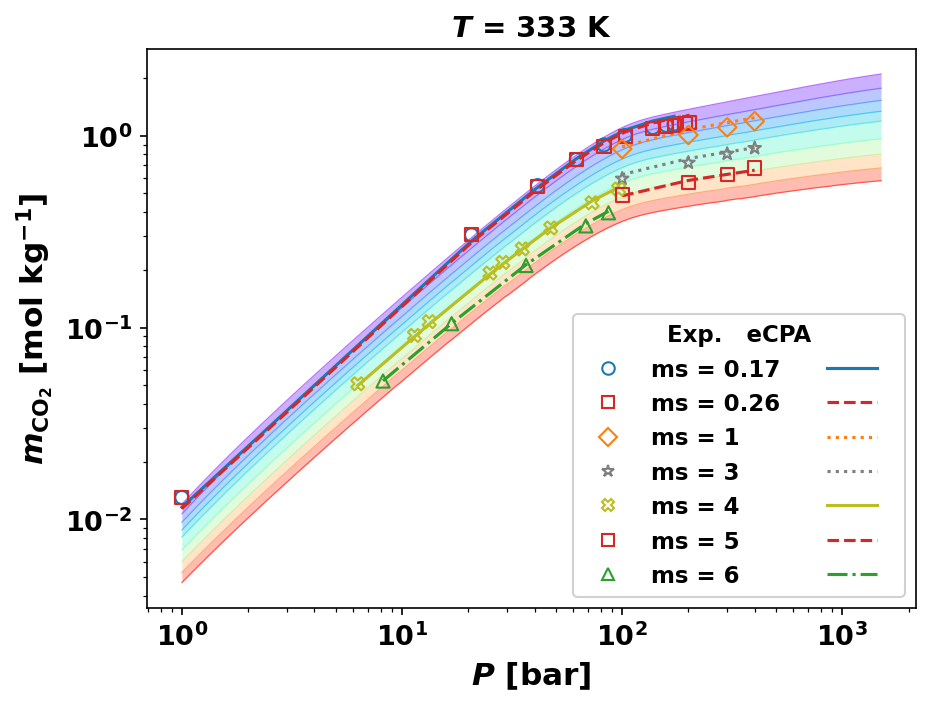

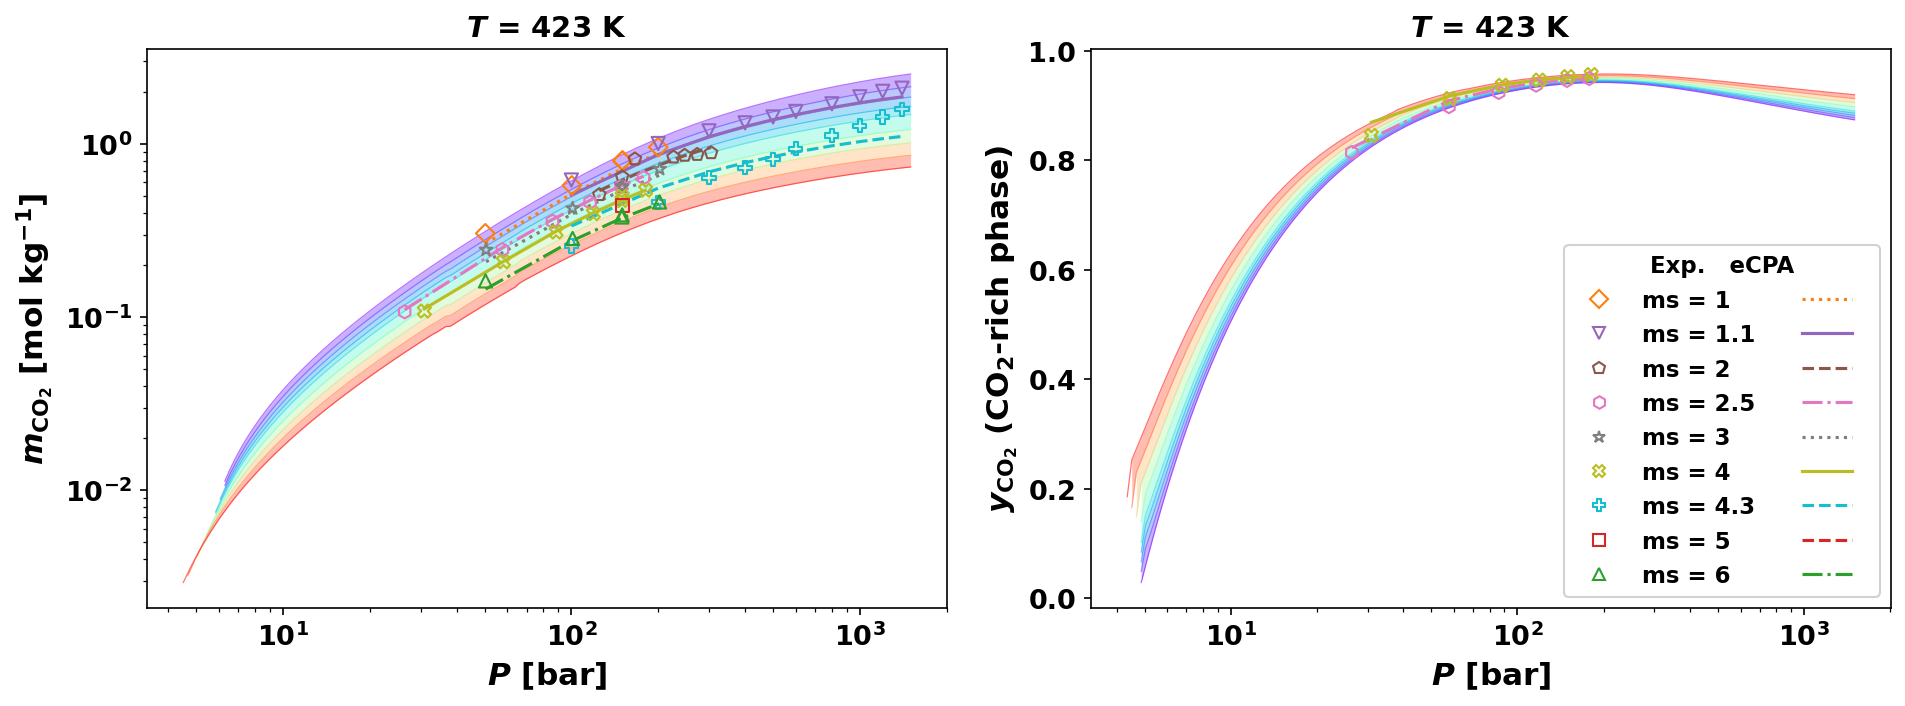

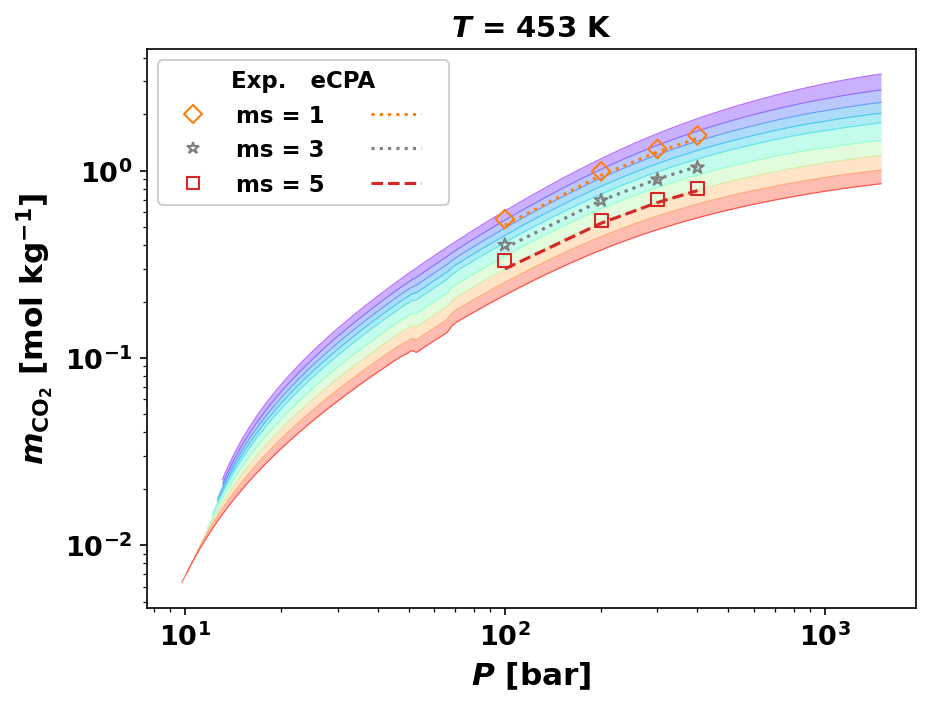

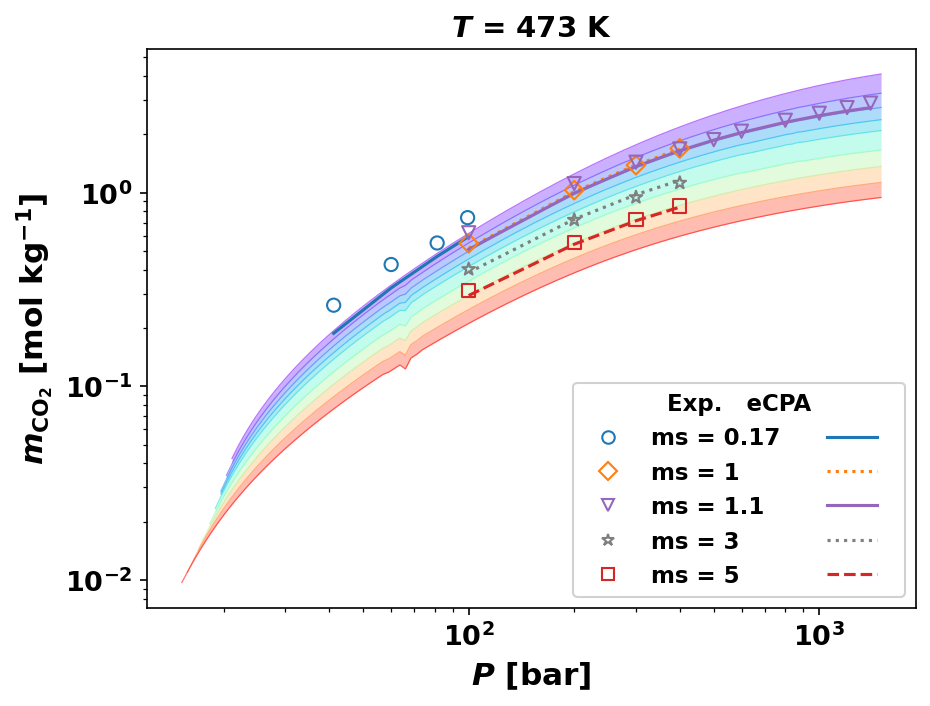

In [13]:
# ▶ Figure S2 — CO2+NaCl panels at further temperatures (8 of 13 shown; all panels in figures/co2nacl/)
run_once('scripts/plot_co2nacl_figures.py')
show('figures/co2nacl/T278K.png', 'figures/co2nacl/T288K.png', 'figures/co2nacl/T298K.png', 'figures/co2nacl/T323K.png', 'figures/co2nacl/T333K.png', 'figures/co2nacl/T423K.png', 'figures/co2nacl/T453K.png', 'figures/co2nacl/T473K.png')


*Figure S2: CO$_2$ solubility in NaCl brine at thirteen temperatures not shown in Fig. 2 of the main text ($5$–$350\,^\circ$C), including data at high NaCl molalities up to $m_s = 6$ mol kg$^{-1}$ from multiple sources. Each panel shows CO$_2$ molality $m_{\mathrm{CO_2}}$ [mol kg$^{-1}$] vs. pressure (log–log). Open symbols: experimental data<sup>[5–13](#si-references)</sup>; discrete lines with markers: eCPA at the experimental NaCl molalities. Rainbow-colored background bands: continuous eCPA predictions across $m_s = 0$–$6$ mol kg$^{-1}$ (color scale as in Fig. 1 of the main text). At $T \geq 400\,^\circ$C, eCPA predicts single-phase (fully miscible) behavior for all available experimental pressures. Panel temperatures (in °C): 5, 10, 15, 20, 25, 45, 60, 140, 160, 180, 200, 300, 350.*

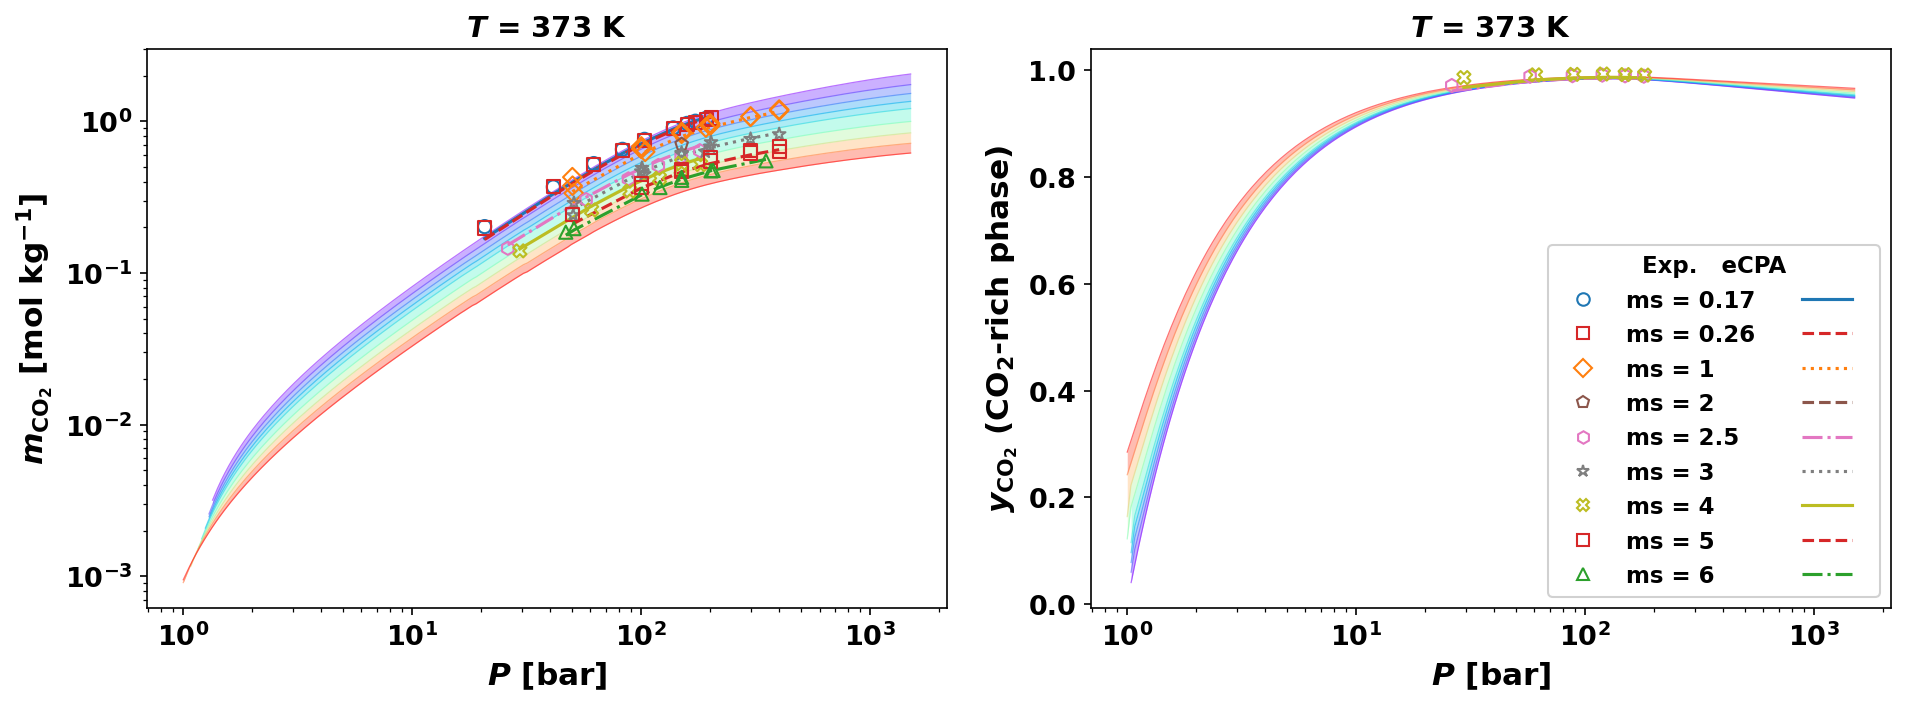

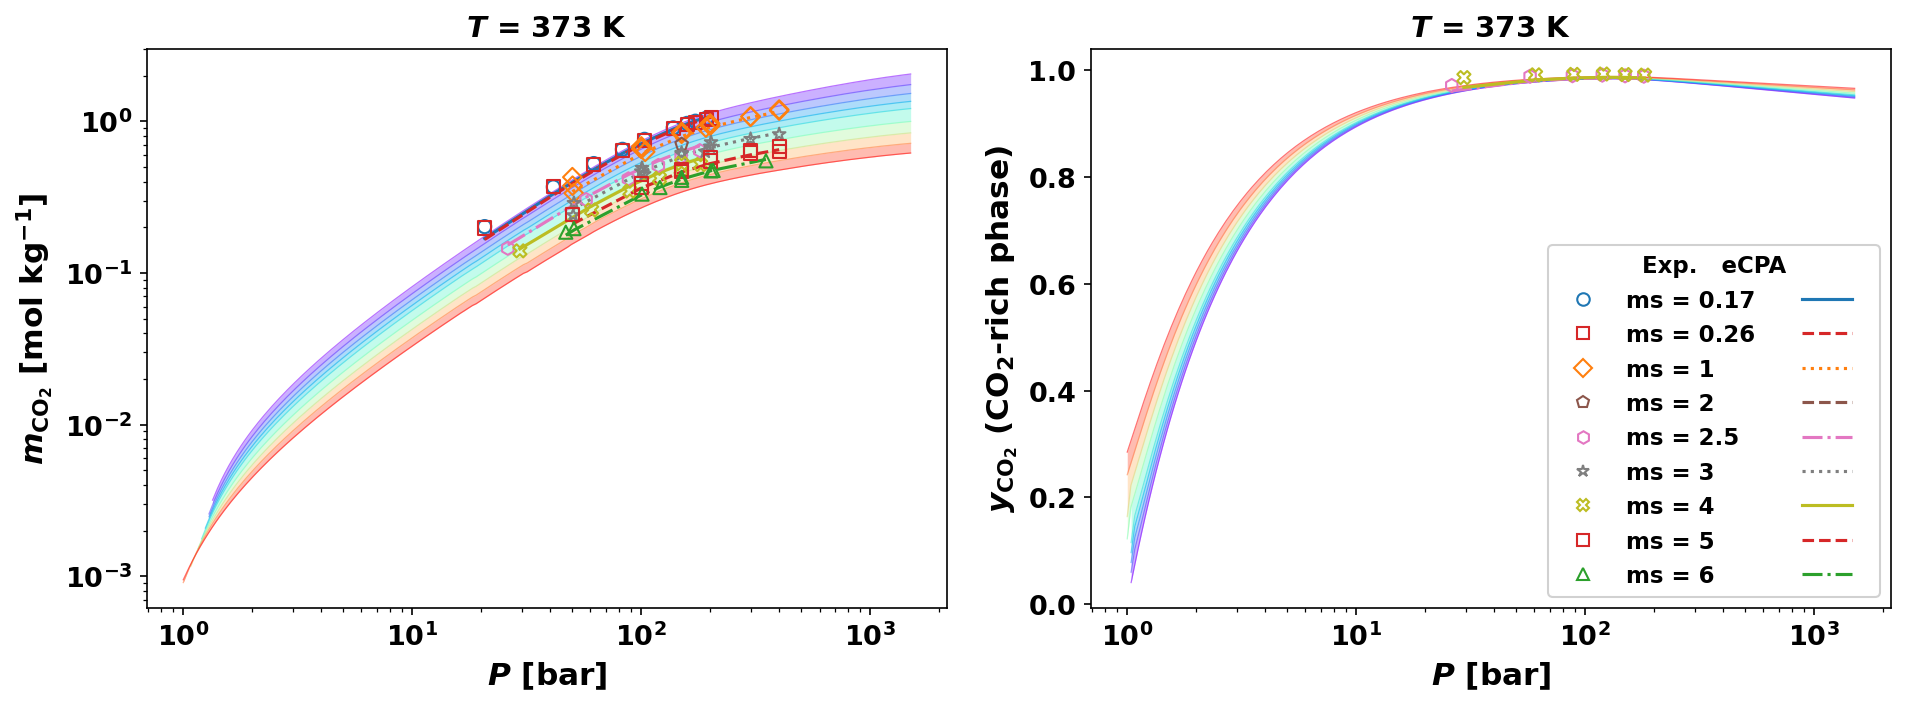

In [14]:
# ▶ Figure S3 — CO2+NaCl at 100 °C, molality and mole-fraction views
run_once('scripts/plot_co2nacl_figures.py')
show('figures/co2nacl/T373K.png', 'figures/co2nacl_ws/T373K.png')


*Figure S3: CO$_2$ + NaCl brine phase equilibria at $T = 100\,^\circ$C for which both CO$_2$ molality $m_{\mathrm{CO_2}}$ (left panel) and CO$_2$ mole fraction in the CO$_2$-rich phase $y_{\mathrm{CO_2}}$ (right panel) data are available. Open symbols: experimental data<sup>[5,7–9,12–18](#si-references)</sup>; discrete lines with markers: eCPA at the experimental NaCl molalities. Rainbow-colored background bands: continuous eCPA predictions across $m_s = 0$–$6$ mol kg$^{-1}$ (color scale as in Fig. 1 of the main text).*

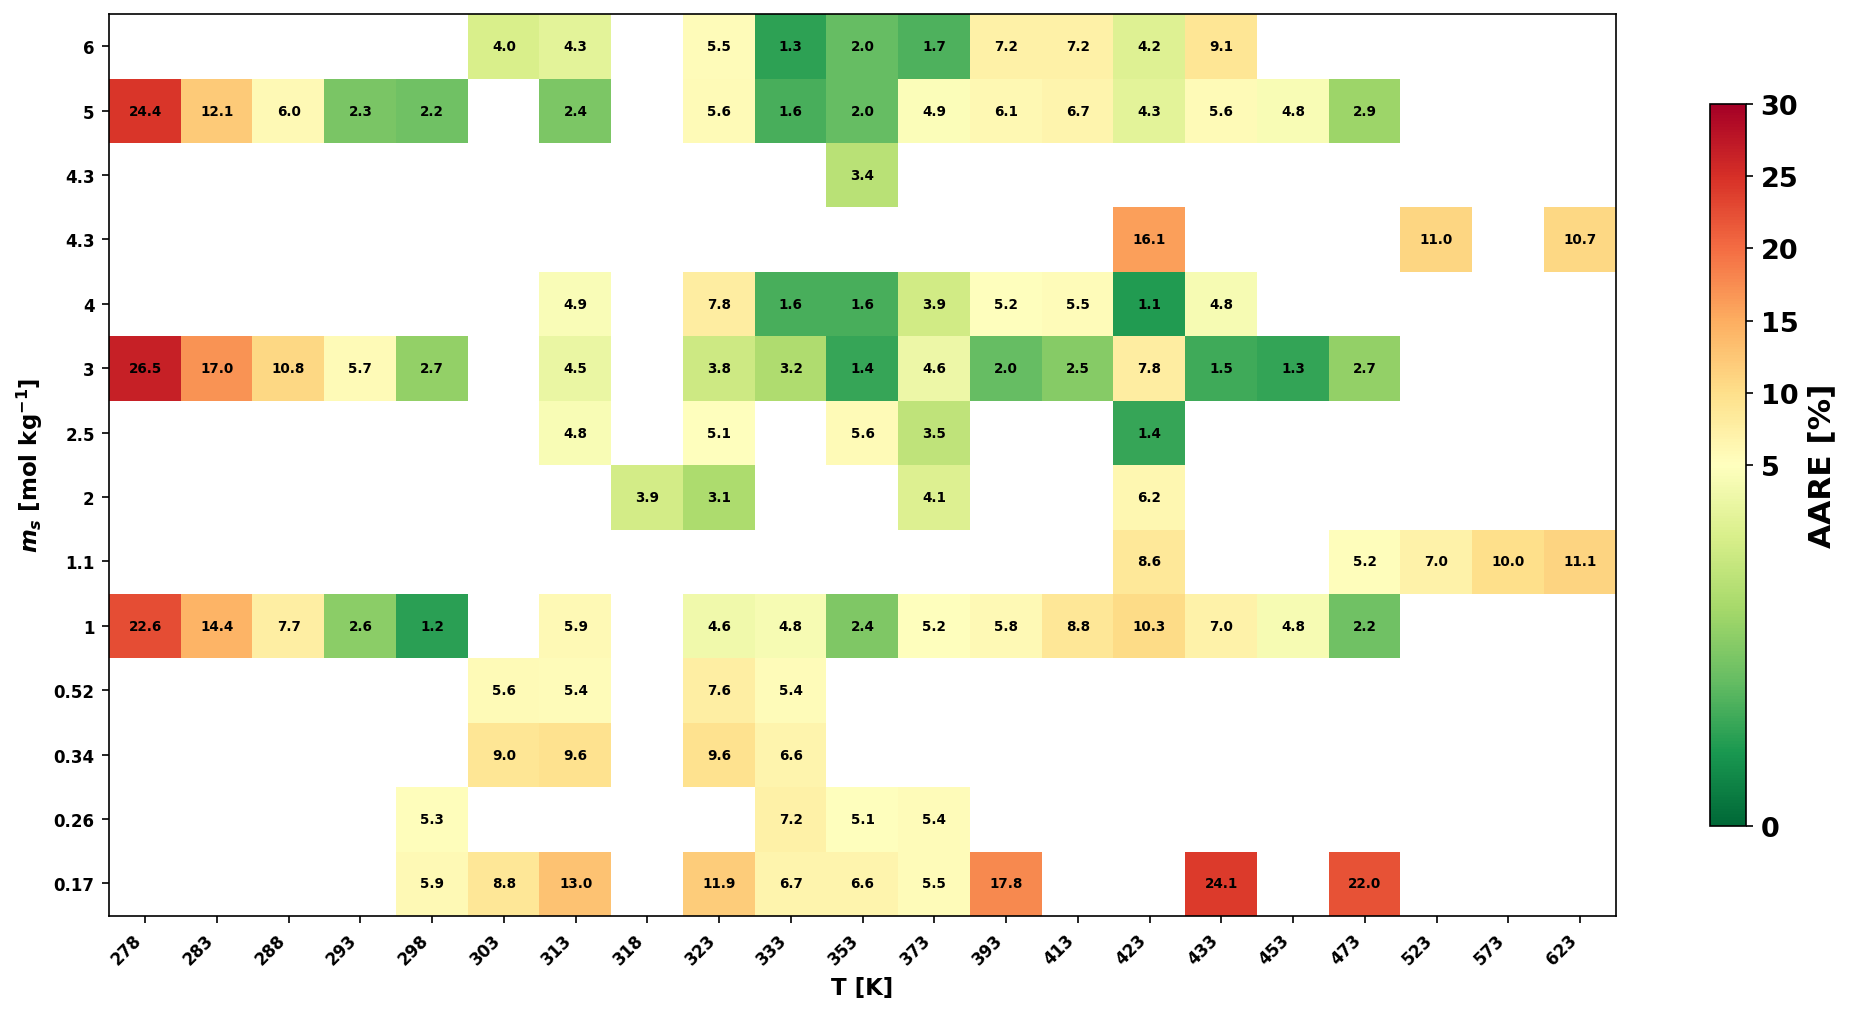

In [15]:
# ▶ Figure S4 — AARE heatmap for the CO2+NaCl validation set
run_once('scripts/plot_co2nacl_figures.py')
show('figures/validation_heatmap_extended.png')


*Figure S4: Heatmap of absolute relative error (AARE, %) for the CO$_2$ + NaCl validation dataset ($T = 5$–$350\,^\circ$C), showing all individual NaCl molalities present in the experimental data. Color scale is diverging at 5%: green $\leq 5\%$, red $\geq 10\%$. Empty cells indicate no experimental data at that $(T, m_s)$ combination.*

<a id="sec38"></a>

### S4.1 Aqueous-phase density: extended validation

We validate pure-water CPA/eCPA density (with the temperature-dependent Péneloux shift, Section S2) against the IAPWS-95 international standard,<sup>[19](#si-references)</sup> whose documented uncertainty in liquid-water density is $\pm0.001$–$0.02\%$<sup>[19](#si-references)</sup> — well below the eCPA model error — over a systematic grid of 26 temperatures ($T = 0$–$350\,^\circ$C) and 20 pressures ($P = 1$–$2\,000$ bar), restricted to liquid/compressed-water conditions (475 points; vapour excluded).
The eCPA density is $\rho = M_{\text{H}_2\text{O}}\,/\,(Z^{\mathrm{aq}} RT/P + c_{\text{H}_2\text{O}}(T))$, where $c_{\text{H}_2\text{O}}(T)$ is the polynomial from Section S2.

The parity plot (Fig. S5) shows tight agreement across the full range.
The signed error map (Fig. S6) is nearly flat, with residual errors $< 0.7\%$ at most conditions; the largest deviations ($\approx 3\%$) occur near $350\,^\circ$C, close to the critical point of water, where cubic-EoS predictions are least accurate.
Overall: AARE = 0.30%, bias = $-$0.20%, maximum ARE = 3.0% (475 liquid conditions).
For subsurface CO$_2$ storage conditions ($T \leq 120\,^\circ$C, $P = 75$–$600$ bar, $N = 136$), the AARE is 0.12%.

perature:
   T [K]    N   CPA AARE   eCPA AARE
     288    8      0.58%       0.58%
     293    5      0.54%       0.54%
     298    5      0.41%       0.41%
     353    5      1.52%       1.52%
     393    5      0.76%       0.76%
     433    4      0.91%       0.91%
     473    5      0.76%       0.76%

Generating eCPA parity plot …
  Saved figures/density/parity_ecpa.png  (AARE = 0.75%)

Done.



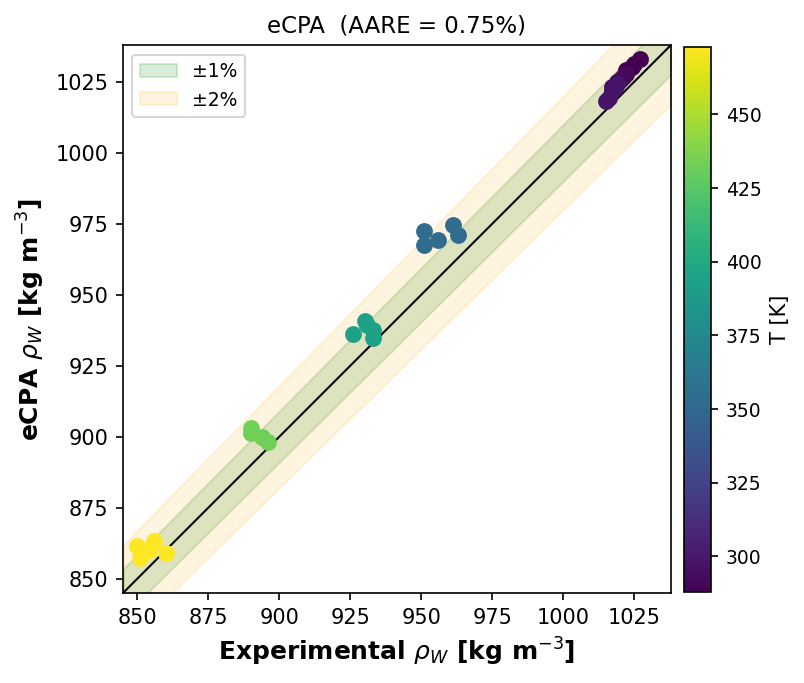

In [16]:
# ▶ Figure S5 — eCPA pure-water density parity vs IAPWS-95 (computes ~1 min)
run_once('scripts/validate_density.py')
show('figures/density/parity_ecpa.png')


*Figure S5: Parity plot: eCPA pure-water density versus IAPWS-95<sup>[19](#si-references)</sup> (475 liquid/compressed-water conditions, $T = 0$–$350\,^\circ$C, $P = 1$–$2\,000$ bar). Left panel: $P \leq 300$ bar; right panel: all conditions up to 2 000 bar. Points are colored by temperature; shaded bands indicate $\pm$1% and $\pm$2% deviations. The temperature-dependent Péneloux shift (Section S2) is applied.*

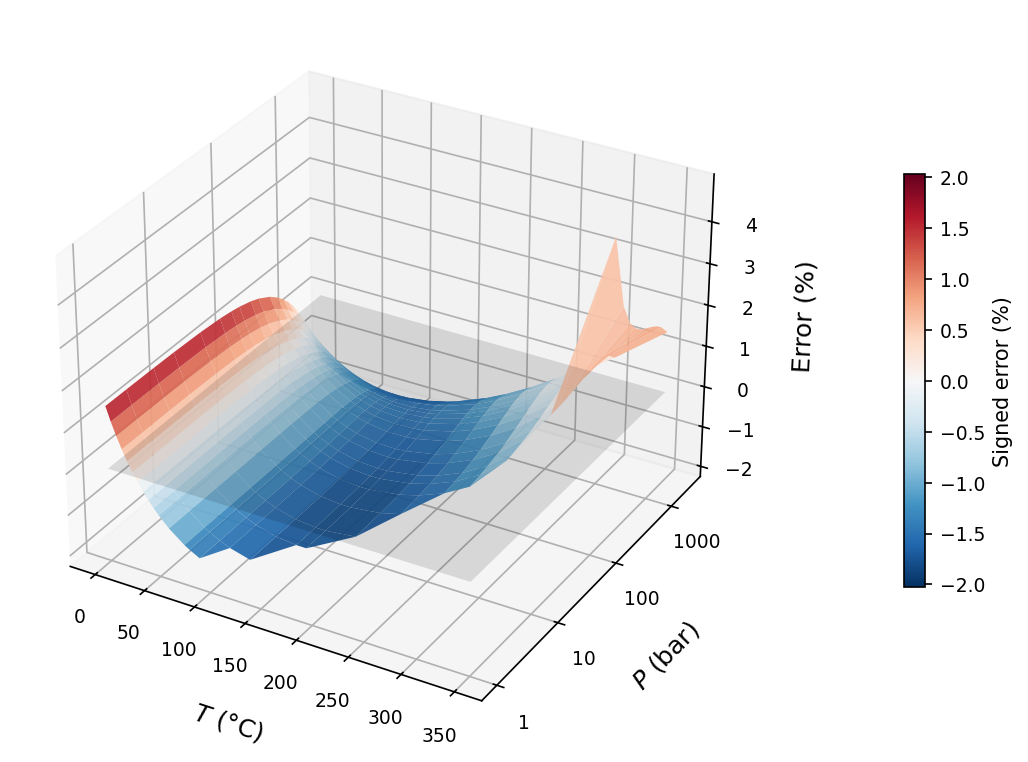

In [17]:
# ▶ Figure S6 — signed density error surface vs IAPWS-95
run_once('scripts/validate_density.py')
show('figures/density/iapws_error_surface.png')


*Figure S6: Signed relative error (eCPA $-$ IAPWS-95) / IAPWS-95 (%) of pure-water density predictions over $T = 0$–$350\,^\circ$C and $P = 1$–$2\,000$ bar (475 liquid/compressed-water conditions; vapour excluded; $P$-axis logarithmic). The temperature-dependent Péneloux shift (Section S2) is applied. The error field is nearly flat ($< 0.7\%$ over most of the domain); the largest deviations ($\approx 3\%$) occur near $350\,^\circ$C at moderate pressures, close to the critical point of water.*

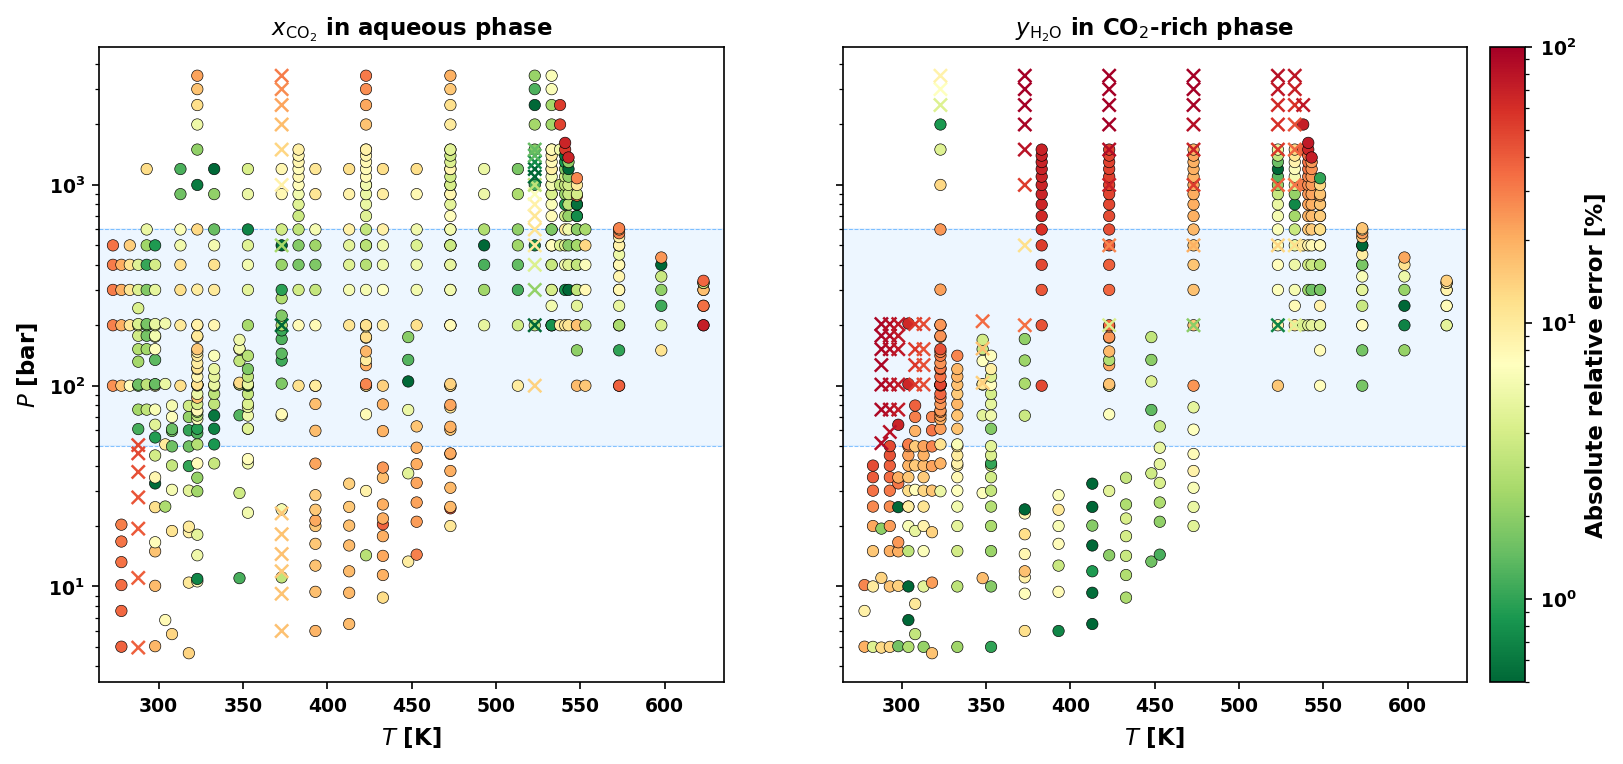

In [18]:
# ▶ Figure S7 — CO2+H2O absolute-relative-error map
run_once('scripts/plot_co2h2o_figures.py')
show('figures/co2h2o/error_heatmap.png')


*Figure S7: Absolute relative error of eCPA predictions for the CO$_2$ + H$_2$O binary as a function of temperature and pressure. Left: CO$_2$ solubility in the aqueous phase ($x_{\mathrm{CO_2}}$). Right: H$_2$O content in the CO$_2$-rich phase ($y_{\mathrm{H_2O}}$). Marker color indicates error magnitude (green $< 5\%$, yellow $\approx 10\%$, red $> 30\%$); crosses mark points flagged as outliers by cross-reference consistency analysis. The blue shaded band highlights the pressure range most relevant to subsurface CO$_2$ storage ($P = 50$–$600$ bar).*

<a id="sec39"></a>

### S4.2 Simplified flash: detailed accuracy and efficiency

Table S5 reports the AARE in dissolved CO$_2$ molality $m_{\mathrm{CO_2}}$ and the mean $y_{\mathrm{H_2O}}$ in the CO$_2$-rich phase from the full flash as a function of temperature, evaluated over 3,285 two-phase conditions spanning $P = 25$–$800$ bar, $z_{\mathrm{CO_2}} = 0.01$–$0.70$, and $m_s = 1$–$6$ mol kg$^{-1}$.
The two quantities track each other closely: the simplified flash introduces an error in $m_{\mathrm{CO_2}}$ that equals, to a good approximation, the water content it neglects.

**Table S5:** Accuracy of the simplified flash ($y_{\mathrm{H_2O}} = 0$) relative to the full K-value SSI flash, evaluated over 3,285 two-phase conditions spanning $P = 25$–$800$ bar, $z_{\mathrm{CO_2}} = 0.01$–$0.70$, and $m_s = 1$–$6$ mol kg$^{-1}$. AARE: average absolute relative error in CO$_2$ molality $m_{\mathrm{CO_2}}$; $\langle y_{\mathrm{H_2O}}\rangle$: mean H$_2$O mole fraction in the CO$_2$-rich phase from the full flash (proxy for the assumption error).

| $T$ (K) | $T$ (°C) | $N$ | AARE in $m_{\mathrm{CO_2}}$ (%) | $\langle y_{\mathrm{H_2O}}\rangle$ (mol%) |
|---|---|---|---|---|
| 283 | 10 | 239 | 0.03 | 0.02 |
| 298 | 25 | 239 | 0.11 | 0.08 |
| 313 | 40 | 240 | 0.37 | 0.27 |
| 323 | 50 | 240 | 0.62 | 0.45 |
| 333 | 60 | 240 | 0.93 | 0.68 |
| 348 | 75 | 239 | 1.55 | 1.15 |
| 353 | 80 | 240 | 1.80 | 1.34 |
| 373 | 100 | 238 | 3.16 | 2.35 |
| 393 | 120 | 239 | 5.37 | 3.91 |
| 413 | 140 | 237 | 8.95 | 6.19 |
| 423 | 150 | 237 | 11.67 | 7.72 |
| 453 | 180 | 235 | 25.49 | 14.01 |
| 473 | 200 | 231 | 45.85 | 19.79 |
| 523 | 250 | 191 | 121.28 | 33.51 |

Figure S8 summarises the AARE in $m_{\mathrm{CO_2}}$, the mean $y_{\mathrm{H_2O}}$ from the full flash, and the wall-time speedup as functions of temperature.
Figure S9 breaks the AARE down by NaCl molality; the error curves for all salinities are nearly coincident, confirming that the accuracy of the $y_{\mathrm{H_2O}} = 0$ approximation is controlled entirely by temperature.

The mean wall time is essentially identical to the full flash (speedup $0.8\times$): Brent root-finding requires on average 11.3 inner Newton evaluations, whereas the full SSI needs 6.4 outer iterations each involving at most two inner solves.
The inner Newton cost per call is similar in both paths, so the Brent overhead offsets the gain from eliminating the outer salt iteration.
The principal benefits of the simplified flash are therefore conceptual — the equilibrium reduces to a single scalar CO$_2$-solubility equation — and robustness in salt-free settings where the ternary outer salt loop is absent by construction.

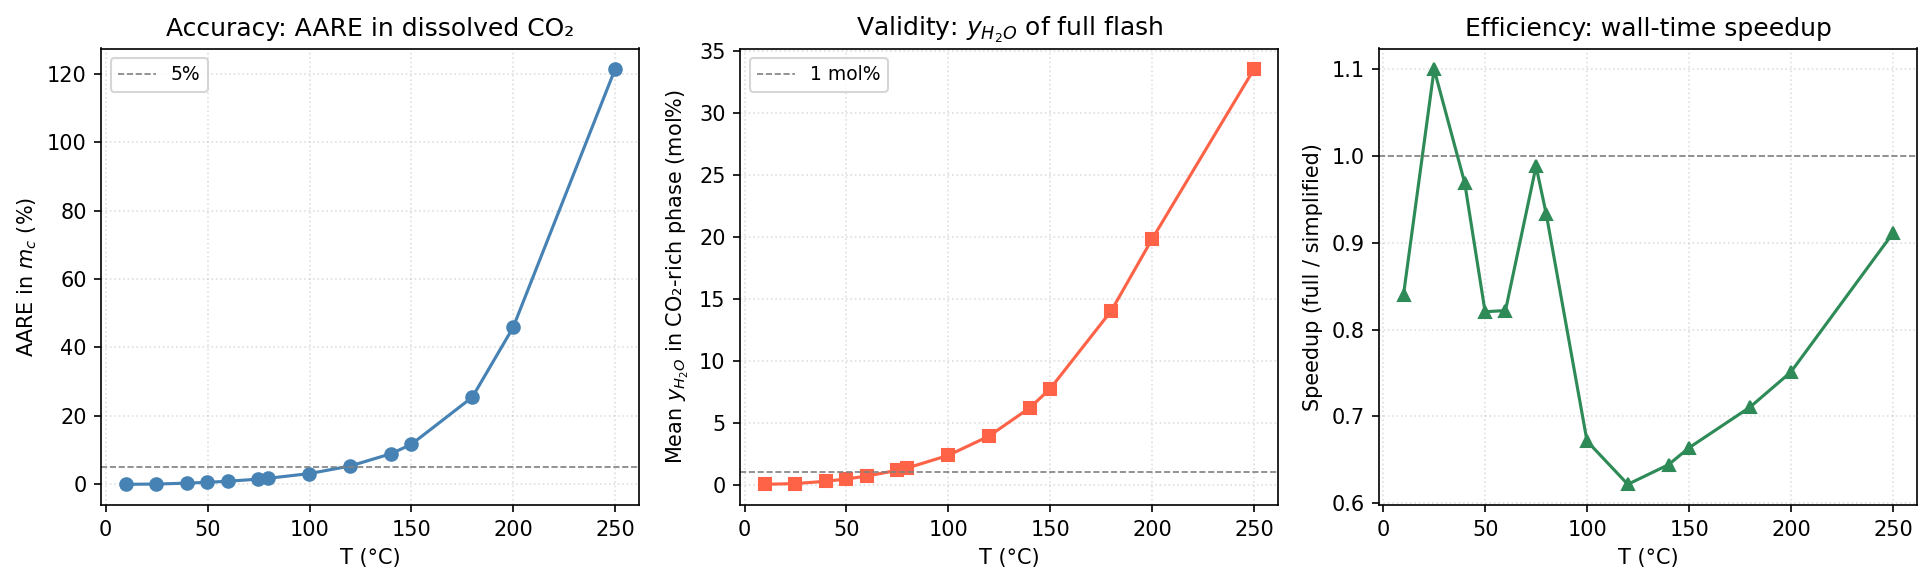

In [19]:
# ▶ Figure S8 — simplified-flash benchmark (3,285 conditions)
# NOTE: full recompute — set RUN_LONG = True in the setup cell to enable (~10 min on a laptop).
if RUN_LONG:
    run_once('scripts/benchmark_simplified_flash.py')
show('figures/simplified/accuracy_vs_T.png')


*Figure S8: Simplified flash benchmark over 3,285 two-phase conditions ($P = 25$–$800$ bar; $z_{\mathrm{CO_2}} = 0.01$–$0.70$; $m_s = 1$–$6$ mol kg$^{-1}$). **Left**: AARE in dissolved CO$_2$ molality $m_{\mathrm{CO_2}}$ as a function of temperature; the dashed line marks 5%. **Middle**: mean H$_2$O mole fraction in the CO$_2$-rich phase from the full flash, which directly quantifies the magnitude of the $y_{\mathrm{H_2O}} = 0$ assumption; dashed line at 1 mol%. **Right**: ratio of mean full-flash wall time to simplified-flash wall time; the two methods are essentially iso-cost across all temperatures.*

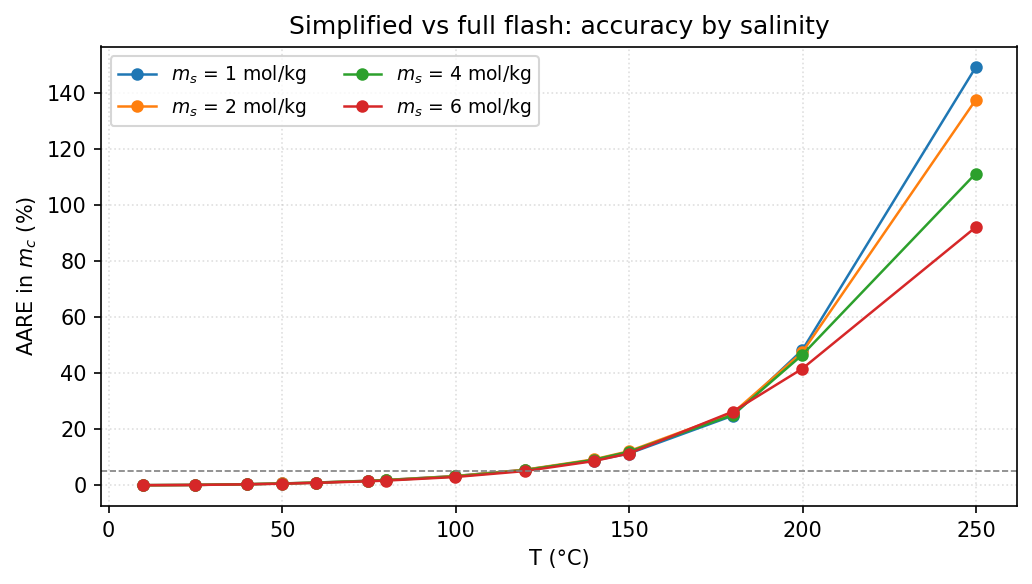

In [20]:
# ▶ Figure S9 — simplified vs full flash AARE
# NOTE: full recompute — set RUN_LONG = True in the setup cell to enable (~10 min on a laptop).
if RUN_LONG:
    run_once('scripts/benchmark_simplified_flash.py')
show('figures/simplified/accuracy_by_ms.png')


*Figure S9: AARE in dissolved CO$_2$ molality $m_{\mathrm{CO_2}}$ of the simplified flash versus the full K-value SSI, broken down by NaCl molality ($m_s = 1$–$6$ mol kg$^{-1}$). The error curves for different salinities are nearly coincident, confirming that the accuracy of the $y_{\mathrm{H_2O}} = 0$ approximation is controlled entirely by temperature and is insensitive to brine salinity. The dashed line marks 5%.*

<a id="sec40"></a>

## S5. Computational Performance Figures

This section supplements the convergence and efficiency analysis of the main text.
Figure S10 shows the SSI+Newton iteration breakdown and wall-time ratio across the full parameter-space scan, and Fig. S11 compares all flash initialization strategies in terms of convergence rate and mean iteration count.

Flash output keys: ['T', 'P_bar', 'z_co2', 'm_tot', 'n_totals', 'ms_aq', 'N_aq', 'N_c', 'beta', 'x_aq', 'x_c', 'Z_aq', 'Z_c', 'sol', 'n_iter_ms', 'n_ssi_iter', 'n_newton_iter', 'K_vals', 'sol_aq_x0', 'sol_c_x0']
Newton iter counts NOT in flash output. Using wall-time proxy figure instead.
Generating simplified figure from wall_time distribution...
  → ecpa_newton_stats.pdf (wall-time proxy)



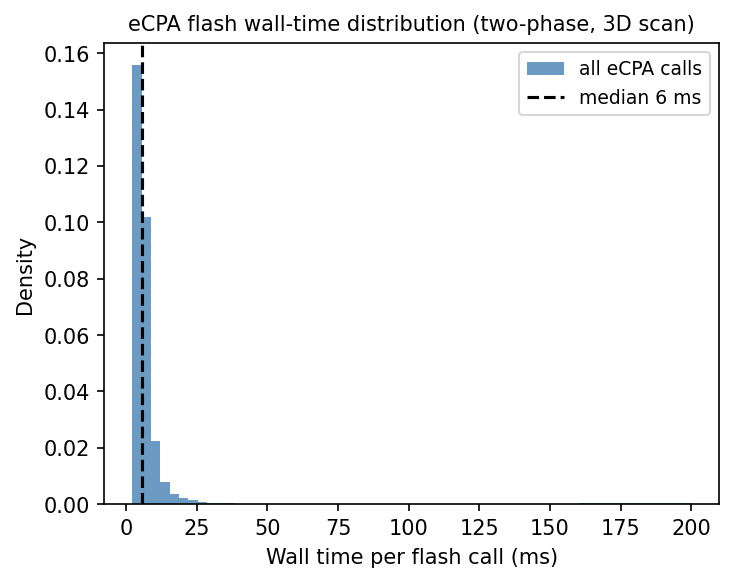

In [21]:
# ▶ Figure S10 — SSI+Newton iteration breakdown (cached scan)
run_once('scripts/plot_newton_stats.py')
show('figures/scan_v4/ecpa_newton_stats.png')


*Figure S10: SSI + Newton polish iteration breakdown and wall-time ratio across the parameter-space scan (9,825 two-phase points, averaged over $z_{\mathrm{CO_2}}$). Left: mean SSI iteration count before Newton polish is triggered ($\|\mathbf{g}\| < 10^{-4}$); the near-CO$_2$-critical region ($T \approx 7$–$57\,^\circ$C) requires the most SSI iterations even with table warm-start. Center: mean Newton iteration count; most of the domain converges in 2–3 Newton steps after 1–5 SSI steps, while the critical region (blue) often reverts to SSI before Newton is beneficial. Right: wall-time ratio (SSI-only / SSI+Newton); values $>1$ (green) indicate that Newton polish is faster; values $<1$ (red) indicate that the SSI-only path is faster (primarily near the CO$_2$ critical point where Newton reversion adds overhead).*

In [22]:
# ▶ Figure S11 — CPA flash strategy comparison
# NOTE: full recompute — set RUN_LONG = True in the setup cell to enable (~30 min on a laptop).
if RUN_LONG:
    run_once('scripts/run_parameter_scan.py')
    run_once('scripts/run_newton_scan.py')
    run_once('scripts/plot_newton_figures.py')
show('figures/scan/strategy_comparison_bar.png')


not found (needs RUN_LONG or a prior cell): figures/scan/strategy_comparison_bar.png


*Figure S11: CPA flash strategy comparison across all 9,825 two-phase conditions of the salt-free CO$_2$ + H$_2$O parameter-space scan ($T = 0$–$425\,^\circ$C, $P = 1$–$1500$ bar, $z_{\mathrm{CO_2}} = 0.001$–$0.999$). (a) Convergence rate; (b) mean total iterations (converged points only). Strategies are ordered from simplest cold-start (standard SSI with Wilson K) to the most optimized (table warm-start with SSI and Newton polish). The final strategy achieves a 73% reduction in mean iterations relative to the standard cold-start baseline.*

<a id="sec41"></a>

## S6. Reservoir Simulation Details

This section supplements the reservoir simulation section of the main text, providing full details of the numerical scheme (pressure solver, transport discretization, well model), the complete simulation parameter set (Table S6), spatial results and flash performance at $t = 5$ yr (Figs. S12–S13; Table S7).

### Numerical scheme

Pressure is solved implicitly at each time step on a uniform Cartesian grid using either a two-point flux approximation (TPFA<sup>[20](#si-references)</sup>) or a lowest-order mixed finite element (MFE, RT$_0$) scheme.<sup>[21](#si-references)</sup>
Both were implemented and tested; results shown here use MFE, which avoids the pronounced grid-orientation artefacts of TPFA on Cartesian grids while remaining computationally inexpensive.<sup>[22–24](#si-references)</sup>
The solved pressure field yields Darcy velocities that drive explicit first-order upwind advection of the overall CO$_2$ mole fraction $z_{\mathrm{CO_2}}$.
The transport sub-step size is constrained by a CFL condition based on the maximum slope of the molar fractional flow $\partial F / \partial z_{\mathrm{CO_2}}$, estimated by a one-dimensional scan at startup.
Production wells are controlled by a fixed bottom-hole pressure (BHP); the injector delivers a fixed volumetric rate.

At each time step, the full Michelsen stability test followed by the two-phase flash is called at every grid cell, using the cell pressure from the previous time step (standard IMPES lagged-pressure).
For the eCPA case ($m_s > 0$) the warm-started K-value flash with hierarchical stability fallback is used; for the salt-free case ($m_s = 0$) the CPA warm-started flash is used.
NaCl is non-volatile; the equilibrium aqueous molality $m_s^{\mathrm{aq}}$ returned by the flash reflects local salting-out and is used directly in the saturation calculation.

We deliberately replace the true compressible volume-rate divergence by the incompressible constraint $\nabla\cdot\mathbf{u} = q$.
This neglects buoyancy, compressibility, and the density difference between injected and displaced fluid.
We state this limitation explicitly because neglecting it removes the main physical driver of CO$_2$ plume geometry in real aquifer storage, and readers should not interpret the results as quantitative predictions.
The purpose is solely to confirm that the stability and flash routines converge reliably and efficiently at every cell of a $50{\times}50$ grid over 300 time steps spanning 5 years.

<a id="sec42"></a>

### Simulation setup

Two simulations are run on identical grids with identical flow parameters, differing only in brine salinity:

- **Case A (CPA):** salt-free brine, $m_s = 0$ mol kg$^{-1}$
- **Case B (eCPA):** saline brine, $m_s = 4$ mol kg$^{-1}$ NaCl

The domain is a $100\times100$ m$^2$ square of 10 m thickness discretized onto a $50\times50$ Cartesian grid ($N = 2500$ cells) with homogeneous permeability of 100 mD and porosity $\phi = 0.20$.
A five-spot well pattern is used: a CO$_2$ injector at the domain center and four BHP-controlled producers at the corners (BHP $= 150$ bar).
CO$_2$ is injected at 20% of total pore volume per year.
The simulation runs for 5 years ($T = 77\,^\circ$C) with 300 pressure time steps.
Full simulation parameters are listed in Table S6.

**Table S6:** Reservoir simulation parameters.

| Parameter | Symbol | Value |
|---|---|---|
| *Grid and geometry* | | |
| Domain size (x, y) | $L_x \times L_y$ | $100 \times 100$ m |
| Domain thickness | $L_z$ | 10 m |
| Grid cells (x, y) | $N_x \times N_y$ | $50 \times 50$ |
| *Rock properties* | | |
| Permeability (isotropic, uniform) | $K$ | 100 mD |
| Porosity | $\phi$ | 0.20 |
| *Relative permeability (Corey)* | | |
| Connate water saturation | $S_{wc}$ | 0.15 |
| Residual gas saturation | $S_{gr}$ | 0.05 |
| End-point $k_{rg}$ | $k_{rg}^0$ | 0.80 |
| End-point $k_{rw}$ | $k_{rw}^0$ | 1.00 |
| Corey exponent (CO$_2$-rich phase) | $n_g$ | 2.0 |
| Corey exponent (aqueous phase) | $n_w$ | 2.5 |
| *Fluid properties* | | |
| Temperature (isothermal) | $T$ | $77\,^\circ$C (350 K) |
| CO$_2$-rich phase viscosity | $\mu_g$ | $5\times10^{-5}$ Pa s |
| Aqueous phase viscosity | $\mu_w$ | $4.5\times10^{-4}$ Pa s |
| *Well and injection parameters* | | |
| Well pattern | — | five-spot |
| Injector location | — | domain center |
| Producer locations | — | four corners |
| Wellbore radius | $r_w$ | 0.10 m |
| Producer BHP | $P_{\mathrm{BHP}}$ | 150 bar |
| Injection rate | — | 20% PVI yr$^{-1}$ |
| *Simulation control* | | |
| Total simulation time | $t_{\mathrm{max}}$ | 5 yr |
| Number of pressure time steps | $N_t$ | 300 |
| Pressure solver | — | MFE (RT$_0$) |
| Transport scheme | — | first-order upwind, CFL-limited |
| *Cases* | | |
| Case A (CPA) | $m_s$ | $0$ mol kg$^{-1}$ (salt-free) |
| Case B (eCPA) | $m_s$ | $4$ mol kg$^{-1}$ NaCl |

<a id="sec43"></a>

### Results

Figure 10 of the main text shows the final-time ($t = 5$ yr) spatial fields for both cases: the CO$_2$-rich saturation $S_g$ (top row), the dissolved CO$_2$ molality $m_{\mathrm{CO_2}}$ in the aqueous phase (middle row), and the pressure field (bottom row).
The CO$_2$ saturation maps are strikingly similar between the two cases.
This is physically expected: at a high injection rate of 20% PVI yr$^{-1}$, advection strongly dominates over dissolution-driven transport.
The CO$_2$ displacement front is governed primarily by the mobility ratio and the imposed pressure gradient, not by whether the equilibrium CO$_2$ solubility in the aqueous phase is slightly reduced by salt.
Given that CO$_2$ solubility in water is already low — on the order of 1–2 mol kg$^{-1}$ under typical storage conditions — the further reduction from salting-out has negligible impact on the high-rate displacement dynamics on these time scales.

The dissolved CO$_2$ maps (middle row) tell a different story.
Inside the plume the aqueous phase is everywhere CO$_2$-saturated at the local equilibrium value: $m_{\mathrm{CO_2}} \approx 1.25$ mol kg$^{-1}$ for the salt-free case and only $m_{\mathrm{CO_2}} \approx 0.63$ mol kg$^{-1}$ at $m_s = 4$ mol kg$^{-1}$ — a reduction of approximately a factor of two, consistent with the salting-out effect seen in the validation data.
The white region around the central injector marks cells where the brine has been fully expelled into the CO$_2$-rich phase (complete drying out, $S_g \to 1$), despite a 15% connate/residual water saturation.
Correctly capturing this drying-out regime requires a robust stability and flash model that fully captures the mutual solubilities of CO$_2$ and H$_2$O.

No flash failures were recorded in either simulation across all 300 time steps and all 2500 grid cells, confirming the reliability of the hierarchical stability and flash approach.

The final-state spatial fields (CO$_2$-rich phase saturation, dissolved CO$_2$ molality, and pressure) for both cases are now shown in the main text (Figure 10, Section 6, "Reservoir Simulation Demonstration"); the ${\approx}0.15$ bar pressure gradient across the 100 m domain there reflects the small pressure drop required to drive 20% PVI yr$^{-1}$ through 100 mD rock with BHP-controlled producers at 150 bar.

While the saturation fields are similar, the implications for long-term CO$_2$ storage are markedly different.
Solubility trapping — the dissolution of CO$_2$ into the formation brine — is a key mechanism for storage permanence, because dissolved CO$_2$ cannot escape as a buoyant supercritical phase.
Figure S12 shows the fraction of the in-situ CO$_2$ inventory that is dissolved in brine (solubility trapping, solid lines) versus residing in the CO$_2$-rich phase (structural trapping, dashed lines) as a function of time for both cases.
The gap between the CPA and eCPA curves is clear and persistent throughout: at $t = 5$ yr the solubility trapping fraction is roughly a factor of two lower for the saline case, directly reflecting the reduction in equilibrium CO$_2$ solubility from the salting-out effect.
This demonstrates that brine salinity has a quantitatively significant impact on long-term storage permanence even when the short-term displacement dynamics appear unaffected.

<a id="sec44"></a>

### Flash performance in the simulator

At every time step, the stability test and flash are called at each of the $N = 2500$ grid cells.
Cells identified as trivially single-phase bypass the flash entirely; the remaining two-phase candidates are dispatched in parallel across all available CPU cores.
As the plume grows, an increasing fraction of the domain becomes two-phase until essentially all cells require a flash call (peak ${\approx}2500$ calls per step).
Performance numbers for both simulations are summarized in Table S7; the flash accounts for the dominant fraction of total step cost throughout both runs, confirming that the algorithmic efficiency of the warm-started flash directly governs simulation throughput.
Interestingly, the eCPA flash achieves a higher throughput than CPA (14,270 vs. 8,840 calls s$^{-1}$), even though the eCPA EoS involves more unknowns and is inherently more expensive per iteration.
While one would expect CPA to be the faster of the two in general, the solution-table warm start appears to provide particularly accurate initial guesses for the eCPA system at the temperature, pressure, and salinity conditions of these simulations ($T = 77\,^\circ$C, $P \approx 150$ bar, $m_s = 4$ mol kg$^{-1}$), resulting in fewer SSI iterations to convergence than for the salt-free CPA case at otherwise identical conditions.

**Table S7:** Aggregate flash performance for the 5-year simulations ($50\times50$ grid, $T = 77\,^\circ$C, $P \approx 150$ bar, 300 time steps, 48 CPU cores). Total wall time: 91 s (CPA) and 63 s (eCPA).

| Metric | CPA ($m_s = 0$) | eCPA ($m_s = 4$) |
|---|---|---|
| Grid cells | 2500 | 2500 |
| Time steps | 300 | 300 |
| Mean two-phase cells / step | 2219 (max 2479) | 2213 (max 2479) |
| Mean flash wall time / step (s) | 0.247 | 0.151 |
| Flash fraction of step cost | 87% | 80% |
| Flash throughput (calls s$^{-1}$) | 8,840 | 14,270 |

In [23]:
# ▶ Figure S12 — CO2 trapping fractions over time (reservoir simulator)
# NOTE: full recompute — set RUN_LONG = True in the setup cell to enable (~10 min on a laptop).
if RUN_LONG:
    run_once('scripts/run_simulator_paper.py')
show('figures/simulator/fig_perf.png')


not found (needs RUN_LONG or a prior cell): figures/simulator/fig_perf.png


*Figure S12: Fraction of total in-situ CO$_2$ inventory undergoing solubility trapping (dissolved in the aqueous phase, solid lines) versus structural trapping (residing in the CO$_2$-rich phase, dashed lines) as a function of time. Blue: salt-free brine (CPA, $m_s = 0$); red: saline brine (eCPA, $m_s = 4$ mol kg$^{-1}$ NaCl). The persistent factor-of-two gap in solubility trapping between the two cases reflects the reduction in equilibrium CO$_2$ solubility due to the salting-out effect, which has negligible impact on short-term displacement dynamics but is critical for long-term storage permanence.*

<a id="si-references"></a>
## SI References

1. Coelho, F. M.; Franco, L. F. M.; Firoozabadi, A. Phase Equilibria of CO$_2$–Water and CO$_2$–Brine at High Temperatures: From Monte Carlo Simulations to the Equation of State. *Ind. Eng. Chem. Res.* **2025**, *64* (16), 8492–8505. doi:10.1021/acs.iecr.5c00134.
2. Kontogeorgis, G. M.; Voutsas, E. C.; Yakoumis, I. V.; Tassios, D. P. An Equation of State for Associating Fluids. *Ind. Eng. Chem. Res.* **1996**, *35* (11), 4310–4318. doi:10.1021/ie9600203.
3. Michelsen, M. L.; Hendriks, E. M. Physical Properties from Association Models. *Fluid Phase Equilib.* **2001**, *180*, 165–174. doi:10.1016/S0378-3812(01)00344-2.
4. Li, Z.; Firoozabadi, A. Cubic-Plus-Association Equation of State for Water-Containing Mixtures: Is "Cross Association" Necessary? *AIChE J.* **2009**, *55* (7), 1803–1813. doi:10.1002/aic.11784.
5. Guo, H.; Huang, Y.; Chen, Y.; Zhou, Q. Quantitative Raman Spectroscopic Measurements of CO$_2$ Solubility in NaCl Solution from 273.15 to 473.15 K at $p$ = 10 to 100 MPa. *J. Chem. Eng. Data* **2015**, *61* (1), 466–474. doi:10.1021/acs.jced.5b00799.
6. Rumpf, B.; Nicolaisen, H.; Öcal, C.; Maurer, G. Solubility of Carbon Dioxide in Aqueous Solutions of Sodium Chloride: Experimental Results and Correlation. *J. Solution Chem.* **1994**, *23* (3), 431–448. doi:10.1007/BF00973113.
7. Bando, S.; Takemura, F.; Nishio, M.; Hihara, E.; Akai, M. Solubility of CO$_2$ in Aqueous Solutions of NaCl at (30 to 60) °C and (10 to 20) MPa. *J. Chem. Eng. Data* **2003**, *48* (3), 576–579.
8. Chabab, S.; Théveneau, P.; Coquelet, C.; Corvisier, J.; Fossion, P. Measurements and Predictive Models of High-Pressure H$_2$S Solubility in Brine (NaCl Aqueous Solution) and Mixed Gas (CO$_2$ + H$_2$S) Solubilities in Various Aqueous Solutions at High Pressures. *Int. J. Greenhouse Gas Control* **2020**, *93*, 102894. doi:10.1016/j.ijggc.2019.102894. (CO$_2$ + NaCl data at $m_s = 6$ mol kg$^{-1}$.)
9. Liu, B.; Mahmood, B. S.; Mohammadian, E.; Khaksar Manshad, A.; Rosli, N. R.; Ostadhassan, M. Measurement of Solubility of CO$_2$ in NaCl, CaCl$_2$, MgCl$_2$ and MgCl$_2$ + CaCl$_2$ Brines at Temperatures from 298 to 373 K and Pressures up to 20 MPa Using the Potentiometric Titration Method. *Energies* **2021**, *14* (21), 7222.
10. Liu, Y.; Hou, M.; Yang, G.; Han, B. Solubility of CO$_2$ in Aqueous Solutions of NaCl, KCl, CaCl$_2$ and Their Mixed Salts at Different Temperatures and Pressures. *J. Supercrit. Fluids* **2011**, *56* (2), 125–129.
11. Nighswander, J. A.; Kalogerakis, N.; Mehrotra, A. K. Solubilities of Carbon Dioxide in Water and 1 wt.% NaCl Solution at Pressures up to 10 MPa and Temperatures from 80 to 200 °C. *J. Chem. Eng. Data* **1989**, *34* (3), 355–360. doi:10.1021/je00057a027.
12. Takenouchi, S.; Kennedy, G. C. The Solubility of Carbon Dioxide in NaCl Solutions at High Temperatures and Pressures. *Am. J. Sci.* **1965**, *263*, 445–454. doi:10.2475/ajs.263.5.445.
13. Yan, W.; Huang, S.; Stenby, E. H. Measurement and Modeling of CO$_2$ Solubility in NaCl Brine and CO$_2$ + NaCl Brine + CH$_4$ Systems. *Int. J. Greenhouse Gas Control* **2011**, *5* (6), 1460–1477. doi:10.1016/j.ijggc.2011.08.004.
14. Hou, S.-X.; Maitland, G. C.; Trusler, J. P. M. Measurement and Modeling of the Phase Behavior of the (Carbon Dioxide + Water) and (Carbon Dioxide + Water + NaCl) Systems at Temperatures from 298.15 to 448.15 K. *J. Supercrit. Fluids* **2013**, *73*, 87–96. doi:10.1016/j.supflu.2012.11.011.
15. Koschel, D.; Coxam, J.-Y.; Rodier, L.; Majer, V. Enthalpy and Solubility Data of CO$_2$ in Water and NaCl(aq) at Conditions of Interest for Geological Sequestration. *Fluid Phase Equilib.* **2006**, *247* (1–2), 107–120. doi:10.1016/j.fluid.2006.06.016.
16. Messabeb, H.; Contamine, F.; Cézac, P.; Serin, J. P.; Gaucher, E. C. Experimental Measurement of CO$_2$ Solubility in Aqueous NaCl Solution at Temperature from 323.15 to 423.15 K and Pressure of up to 20 MPa. *J. Chem. Eng. Data* **2016**, *61* (10), 3573–3584. doi:10.1021/acs.jced.6b00505.
17. Savary, V.; Berger, G.; Dubois, M.; et al. The Solubility of CO$_2$ + H$_2$S Mixtures in Water and 2 M NaCl at 120 °C and Pressures up to 35 MPa. *Int. J. Greenhouse Gas Control* **2012**, *10*, 123–133.
18. Zhao, H.; Dilmore, R.; Allen, D. E.; Hedges, S. W.; Soong, Y.; Lvov, S. N. Measurement and Model Predictions of Solubility of CO$_2$ in NaCl Aqueous Solution at Temperatures from 323 to 423 K and Pressures up to 40 MPa. *Int. J. Greenhouse Gas Control* **2015**, *37*, 59–69. doi:10.1016/j.ijggc.2015.02.008.
19. Wagner, W.; Pruß, A. The IAPWS Formulation 1995 for the Thermodynamic Properties of Ordinary Water Substance for General and Scientific Use. *J. Phys. Chem. Ref. Data* **2002**, *31* (2), 387–535. doi:10.1063/1.1461829. (IAPWS-95; revised release 2016.)
20. Aavatsmark, I. An Introduction to Multipoint Flux Approximations for Quadrilateral Grids. *Comput. Geosci.* **2002**, *6*, 405–432.
21. Chavent, G.; Jaffre, J. *Mathematical Models and Finite Elements for Reservoir Simulation. Studies in Mathematics and Its Applications*; North-Holland, Elsevier, 1986.
22. Moortgat, J.; Sun, S.; Firoozabadi, A. Compositional Modeling of Three-Phase Flow with Gravity Using Higher-Order Finite Element Methods. *Water Resour. Res.* **2011**, *47* (5).
23. Moortgat, J.; Firoozabadi, A. Higher-Order Compositional Modeling of Three-Phase Flow in 3D Fractured Porous Media Based on Cross-Flow Equilibrium. *J. Comput. Phys.* **2013**, *250*, 425–445.
24. Moortgat, J.; Firoozabadi, A. Mixed-Hybrid and Vertex-Discontinuous-Galerkin Finite Element Modeling of Multiphase Compositional Flow on 3D Unstructured Grids. *J. Comput. Phys.* **2016**, *315*, 476–500.